[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/KalininGroup/camm_hackathon/blob/k4my4r/docs/day_7_13022026/07b_CAMM_ExplainableML_Image.ipynb)


# Explainable Image→Property Regression
## SPEAR: Structure–Property Explainability with Attention Regularization

This notebook includes using SPEAR and SHAP to explain the regressor used on image→property dataset

13 Feb 2026

Author: Aditya Raghavan

Adapted from Boris Slautin([Attention and SHAP for image-property](https://github.com/Slautin/2025_Attention/blob/main/2_Attention_image_propety_regressor.ipynb))

Idea: Sergei Kalinin; Utkarsh Pratiush

Sample: Hiroshi Funakubo

PFM Dataset: Yongtao Liu (CNMS, ORNL)



In [1]:

# --- Core imports (Boris-style) ---
import os, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

!pip -q install shap gdown
import shap
import gdown

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)


DEVICE: cuda


## 1) Download + load image-property dataset

### Using your own image → property data (any modality)

This notebook is written for the following pattern:

- You have **one or more 2D images/maps** (e.g., AFM height, SEM intensity, STEM HAADF, PFM amplitude/phase, optical micrograph converted to grayscale).
- You have a **co-registered 2D property map** on the **same pixel grid** (same `H×W`), e.g. local switching voltage, local strain proxy, local functional response, etc.
- The notebook creates many **training samples** by extracting small **patches** from the image and pairing each patch with the **property value at the patch center**.

If your target is a **single scalar per image**, you can still use this notebook by:
1) copying that scalar into a full `H×W` array (constant map), *or*
2) modifying the patch/target extraction to return the scalar for every patch (small change).

---

#### What you need to provide

At minimum, replace the example `.npy` loads in Section **1) Download + load image-property dataset** with your own arrays:

- `img2d`: `float` array of shape `(H, W)` (one image channel you want to learn from)
- `target2d`: `float` array of shape `(H, W)` (the property you want to predict at each pixel)

You can keep multiple candidate targets in a dictionary (as the notebook does), e.g.
`targets = {"targetA": targetA_2d, "targetB": targetB_2d, ...}`

---

#### Option A (closest to current notebook): load from `.npy` files

Put these files in the same folder as the notebook (or update paths):

- `Image_Input.npy`  → your input image/map, shape `(H, W)`
- `Target_<name>.npy` → your target map(s), shape `(H, W)`

Example replacement for the existing load cell:

```python
import numpy as np

img2d = np.load("Image_Input.npy").astype(np.float64)

targets = {
    "my_target": np.load("Target_my_target.npy").astype(np.float64),
    # add more targets if you want
}

# choose which target(s) to run
target_names = ("my_target",)
```

---

#### Option B: load from image files + a CSV (common case)

Folder layout example:
- `images/` containing `.png` / `.tif` / `.jpg` (grayscale) OR 2D scientific formats exported to images
- `targets.csv` with columns: `filename, target_value` (scalar per image)

Minimal starting point (scalar target per image):
```python
import os
import numpy as np
import pandas as pd
from PIL import Image

df = pd.read_csv("targets.csv")

# Load one image (grayscale) and make a constant target map
fn = df.loc[0, "filename"]
y  = float(df.loc[0, "target_value"])

img2d = np.array(Image.open(os.path.join("images", fn)).convert("L"), dtype=np.float32)
target2d = np.full_like(img2d, y, dtype=np.float32)
```

If you have **pixel-wise targets**, load `target2d` from an image/map file the same way, and ensure it matches `(H, W)`.

---

#### Required alignment checks (do these once)

1) **Same shape**: `img2d.shape == target2d.shape`
2) **Same orientation**: flips/rotations between channels will silently break learning.
3) **Valid values**: avoid NaNs/inf; if needed, mask or fill.
4) **Units & scaling**: the notebook normalizes patches internally (see `patch_to_tokens`), so you usually do **not** need to pre-normalize.

Quick sanity plot:
```python
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Input image");  plt.imshow(img2d);    plt.colorbar()
plt.subplot(1,2,2); plt.title("Target map");   plt.imshow(target2d); plt.colorbar()
plt.tight_layout()
```

After this, you can proceed unchanged: patch extraction (`ws`, `step`), tokenization, training, and attention/SHAP visualizations.


In [2]:

DATA_URL = "https://drive.google.com/file/d/1vJX_SwkxUF9RVYB9DhliKAljqI9lwGg7/view?usp=sharing"
OUT_ZIP = "ImagePropertyData.zip"

gdown.download(DATA_URL, OUT_ZIP, quiet=False, fuzzy=True)
!unzip -o ImagePropertyData.zip


Downloading...
From (original): https://drive.google.com/uc?id=1vJX_SwkxUF9RVYB9DhliKAljqI9lwGg7
From (redirected): https://drive.google.com/uc?id=1vJX_SwkxUF9RVYB9DhliKAljqI9lwGg7&confirm=t&uuid=7e3c0a95-94d9-48e1-9d05-8896b0307d04
To: /content/ImagePropertyData.zip
100%|██████████| 62.1M/62.1M [00:02<00:00, 23.5MB/s]


Archive:  ImagePropertyData.zip
 extracting: Image_Amplitude.npy     
 extracting: Image_Phase.npy         
 extracting: Image_Frequency.npy     
 extracting: Image_Q_Factor.npy      
 extracting: Image_Off_Field_Loop_Area.npy  
 extracting: Image_On_Field_Loop_Area.npy  
 extracting: Image_Loop_Width.npy    
 extracting: Image_Average_Coercive_Field.npy  
 extracting: Image_Negative_Coercive_Field.npy  
 extracting: Image_Positive_Coercive_Field.npy  
 extracting: Spectra_DC_Voltage.npy  
 extracting: Spectra_Off_Field_Loop.npy  
 extracting: Spectra_On_Field_Loop.npy  
 extracting: Spectra_On_Field_Frequency_Loop.npy  
 extracting: Spectra_Off_Field_Frequency_Loop.npy  


In [3]:
import numpy as np
import os

# ---- Load from the extracted .npy files ----
amp   = np.load("Image_Amplitude.npy").astype(np.float64)
pha   = np.load("Image_Phase.npy").astype(np.float64)
freq  = np.load("Image_Frequency.npy").astype(np.float64)
q     = np.load("Image_Q_Factor.npy").astype(np.float64)

# Derived "polarization-like" channel
pola  = amp * np.cos(pha)

# ---- Targets ----
A_on  = np.load("Image_On_Field_Loop_Area.npy")
A_off = np.load("Image_Off_Field_Loop_Area.npy")
Cf    = (np.load("Image_Positive_Coercive_Field.npy") - np.load("Image_Negative_Coercive_Field.npy")) / 2.0
bias  = np.load("Image_Average_Coercive_Field.npy")
width = np.load("Image_Loop_Width.npy")

# ---- Spectra ----
DC    = np.load("Spectra_DC_Voltage.npy")
spec  = np.load("Spectra_Off_Field_Loop.npy")

print("amp:", amp.shape, "pha:", pha.shape, "pola:", pola.shape)
print("targets width:", width.shape, "bias:", bias.shape, "Cf:", Cf.shape)
print("spec:", spec.shape, "DC:", DC.shape)


amp: (100, 100) pha: (100, 100) pola: (100, 100)
targets width: (100, 100) bias: (100, 100) Cf: (100, 100)
spec: (100, 100, 192) DC: (192,)


In [4]:
targets = {
    "A_on":  A_on,
    "A_off": A_off,
    "Cf":    Cf,
    "bias":  bias,
    "width": width,
}

target_names = "width", "bias", "Cf"


## 2) Patch extraction helpers

In [5]:

def get_centers_grid(H, W, step=4, margin=0):
    ys = np.arange(margin, H - margin, step)
    xs = np.arange(margin, W - margin, step)
    Xc, Yc = np.meshgrid(xs, ys)
    return np.stack([Yc.ravel(), Xc.ravel()], axis=1)  # (row,col)

def extract_patches_and_targets(img2d, target2d, ws=9, step=4):
    H, W = img2d.shape
    r = ws // 2
    centers = get_centers_grid(H, W, step=step, margin=r)
    patches, y, coords = [], [], []
    for (yy, xx) in centers:
        patch = img2d[yy-r:yy+r+1, xx-r:xx+r+1]
        if patch.shape != (ws, ws):
            continue
        tv = target2d[yy, xx]
        if not np.isfinite(tv):
            continue
        patches.append(patch.astype(np.float32))
        y.append(np.float32(tv))
        coords.append((yy, xx))
    return np.stack(patches, axis=0), np.asarray(y, np.float32), np.asarray(coords, np.int32)

def show_patch_samples(patches, y, n=12, title="Random patch samples"):
    n = min(n, len(patches))
    idx = np.random.choice(len(patches), size=n, replace=False)
    cols = 6
    rows = int(np.ceil(n/cols))
    plt.figure(figsize=(cols*2.0, rows*2.0))
    for j,i in enumerate(idx):
        ax = plt.subplot(rows, cols, j+1)
        ax.imshow(patches[i], cmap="gray")
        ax.set_title(f"y={y[i]:.3g}", fontsize=9)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## 3) Tokenization

In [6]:
normalize = lambda x: (x - x.min()) / (x.max() - x.min())
def patch_to_tokens(patches):
    patches = np.asarray(patches, np.float32)
    N, ws, _ = patches.shape

    p = patches.copy()
    p = p - np.minimum(p.min(axis=(1,2), keepdims=True), 0.0)
    s = np.percentile(p.reshape(N, -1), 95, axis=1, keepdims=True).astype(np.float32)
    s[s == 0] = 1.0
    p = p / s.reshape(N, 1, 1)
    logI = np.log1p(p + 1e-6).astype(np.float32)

    xs = np.linspace(-1, 1, ws, dtype=np.float32)
    ys = np.linspace(-1, 1, ws, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    Xg = np.broadcast_to(Xg[None, :, :], (N, ws, ws))
    Yg = np.broadcast_to(Yg[None, :, :], (N, ws, ws))

    tok = np.stack([logI, Xg, Yg], axis=-1)  # (N,ws,ws,3)
    return tok.reshape(N, ws*ws, 3)

def standardize_y(y):
    mu = float(np.mean(y))
    sig = float(np.std(y) + 1e-8)
    def to_train(y_phys): return (y_phys - mu) / sig
    def to_phys(y_train): return y_train * sig + mu
    return mu, sig, to_train, to_phys


## 4) Transformer + attention pooling

In [7]:

class SelfAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads
        self.head_dim = dim // heads
        self.to_qkv = nn.Linear(dim, dim * 3)
        self.to_out = nn.Linear(dim, dim)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        b, n, d = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = [t.view(b, n, self.heads, self.head_dim).transpose(1, 2) for t in qkv]
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = dots.softmax(dim=-1)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).reshape(b, n, d)
        return self.to_out(out)

class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(dim))
        self.log_tau = nn.Parameter(torch.tensor(0.0))
        self.last_alpha = None
        self.last_tau = None

    def forward(self, tokens):
        scores = torch.einsum("bnd,d->bn", tokens, self.query)
        tau = F.softplus(self.log_tau) + 1e-4
        alpha = F.softmax(scores / tau, dim=-1)
        ctx = torch.einsum("bn,bnd->bd", alpha, tokens)
        self.last_alpha = alpha
        self.last_tau = tau
        return ctx

class TransformerExplainableRegressor(nn.Module):
    def __init__(self, n_tokens, in_feats=3, hidden_dim=64, heads=4, depth=2):
        super().__init__()
        self.n_tokens = n_tokens
        self.embed = nn.Linear(in_feats, hidden_dim)
        self.pos = nn.Parameter(torch.randn(1, n_tokens, hidden_dim) * 0.02)

        self.blocks = nn.ModuleList([])
        for _ in range(depth):
            attn = SelfAttention(hidden_dim, heads=heads)
            norm1 = nn.LayerNorm(hidden_dim)
            ff = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 4),
                nn.GELU(),
                nn.Linear(hidden_dim * 4, hidden_dim),
            )
            norm2 = nn.LayerNorm(hidden_dim)
            self.blocks.append(nn.ModuleList([attn, norm1, ff, norm2]))

        self.pool = AttentionPool(hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

        self.pool_attention = None
        self.tau = None

    def forward(self, x):
        B, N, C = x.shape
        assert N == self.n_tokens, f"Expected N={self.n_tokens}, got N={N}"
        h = self.embed(x) + self.pos[:, :N, :]
        for attn, norm1, ff, norm2 in self.blocks:
            h = norm1(h + attn(h))
            h = norm2(h + ff(h))
        ctx = self.pool(h)
        y = self.out(ctx)
        self.pool_attention = self.pool.last_alpha
        self.tau = self.pool.last_tau
        return y

def smoothness_loss(alpha_bn, lambda_smooth=0.02):
    return lambda_smooth * torch.abs(alpha_bn[:, 1:] - alpha_bn[:, :-1]).mean()


## 5) Training / evaluation

In [8]:

def predict_np(model, X_np, batch_size=256):
    model.eval()
    dev = next(model.parameters()).device
    out = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=dev)
            out.append(model(xb).detach().cpu().numpy())
    return np.vstack(out).reshape(-1)

def collect_attention(model, X_np, batch_size=256):
    model.eval()
    alphas = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=DEVICE)
            _ = model(xb)
            alphas.append(model.pool_attention.detach().cpu().numpy())
    return np.vstack(alphas).astype(np.float32)

def train_model(model, train_loader, val_loader, n_epochs=200, lr=3e-4, wd=1e-2,
                lambda_smooth=0.08, lambda_tau=1e-3, tau0=1.0):
    criterion = nn.SmoothL1Loss(beta=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    hist = {"tr": [], "va": [], "tr_pred": [], "va_pred": [], "tau": []}

    for epoch in range(n_epochs):
        model.train()
        tr_loss = 0.0; tr_pred = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(xb)
            pred_loss = criterion(y_pred, yb)
            sm = smoothness_loss(model.pool_attention, lambda_smooth) if lambda_smooth > 0 else 0.0
            tau_prior = 0.0
            if lambda_tau > 0:
                tau = model.tau
                tau_prior = lambda_tau * ((torch.log(tau) - np.log(tau0))**2).mean()
            loss = pred_loss + sm + tau_prior
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += float(loss.item()); tr_pred += float(pred_loss.item())
        tr_loss /= len(train_loader); tr_pred /= len(train_loader)

        model.eval()
        va_loss = 0.0; va_pred = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                y_pred = model(xb)
                pred_loss = criterion(y_pred, yb)
                sm = smoothness_loss(model.pool_attention, lambda_smooth) if lambda_smooth > 0 else 0.0
                tau_prior = 0.0
                if lambda_tau > 0:
                    tau = model.tau
                    tau_prior = lambda_tau * ((torch.log(tau) - np.log(tau0))**2).mean()
                va_loss += float((pred_loss + sm + tau_prior).item())
                va_pred += float(pred_loss.item())
        va_loss /= len(val_loader); va_pred /= len(val_loader)
        scheduler.step()

        hist["tr"].append(tr_loss); hist["va"].append(va_loss)
        hist["tr_pred"].append(tr_pred); hist["va_pred"].append(va_pred)
        hist["tau"].append(float(model.tau.detach().cpu().item()))
        if epoch % 25 == 0 or epoch == n_epochs-1:
            print(f"Epoch {epoch:03d} | tr {tr_loss:.4f} va {va_loss:.4f} | pred va {va_pred:.4f} | tau {hist['tau'][-1]:.4f}")
    return hist


## 6) SHAP (GradientExplainer)

In [9]:

class ShapWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)

def compute_shap_values(model, X_bg, X_explain):
    model_w = ShapWrapper(model).to(DEVICE).eval()
    explainer = shap.GradientExplainer(model_w, X_bg)
    shap_values = explainer.shap_values(X_explain)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    return np.asarray(shap_values)

def shap_map_mean_abs(shap_vals, channel=0):
    v = shap_vals[:, :, channel]
    s = np.mean(np.abs(v), axis=0)
    return (s / (s.max() + 1e-12)).astype(np.float32)


## 7) Main run (Boris-style): loop over window sizes + targets

Targets: ['A_on', 'A_off', 'Cf', 'bias', 'width']


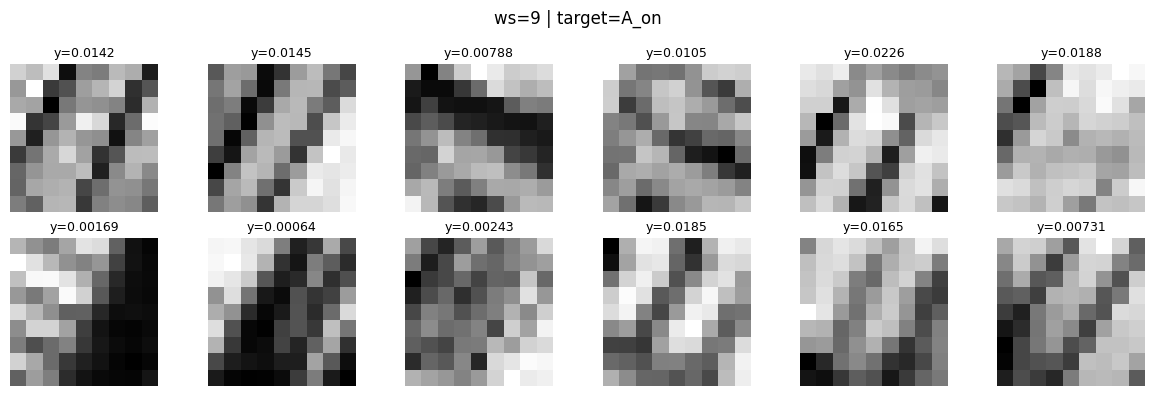

Epoch 000 | tr 0.6678 va 0.6664 | pred va 0.6644 | tau 0.6925
Epoch 025 | tr 0.3366 va 0.4070 | pred va 0.4050 | tau 0.7078
Epoch 050 | tr 0.2985 va 0.3987 | pred va 0.3966 | tau 0.7046
Epoch 075 | tr 0.2526 va 0.4025 | pred va 0.4005 | tau 0.6943
Epoch 100 | tr 0.2310 va 0.4059 | pred va 0.4038 | tau 0.6867
Epoch 125 | tr 0.2001 va 0.4034 | pred va 0.4013 | tau 0.6753
Epoch 150 | tr 0.1815 va 0.4156 | pred va 0.4135 | tau 0.6641
Epoch 175 | tr 0.1539 va 0.4113 | pred va 0.4092 | tau 0.6499
Epoch 200 | tr 0.1406 va 0.4123 | pred va 0.4101 | tau 0.6415
Epoch 225 | tr 0.1210 va 0.4036 | pred va 0.4014 | tau 0.6372
Epoch 250 | tr 0.1036 va 0.3974 | pred va 0.3952 | tau 0.6362
Epoch 275 | tr 0.0921 va 0.4067 | pred va 0.4045 | tau 0.6370
Epoch 300 | tr 0.0808 va 0.4183 | pred va 0.4161 | tau 0.6411
Epoch 325 | tr 0.0733 va 0.4227 | pred va 0.4205 | tau 0.6457
Epoch 350 | tr 0.0657 va 0.4288 | pred va 0.4266 | tau 0.6479
Epoch 375 | tr 0.0597 va 0.4284 | pred va 0.4263 | tau 0.6476
Epoch 40

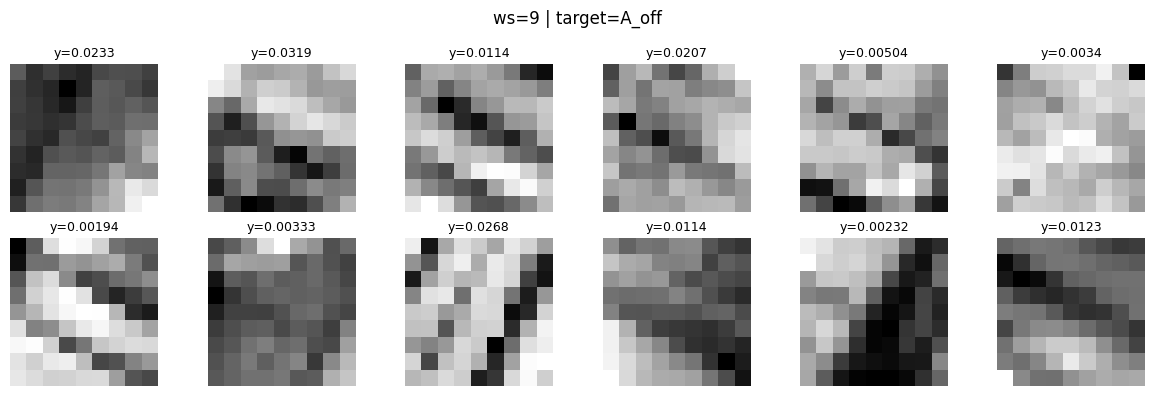

Epoch 000 | tr 0.6484 va 0.6432 | pred va 0.6415 | tau 0.6947
Epoch 025 | tr 0.3517 va 0.3908 | pred va 0.3888 | tau 0.7118
Epoch 050 | tr 0.3047 va 0.3781 | pred va 0.3761 | tau 0.7163
Epoch 075 | tr 0.2631 va 0.3622 | pred va 0.3601 | tau 0.7162
Epoch 100 | tr 0.2332 va 0.3478 | pred va 0.3458 | tau 0.7228
Epoch 125 | tr 0.1910 va 0.3571 | pred va 0.3550 | tau 0.7299
Epoch 150 | tr 0.1701 va 0.3574 | pred va 0.3554 | tau 0.7370
Epoch 175 | tr 0.1449 va 0.3665 | pred va 0.3645 | tau 0.7388
Epoch 200 | tr 0.1283 va 0.3699 | pred va 0.3679 | tau 0.7461
Epoch 225 | tr 0.1054 va 0.3807 | pred va 0.3787 | tau 0.7464
Epoch 250 | tr 0.0855 va 0.3753 | pred va 0.3733 | tau 0.7501
Epoch 275 | tr 0.0758 va 0.3919 | pred va 0.3899 | tau 0.7540
Epoch 300 | tr 0.0668 va 0.3922 | pred va 0.3902 | tau 0.7601
Epoch 325 | tr 0.0569 va 0.4047 | pred va 0.4027 | tau 0.7649
Epoch 350 | tr 0.0485 va 0.4210 | pred va 0.4191 | tau 0.7662
Epoch 375 | tr 0.0426 va 0.4169 | pred va 0.4149 | tau 0.7658
Epoch 40

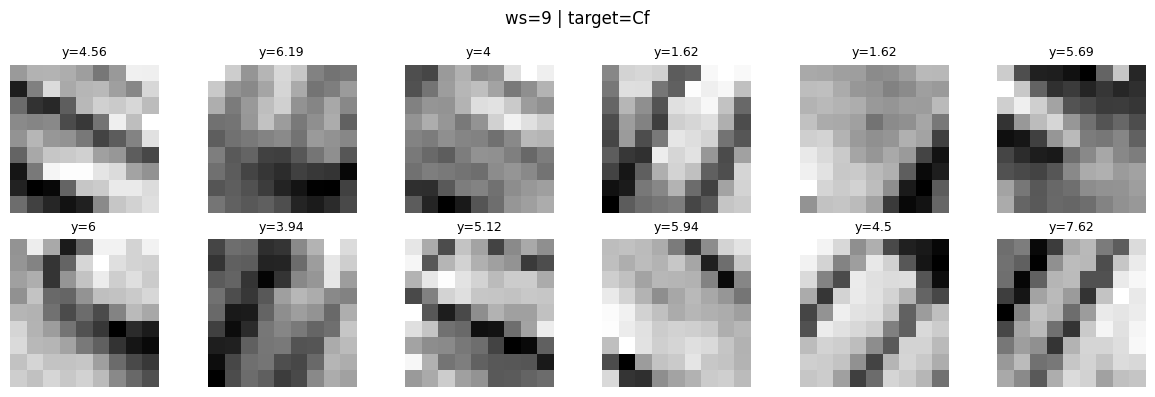

Epoch 000 | tr 0.5775 va 0.5400 | pred va 0.5385 | tau 0.6950
Epoch 025 | tr 0.5153 va 0.4949 | pred va 0.4933 | tau 0.7343
Epoch 050 | tr 0.4774 va 0.4948 | pred va 0.4930 | tau 0.7545
Epoch 075 | tr 0.4498 va 0.5090 | pred va 0.5071 | tau 0.7564
Epoch 100 | tr 0.4267 va 0.5335 | pred va 0.5316 | tau 0.7669
Epoch 125 | tr 0.3928 va 0.5342 | pred va 0.5322 | tau 0.7723
Epoch 150 | tr 0.3524 va 0.5491 | pred va 0.5471 | tau 0.7748
Epoch 175 | tr 0.3268 va 0.5457 | pred va 0.5437 | tau 0.7710
Epoch 200 | tr 0.3025 va 0.5621 | pred va 0.5600 | tau 0.7659
Epoch 225 | tr 0.2716 va 0.5795 | pred va 0.5775 | tau 0.7629
Epoch 250 | tr 0.2494 va 0.5722 | pred va 0.5702 | tau 0.7618
Epoch 275 | tr 0.2345 va 0.6044 | pred va 0.6023 | tau 0.7623
Epoch 300 | tr 0.2175 va 0.6006 | pred va 0.5985 | tau 0.7636
Epoch 325 | tr 0.1980 va 0.6237 | pred va 0.6217 | tau 0.7641
Epoch 350 | tr 0.1844 va 0.6400 | pred va 0.6380 | tau 0.7627
Epoch 375 | tr 0.1729 va 0.6436 | pred va 0.6416 | tau 0.7594
Epoch 40

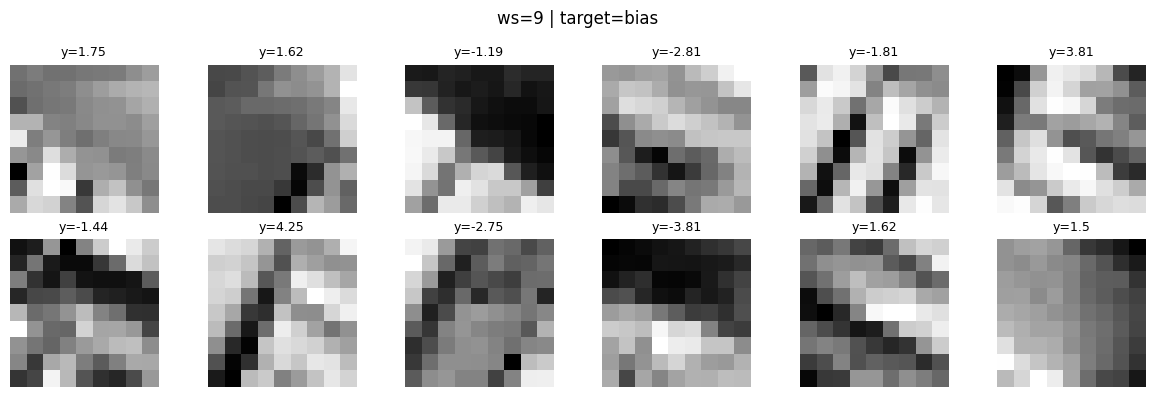

Epoch 000 | tr 0.6573 va 0.6353 | pred va 0.6346 | tau 0.6948
Epoch 025 | tr 0.3505 va 0.3877 | pred va 0.3859 | tau 0.7078
Epoch 050 | tr 0.3077 va 0.3842 | pred va 0.3824 | tau 0.7194
Epoch 075 | tr 0.2669 va 0.3825 | pred va 0.3806 | tau 0.7198
Epoch 100 | tr 0.2442 va 0.3945 | pred va 0.3927 | tau 0.7224
Epoch 125 | tr 0.2148 va 0.4146 | pred va 0.4127 | tau 0.7193
Epoch 150 | tr 0.1980 va 0.4304 | pred va 0.4285 | tau 0.7199
Epoch 175 | tr 0.1736 va 0.4375 | pred va 0.4356 | tau 0.7184
Epoch 200 | tr 0.1606 va 0.4297 | pred va 0.4278 | tau 0.7183
Epoch 225 | tr 0.1428 va 0.4299 | pred va 0.4280 | tau 0.7236
Epoch 250 | tr 0.1213 va 0.4369 | pred va 0.4350 | tau 0.7311
Epoch 275 | tr 0.1060 va 0.4388 | pred va 0.4370 | tau 0.7399
Epoch 300 | tr 0.0941 va 0.4242 | pred va 0.4224 | tau 0.7466
Epoch 325 | tr 0.0842 va 0.4351 | pred va 0.4332 | tau 0.7531
Epoch 350 | tr 0.0759 va 0.4400 | pred va 0.4381 | tau 0.7575
Epoch 375 | tr 0.0711 va 0.4498 | pred va 0.4479 | tau 0.7592
Epoch 40

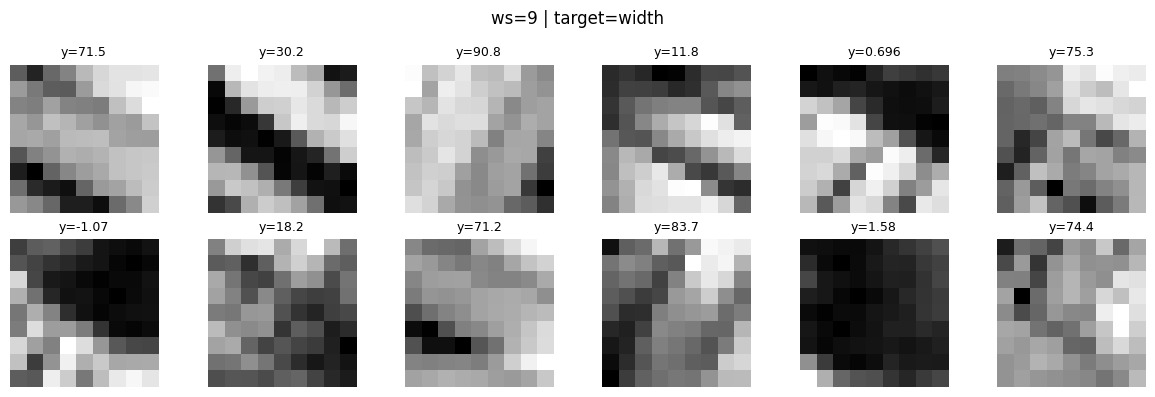

Epoch 000 | tr 0.6774 va 0.6766 | pred va 0.6753 | tau 0.6938
Epoch 025 | tr 0.3935 va 0.4159 | pred va 0.4141 | tau 0.7197
Epoch 050 | tr 0.3231 va 0.4072 | pred va 0.4052 | tau 0.7225
Epoch 075 | tr 0.2560 va 0.4096 | pred va 0.4076 | tau 0.7215
Epoch 100 | tr 0.2090 va 0.4067 | pred va 0.4047 | tau 0.7227
Epoch 125 | tr 0.1608 va 0.4130 | pred va 0.4109 | tau 0.7182
Epoch 150 | tr 0.1320 va 0.4173 | pred va 0.4153 | tau 0.7134
Epoch 175 | tr 0.1191 va 0.4325 | pred va 0.4304 | tau 0.7149
Epoch 200 | tr 0.0907 va 0.4170 | pred va 0.4150 | tau 0.7169
Epoch 225 | tr 0.0794 va 0.4145 | pred va 0.4125 | tau 0.7231
Epoch 250 | tr 0.0655 va 0.4266 | pred va 0.4245 | tau 0.7307
Epoch 275 | tr 0.0596 va 0.4209 | pred va 0.4189 | tau 0.7364
Epoch 300 | tr 0.0495 va 0.4218 | pred va 0.4198 | tau 0.7418
Epoch 325 | tr 0.0410 va 0.4366 | pred va 0.4346 | tau 0.7495
Epoch 350 | tr 0.0365 va 0.4332 | pred va 0.4311 | tau 0.7545
Epoch 375 | tr 0.0322 va 0.4469 | pred va 0.4449 | tau 0.7572
Epoch 40

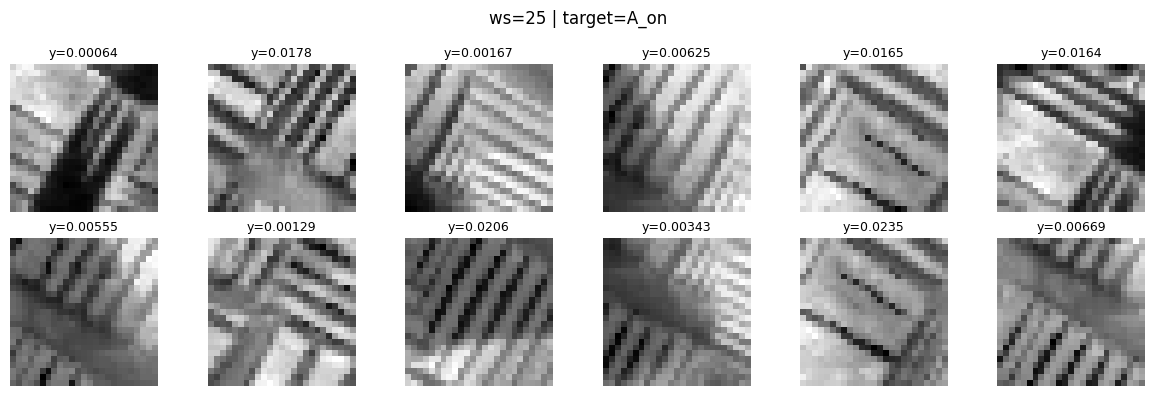

Epoch 000 | tr 0.7023 va 0.6611 | pred va 0.6609 | tau 0.6948
Epoch 025 | tr 0.5010 va 0.5185 | pred va 0.5182 | tau 0.7082
Epoch 050 | tr 0.2176 va 0.4900 | pred va 0.4897 | tau 0.7100
Epoch 075 | tr 0.1375 va 0.5057 | pred va 0.5054 | tau 0.7165
Epoch 100 | tr 0.1053 va 0.4822 | pred va 0.4819 | tau 0.7211
Epoch 125 | tr 0.0559 va 0.4852 | pred va 0.4848 | tau 0.7229
Epoch 150 | tr 0.0434 va 0.4733 | pred va 0.4730 | tau 0.7239
Epoch 175 | tr 0.0282 va 0.4715 | pred va 0.4712 | tau 0.7237
Epoch 200 | tr 0.0169 va 0.5179 | pred va 0.5176 | tau 0.7256
Epoch 225 | tr 0.0125 va 0.5019 | pred va 0.5015 | tau 0.7286
Epoch 250 | tr 0.0094 va 0.5073 | pred va 0.5070 | tau 0.7313
Epoch 275 | tr 0.0068 va 0.5164 | pred va 0.5161 | tau 0.7342
Epoch 300 | tr 0.0045 va 0.5180 | pred va 0.5177 | tau 0.7377
Epoch 325 | tr 0.0034 va 0.5136 | pred va 0.5132 | tau 0.7403
Epoch 350 | tr 0.0022 va 0.5244 | pred va 0.5241 | tau 0.7419
Epoch 375 | tr 0.0018 va 0.5272 | pred va 0.5268 | tau 0.7433
Epoch 40

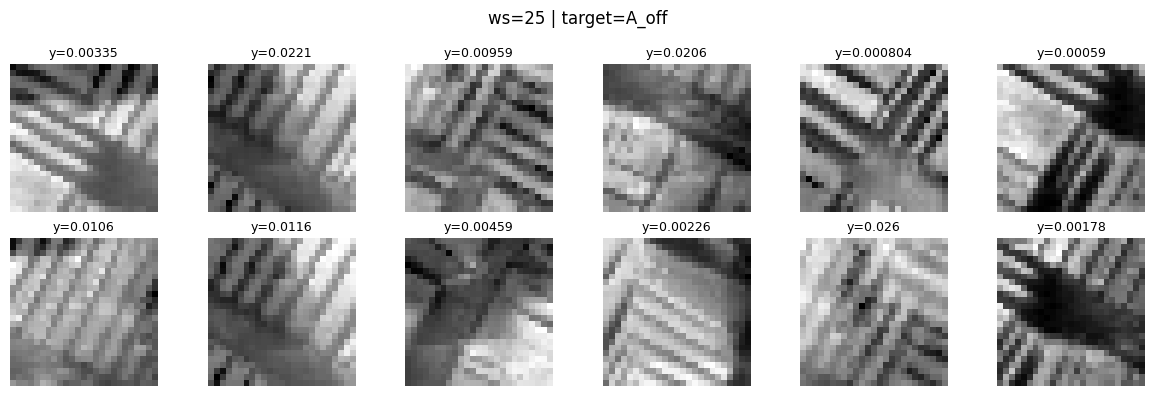

Epoch 000 | tr 0.6623 va 0.5967 | pred va 0.5964 | tau 0.6929
Epoch 025 | tr 0.4018 va 0.4316 | pred va 0.4312 | tau 0.6890
Epoch 050 | tr 0.2952 va 0.3936 | pred va 0.3932 | tau 0.6882
Epoch 075 | tr 0.2455 va 0.3727 | pred va 0.3723 | tau 0.6895
Epoch 100 | tr 0.1697 va 0.3757 | pred va 0.3753 | tau 0.6884
Epoch 125 | tr 0.1281 va 0.3368 | pred va 0.3364 | tau 0.6861
Epoch 150 | tr 0.0788 va 0.3209 | pred va 0.3205 | tau 0.6912
Epoch 175 | tr 0.0689 va 0.3387 | pred va 0.3384 | tau 0.7010
Epoch 200 | tr 0.0467 va 0.3382 | pred va 0.3379 | tau 0.7082
Epoch 225 | tr 0.0358 va 0.3373 | pred va 0.3370 | tau 0.7186
Epoch 250 | tr 0.0291 va 0.3492 | pred va 0.3489 | tau 0.7246
Epoch 275 | tr 0.0217 va 0.3308 | pred va 0.3304 | tau 0.7306
Epoch 300 | tr 0.0194 va 0.3385 | pred va 0.3382 | tau 0.7365
Epoch 325 | tr 0.0140 va 0.3473 | pred va 0.3470 | tau 0.7411
Epoch 350 | tr 0.0119 va 0.3475 | pred va 0.3471 | tau 0.7446
Epoch 375 | tr 0.0094 va 0.3530 | pred va 0.3527 | tau 0.7466
Epoch 40

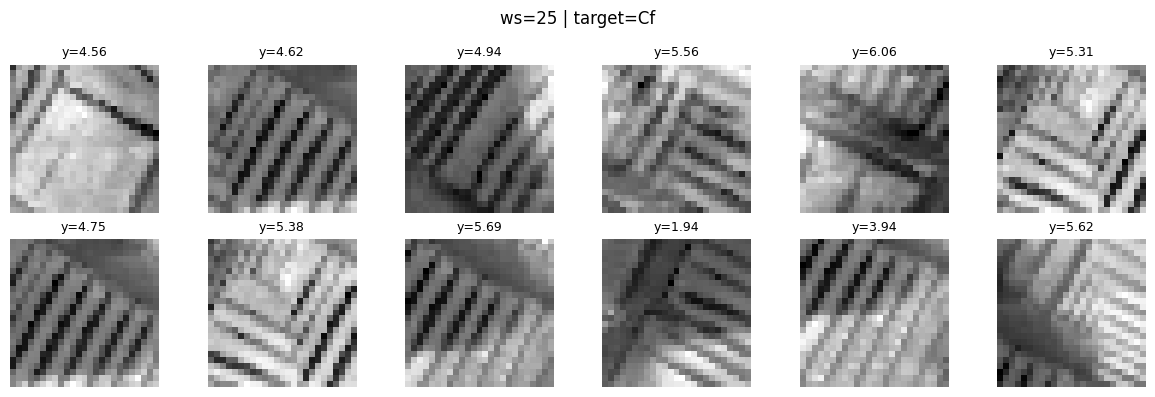

Epoch 000 | tr 0.5468 va 0.5791 | pred va 0.5788 | tau 0.6937
Epoch 025 | tr 0.4677 va 0.5905 | pred va 0.5901 | tau 0.6855
Epoch 050 | tr 0.3640 va 0.7005 | pred va 0.7001 | tau 0.6827
Epoch 075 | tr 0.2592 va 0.7561 | pred va 0.7557 | tau 0.6787
Epoch 100 | tr 0.1509 va 0.7624 | pred va 0.7620 | tau 0.6731
Epoch 125 | tr 0.1050 va 0.7979 | pred va 0.7975 | tau 0.6735
Epoch 150 | tr 0.0841 va 0.7873 | pred va 0.7869 | tau 0.6757
Epoch 175 | tr 0.0470 va 0.8228 | pred va 0.8224 | tau 0.6768
Epoch 200 | tr 0.0337 va 0.8245 | pred va 0.8241 | tau 0.6836
Epoch 225 | tr 0.0250 va 0.8081 | pred va 0.8077 | tau 0.6953
Epoch 250 | tr 0.0164 va 0.8192 | pred va 0.8188 | tau 0.7094
Epoch 275 | tr 0.0106 va 0.8151 | pred va 0.8148 | tau 0.7212
Epoch 300 | tr 0.0103 va 0.8168 | pred va 0.8165 | tau 0.7326
Epoch 325 | tr 0.0058 va 0.8107 | pred va 0.8104 | tau 0.7421
Epoch 350 | tr 0.0041 va 0.8058 | pred va 0.8054 | tau 0.7496
Epoch 375 | tr 0.0028 va 0.8050 | pred va 0.8046 | tau 0.7550
Epoch 40

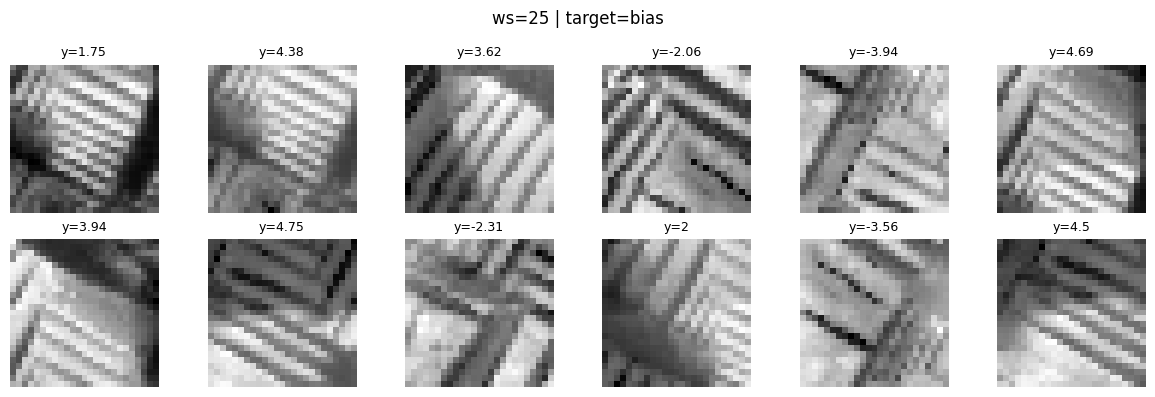

Epoch 000 | tr 0.6715 va 0.6937 | pred va 0.6935 | tau 0.6928
Epoch 025 | tr 0.3053 va 0.3696 | pred va 0.3693 | tau 0.7001
Epoch 050 | tr 0.1758 va 0.4245 | pred va 0.4242 | tau 0.7042
Epoch 075 | tr 0.1363 va 0.4602 | pred va 0.4599 | tau 0.7011
Epoch 100 | tr 0.1052 va 0.4406 | pred va 0.4402 | tau 0.6931
Epoch 125 | tr 0.0814 va 0.4577 | pred va 0.4573 | tau 0.6872
Epoch 150 | tr 0.0679 va 0.4644 | pred va 0.4640 | tau 0.6848
Epoch 175 | tr 0.0537 va 0.4514 | pred va 0.4510 | tau 0.6887
Epoch 200 | tr 0.0376 va 0.4734 | pred va 0.4731 | tau 0.6900
Epoch 225 | tr 0.0276 va 0.4813 | pred va 0.4809 | tau 0.6891
Epoch 250 | tr 0.0204 va 0.4716 | pred va 0.4712 | tau 0.6869
Epoch 275 | tr 0.0124 va 0.4816 | pred va 0.4812 | tau 0.6849
Epoch 300 | tr 0.0083 va 0.4911 | pred va 0.4907 | tau 0.6839
Epoch 325 | tr 0.0069 va 0.4972 | pred va 0.4968 | tau 0.6843
Epoch 350 | tr 0.0038 va 0.4965 | pred va 0.4961 | tau 0.6856
Epoch 375 | tr 0.0030 va 0.5037 | pred va 0.5033 | tau 0.6869
Epoch 40

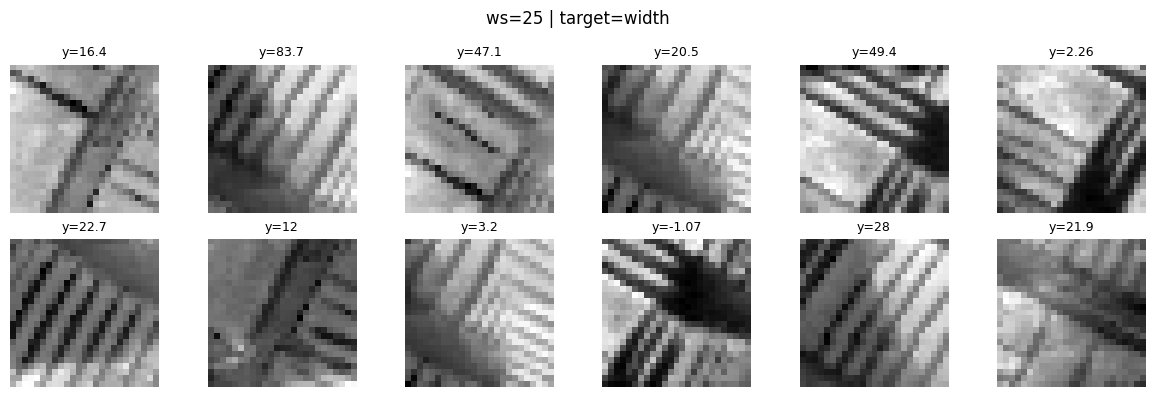

Epoch 000 | tr 0.6902 va 0.6325 | pred va 0.6322 | tau 0.6937
Epoch 025 | tr 0.3554 va 0.4882 | pred va 0.4878 | tau 0.6931
Epoch 050 | tr 0.1899 va 0.3705 | pred va 0.3701 | tau 0.6967
Epoch 075 | tr 0.1645 va 0.3630 | pred va 0.3627 | tau 0.6999
Epoch 100 | tr 0.1227 va 0.3678 | pred va 0.3674 | tau 0.7056
Epoch 125 | tr 0.0848 va 0.3715 | pred va 0.3711 | tau 0.7141
Epoch 150 | tr 0.0709 va 0.4039 | pred va 0.4036 | tau 0.7222
Epoch 175 | tr 0.0534 va 0.4239 | pred va 0.4235 | tau 0.7373
Epoch 200 | tr 0.0426 va 0.3968 | pred va 0.3964 | tau 0.7514
Epoch 225 | tr 0.0318 va 0.3981 | pred va 0.3978 | tau 0.7659
Epoch 250 | tr 0.0259 va 0.3816 | pred va 0.3813 | tau 0.7794
Epoch 275 | tr 0.0298 va 0.4068 | pred va 0.4065 | tau 0.7911
Epoch 300 | tr 0.0173 va 0.3812 | pred va 0.3809 | tau 0.7979
Epoch 325 | tr 0.0137 va 0.3974 | pred va 0.3971 | tau 0.8041
Epoch 350 | tr 0.0111 va 0.3871 | pred va 0.3868 | tau 0.8068
Epoch 375 | tr 0.0087 va 0.3953 | pred va 0.3950 | tau 0.8091
Epoch 40

In [13]:

import copy

ws_list = [9, 25]
STEP = 2
EPOCHS = 500
BATCH = 64

target_names = list(targets.keys())
print("Targets:", target_names)

full_res = {}
full_res_shap = {}

for ws in ws_list:
    full_res[ws] = {}
    full_res_shap[ws] = {}
    for tname in target_names:
        patches, y_phys, coords = extract_patches_and_targets(pola, targets[tname], ws=ws, step=STEP)
        show_patch_samples(patches, y_phys, n=12, title=f"ws={ws} | target={tname}")

        X_tok = patch_to_tokens(patches)
        y_mu, y_sig, to_train, to_phys = standardize_y(y_phys)
        y_train_units = to_train(y_phys).astype(np.float32)

        X_train, X_val, y_train, y_val, ytrain_phys, yval_phys, coords_tr, coords_va = train_test_split(
            X_tok, y_train_units, y_phys, coords, test_size=0.2, random_state=42
        )

        train_loader = DataLoader(TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        ), batch_size=BATCH, shuffle=True)

        val_loader = DataLoader(TensorDataset(
            torch.tensor(X_val, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
        ), batch_size=BATCH, shuffle=False)

        model = TransformerExplainableRegressor(ws*ws, in_feats=3, hidden_dim=64, heads=4, depth=2).to(DEVICE)
        hist = train_model(model, train_loader, val_loader, n_epochs=EPOCHS)

        y_pred_val_train = predict_np(model, X_val)
        y_pred_val_phys = to_phys(y_pred_val_train)
        rmse = float(np.sqrt(np.mean((yval_phys - y_pred_val_phys)**2)))
        mae  = float(np.mean(np.abs(yval_phys - y_pred_val_phys)))

        alphas = collect_attention(model, X_val)
        a_mean = alphas.mean(axis=0); a_mean /= (a_mean.max() + 1e-12)

        errs = np.abs(y_pred_val_phys - yval_phys)
        w = 1.0 / (errs + 1e-6); w /= (w.sum() + 1e-12)
        a_w = (alphas * w[:, None]).sum(axis=0); a_w /= (a_w.max() + 1e-12)

        n_bg = min(128, len(X_train))
        bg_idx = np.random.choice(len(X_train), size=n_bg, replace=False)
        X_bg = torch.tensor(X_train[bg_idx], dtype=torch.float32, device=DEVICE)

        n_ex = min(256, len(X_val))
        ex_idx = np.random.choice(len(X_val), size=n_ex, replace=False)
        X_ex = torch.tensor(X_val[ex_idx], dtype=torch.float32, device=DEVICE)

        shap_vals = compute_shap_values(model, X_bg, X_ex)
        shapI = shap_map_mean_abs(shap_vals, channel=0)

        full_res[ws][tname] = dict(
            model_state=copy.deepcopy(model.state_dict()),
            hist=hist, rmse=rmse, mae=mae,
            X_val=X_val, yval_phys=yval_phys, pred_val_phys=y_pred_val_phys,
            alpha_mean=a_mean, alpha_w=a_w
        )
        full_res_shap[ws][tname] = dict(shapI=shapI, shap_shape=shap_vals.shape)

        print(f"ws={ws} target={tname} RMSE={rmse:.4g} MAE={mae:.4g}")


## 8) Summary plots


=== ws=9 | target=A_on | RMSE=0.007187 ===


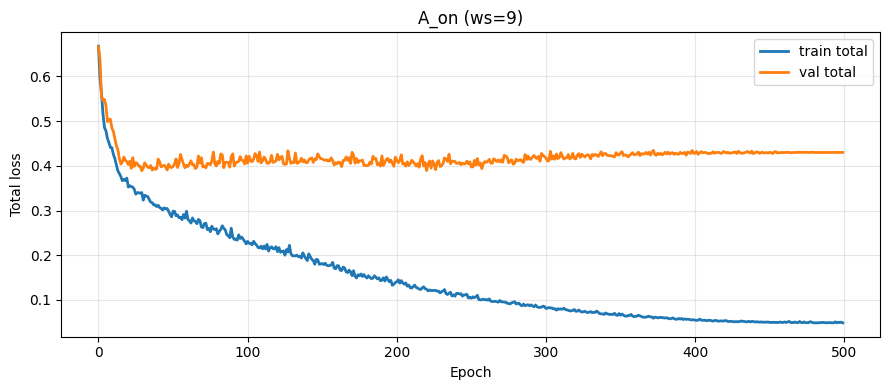

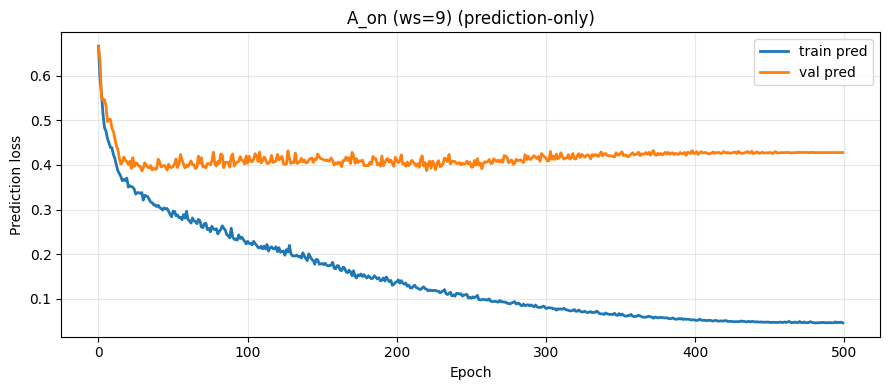

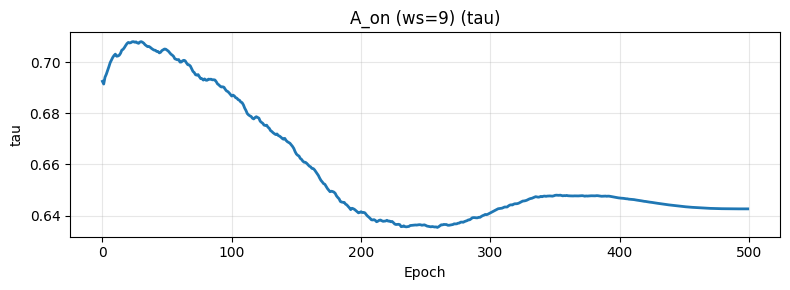

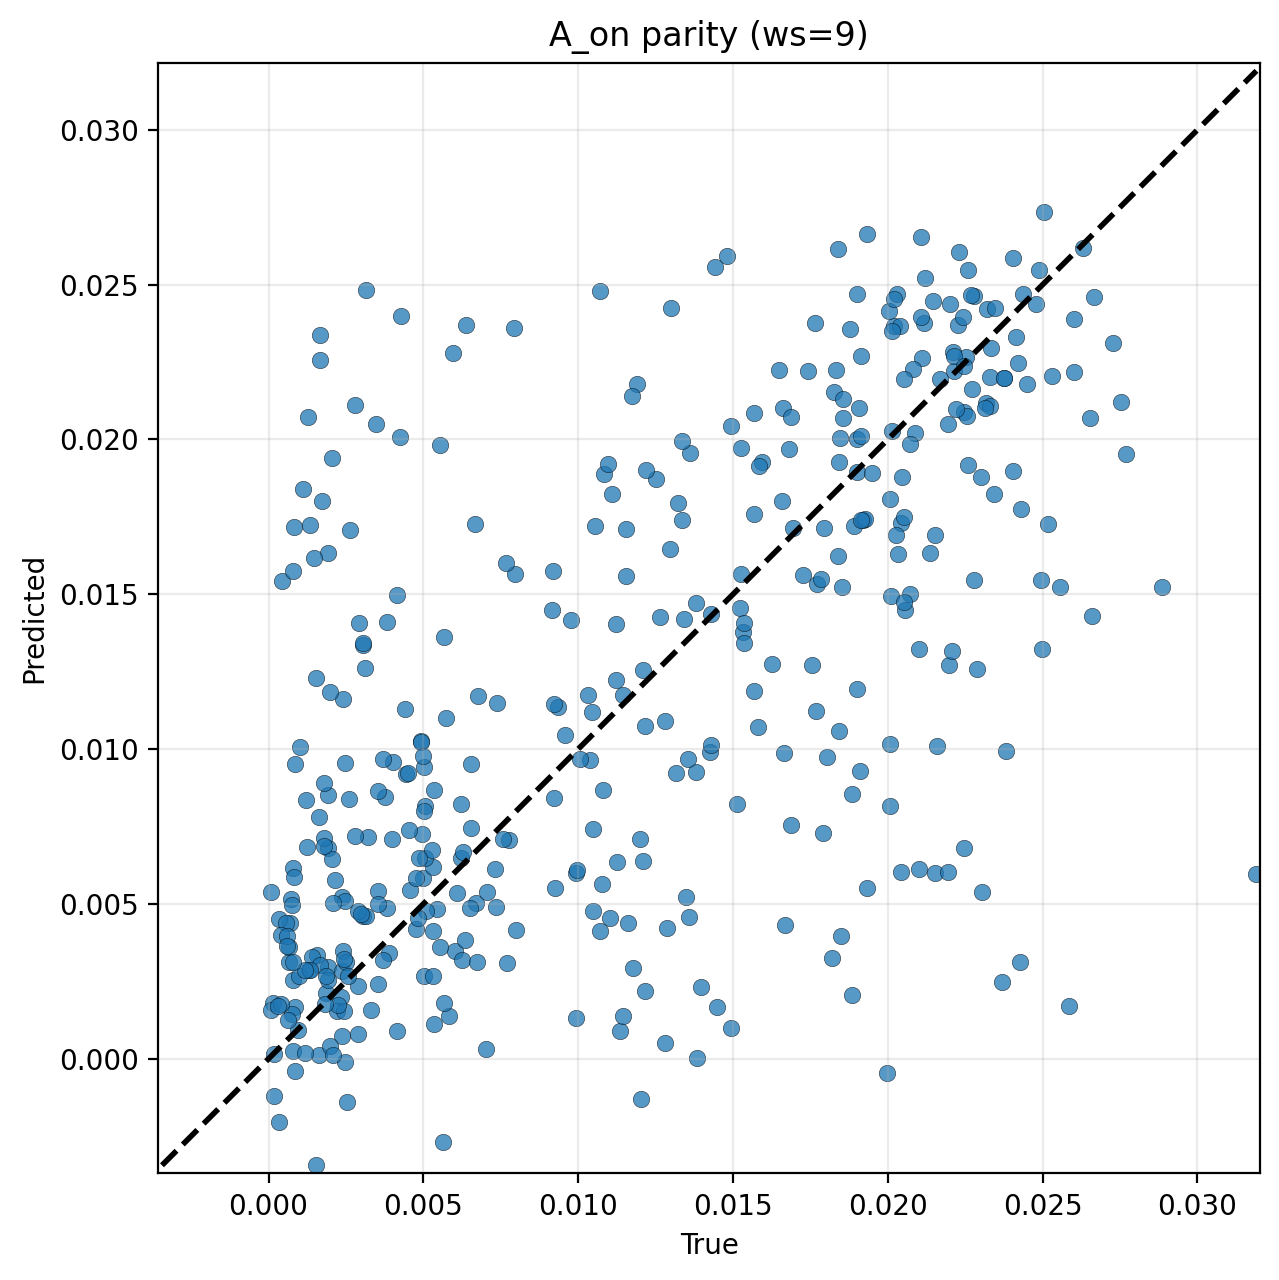

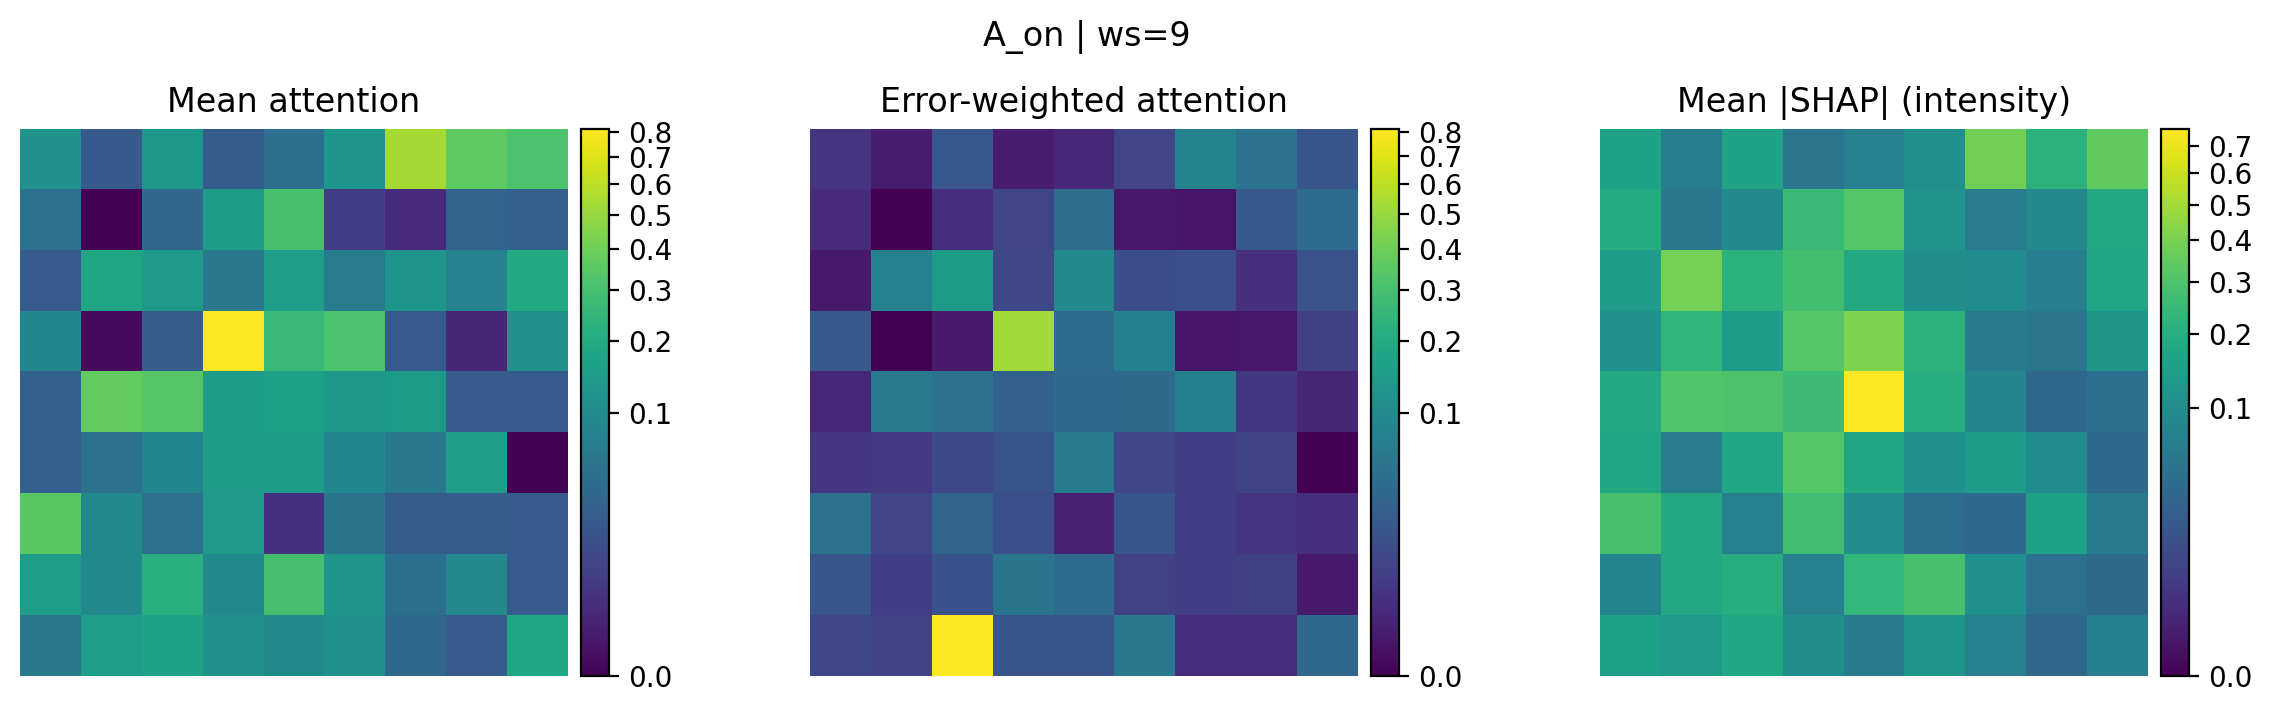


=== ws=9 | target=A_off | RMSE=0.009221 ===


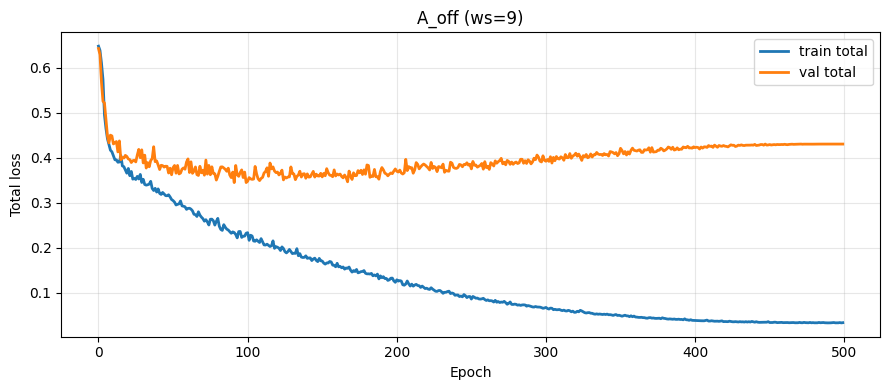

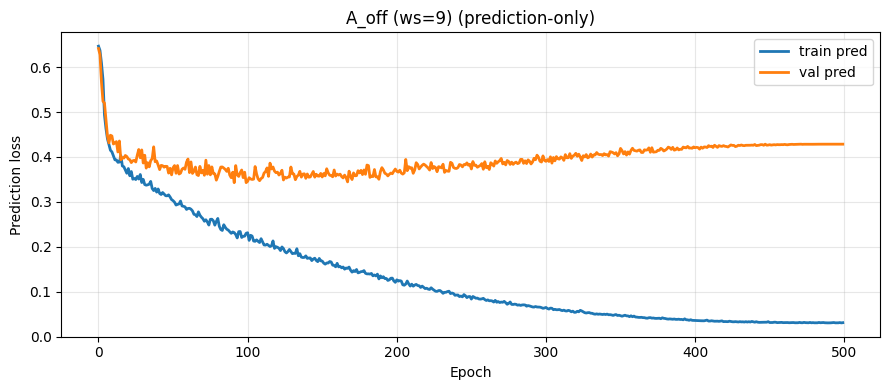

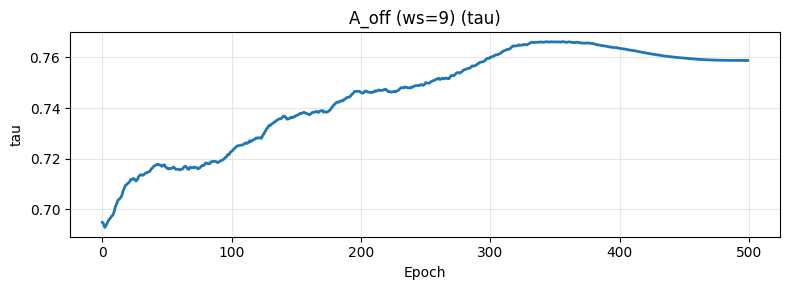

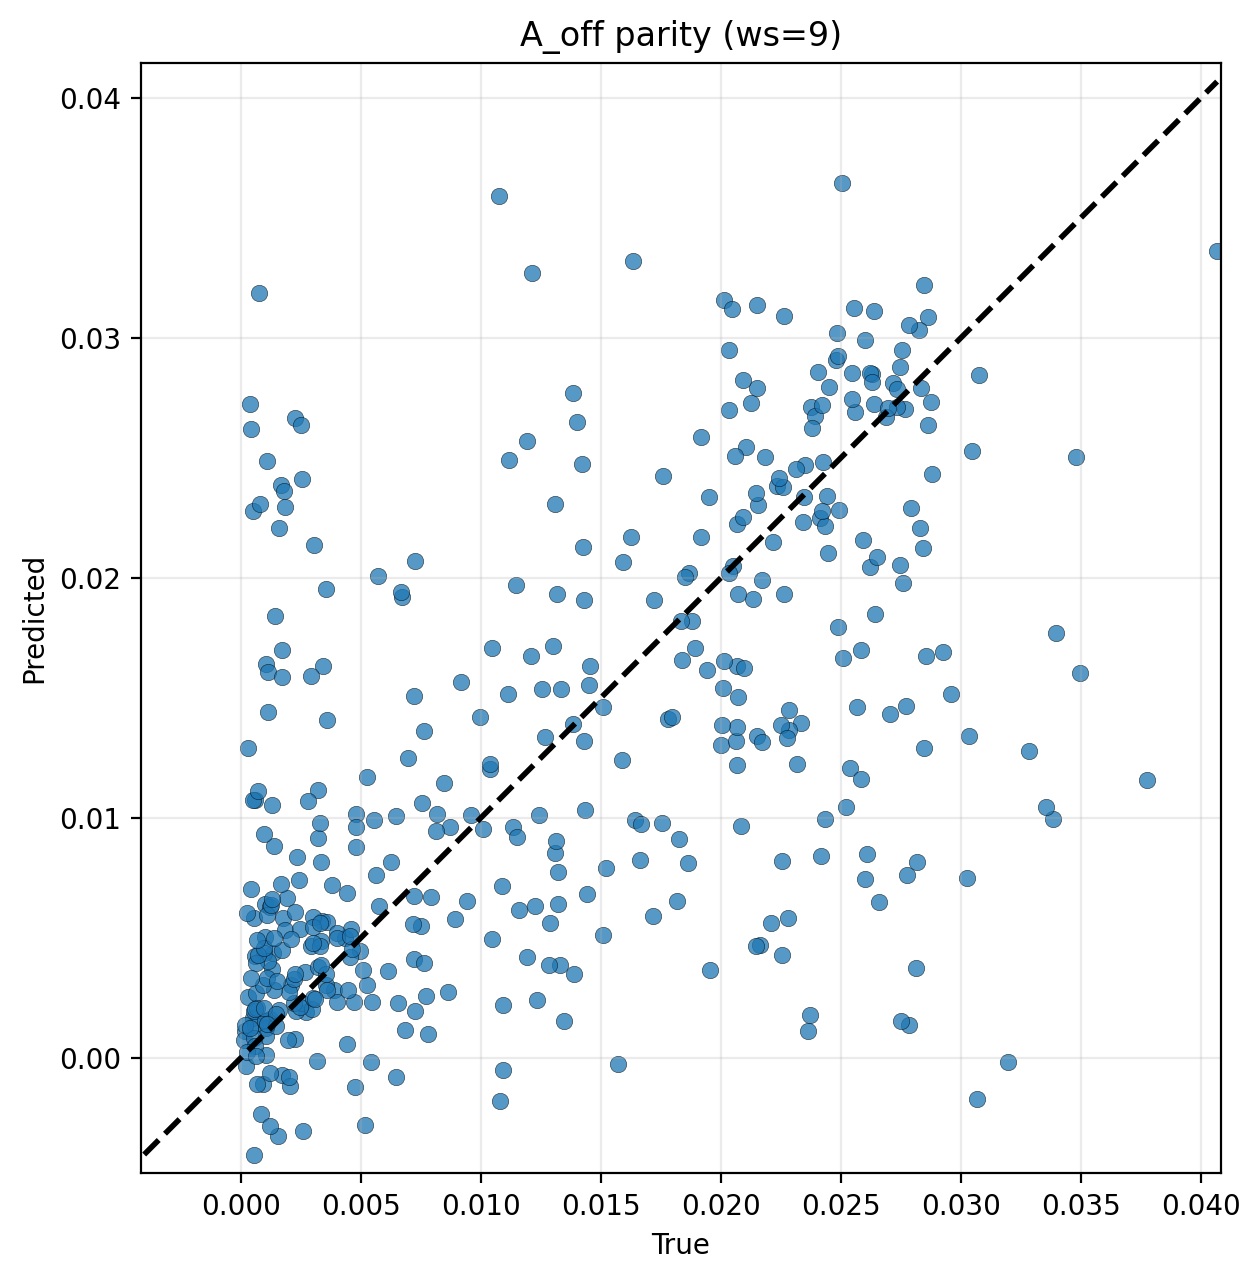

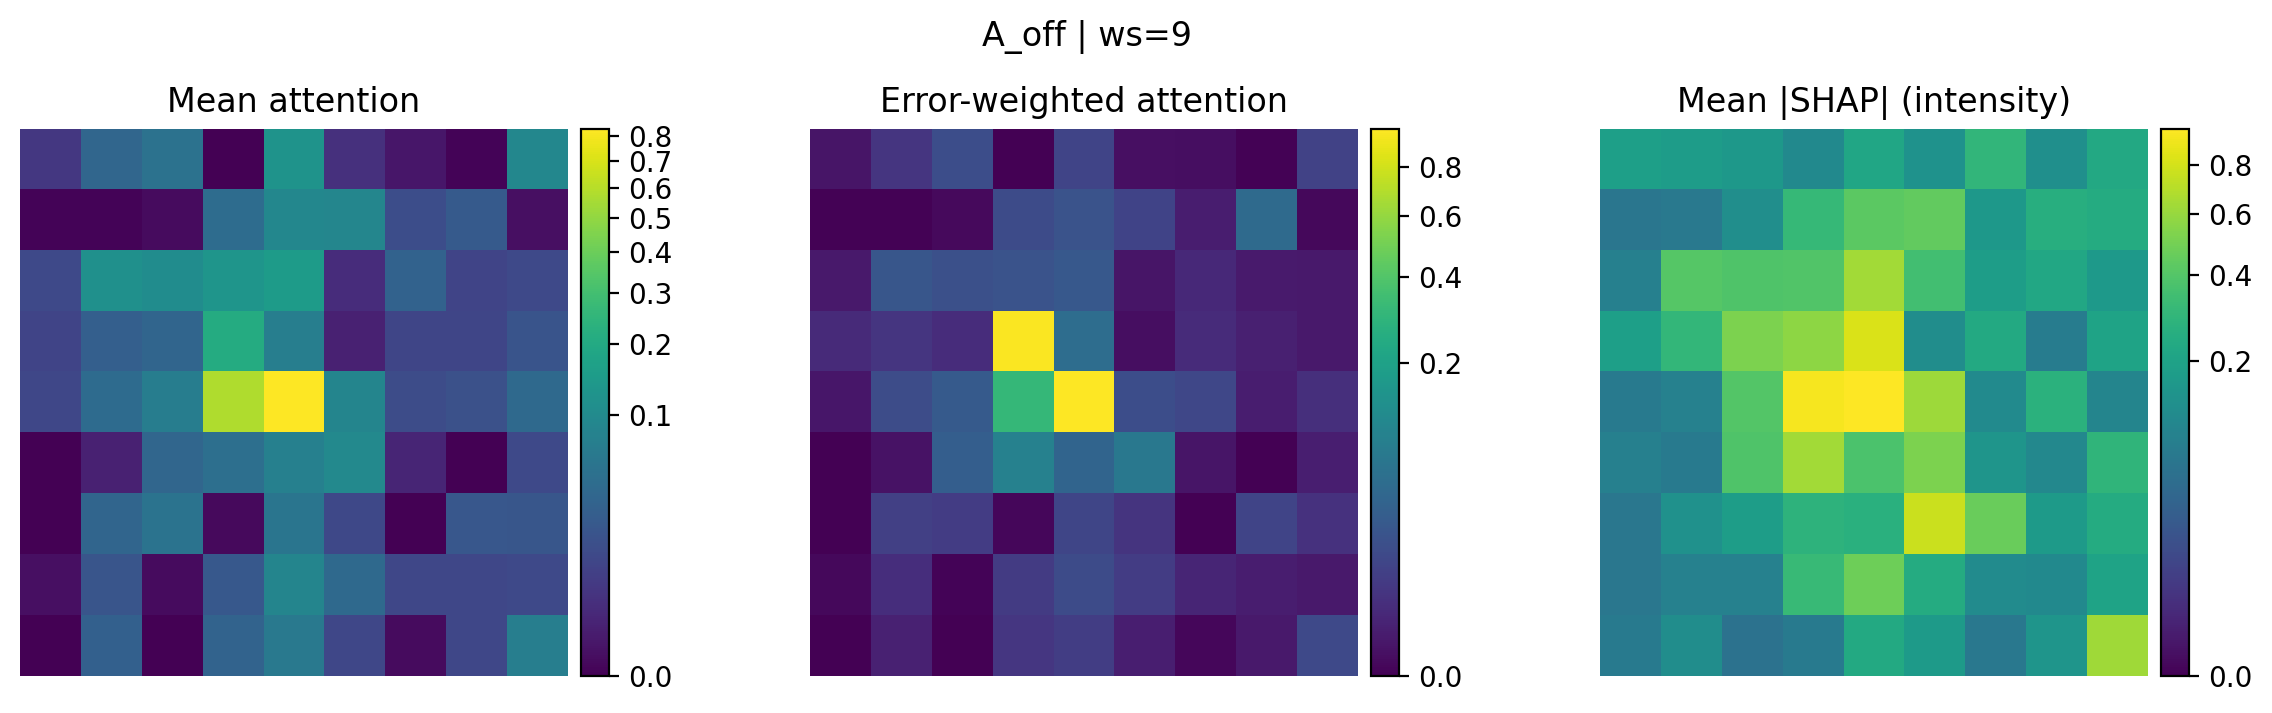


=== ws=9 | target=Cf | RMSE=1.971 ===


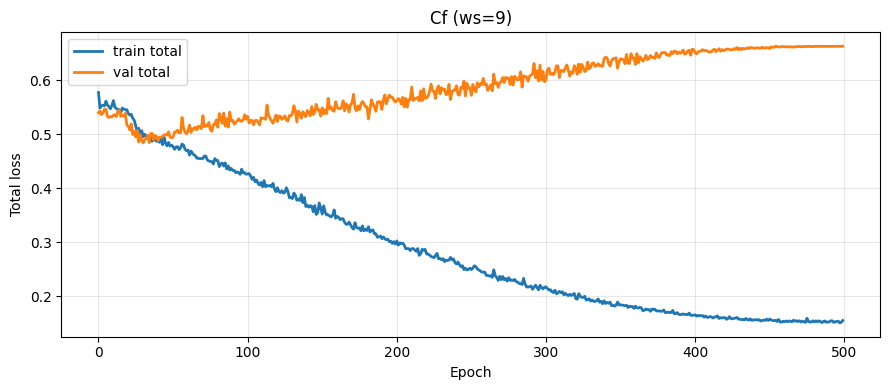

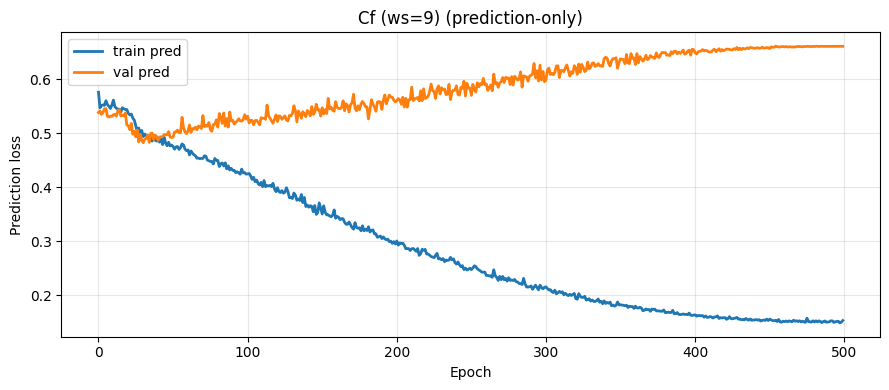

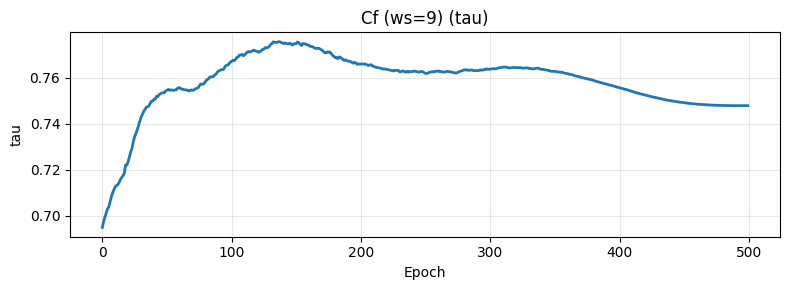

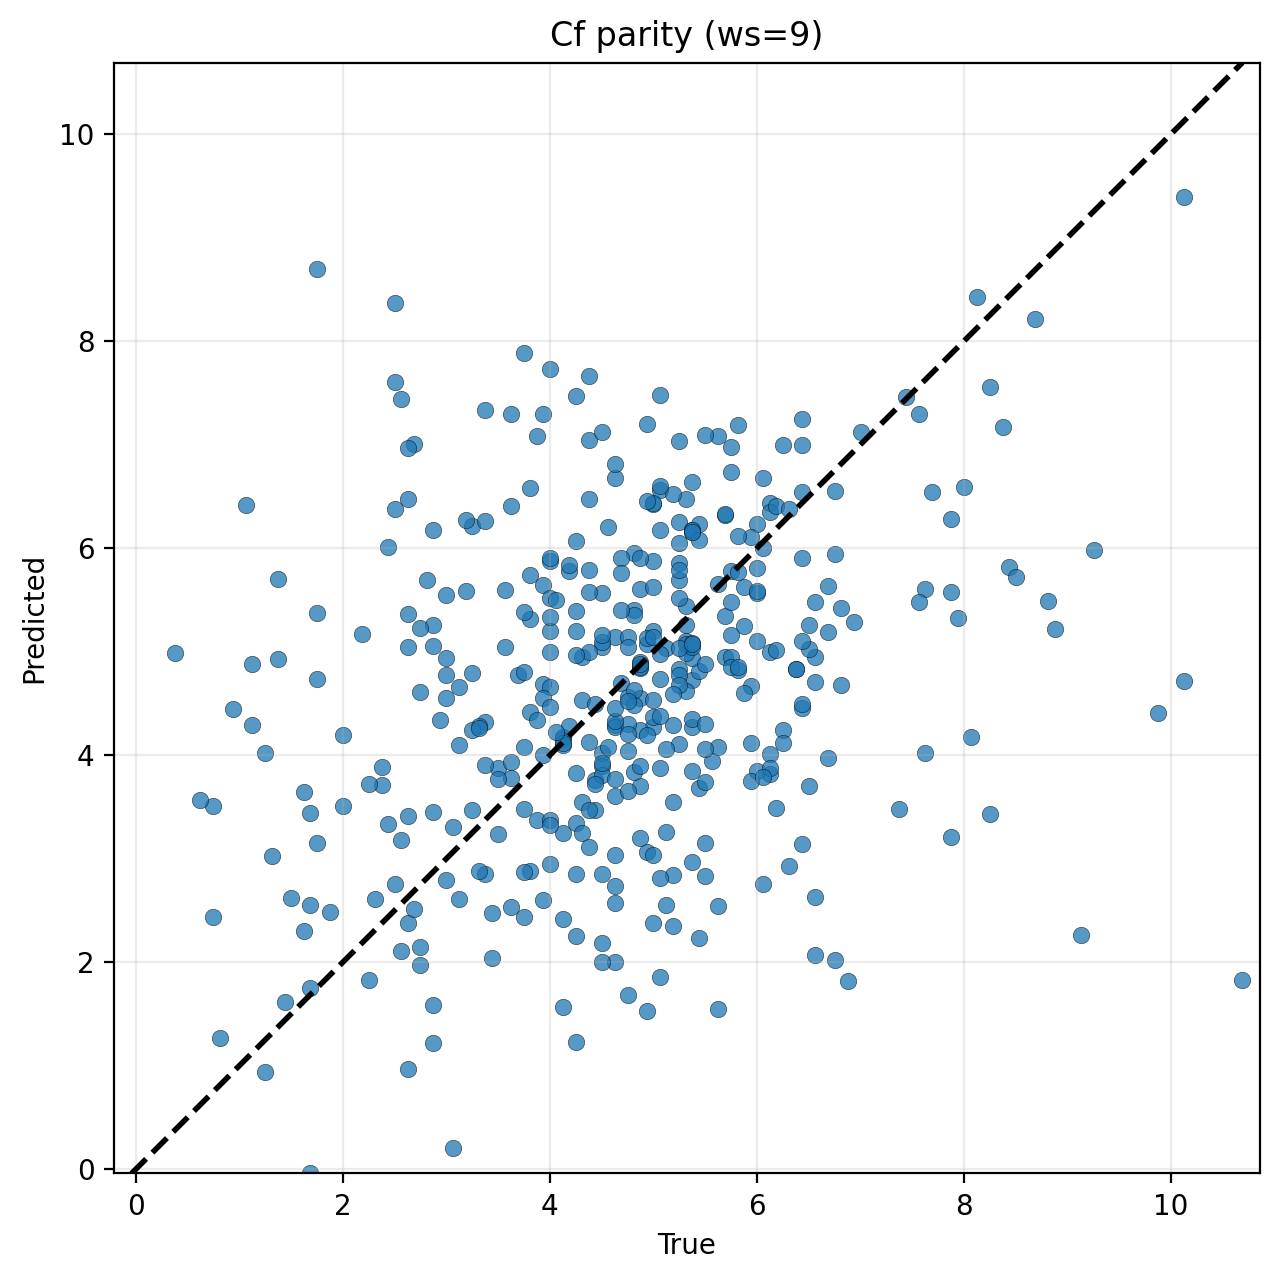

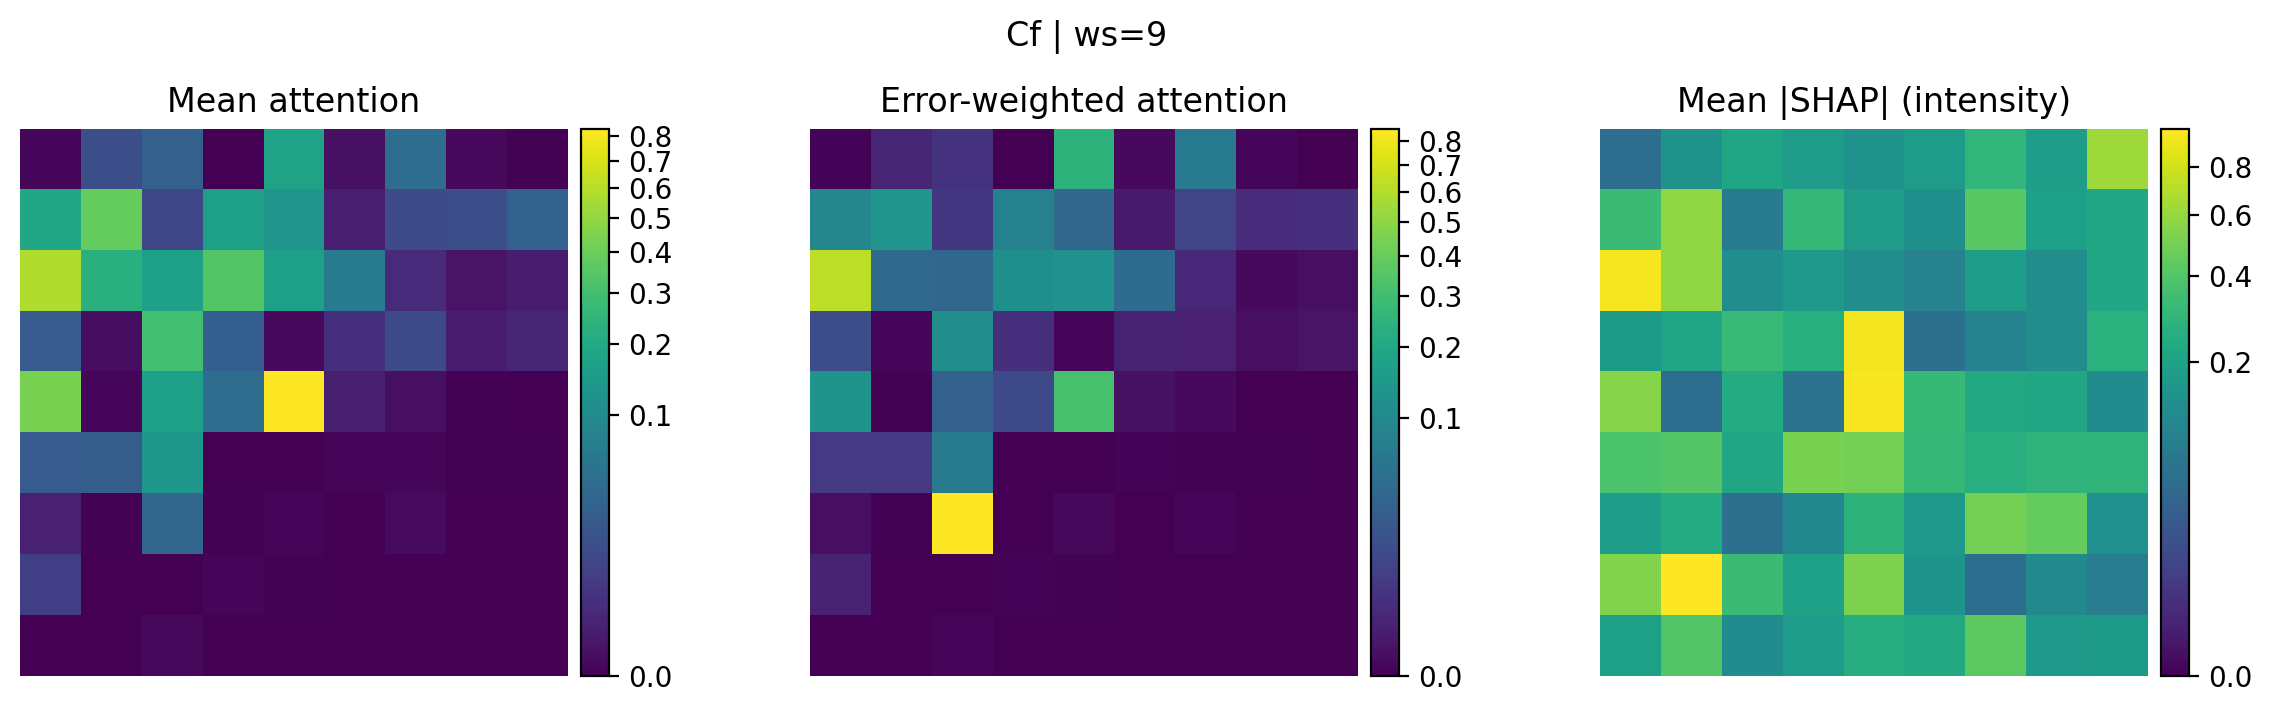


=== ws=9 | target=bias | RMSE=2.547 ===


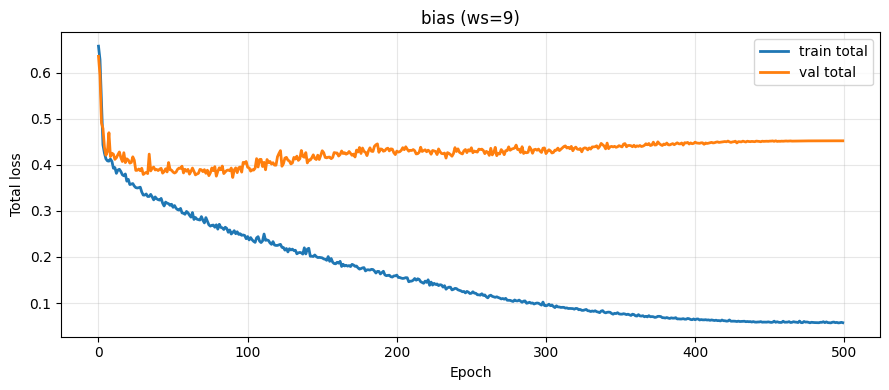

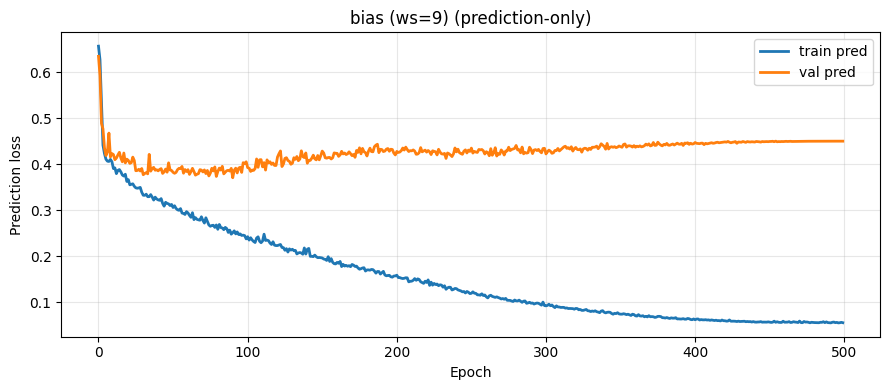

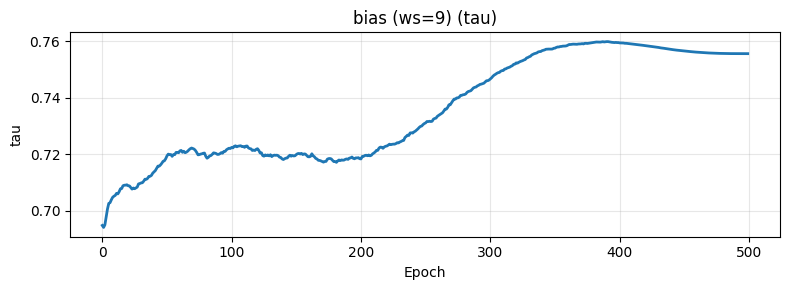

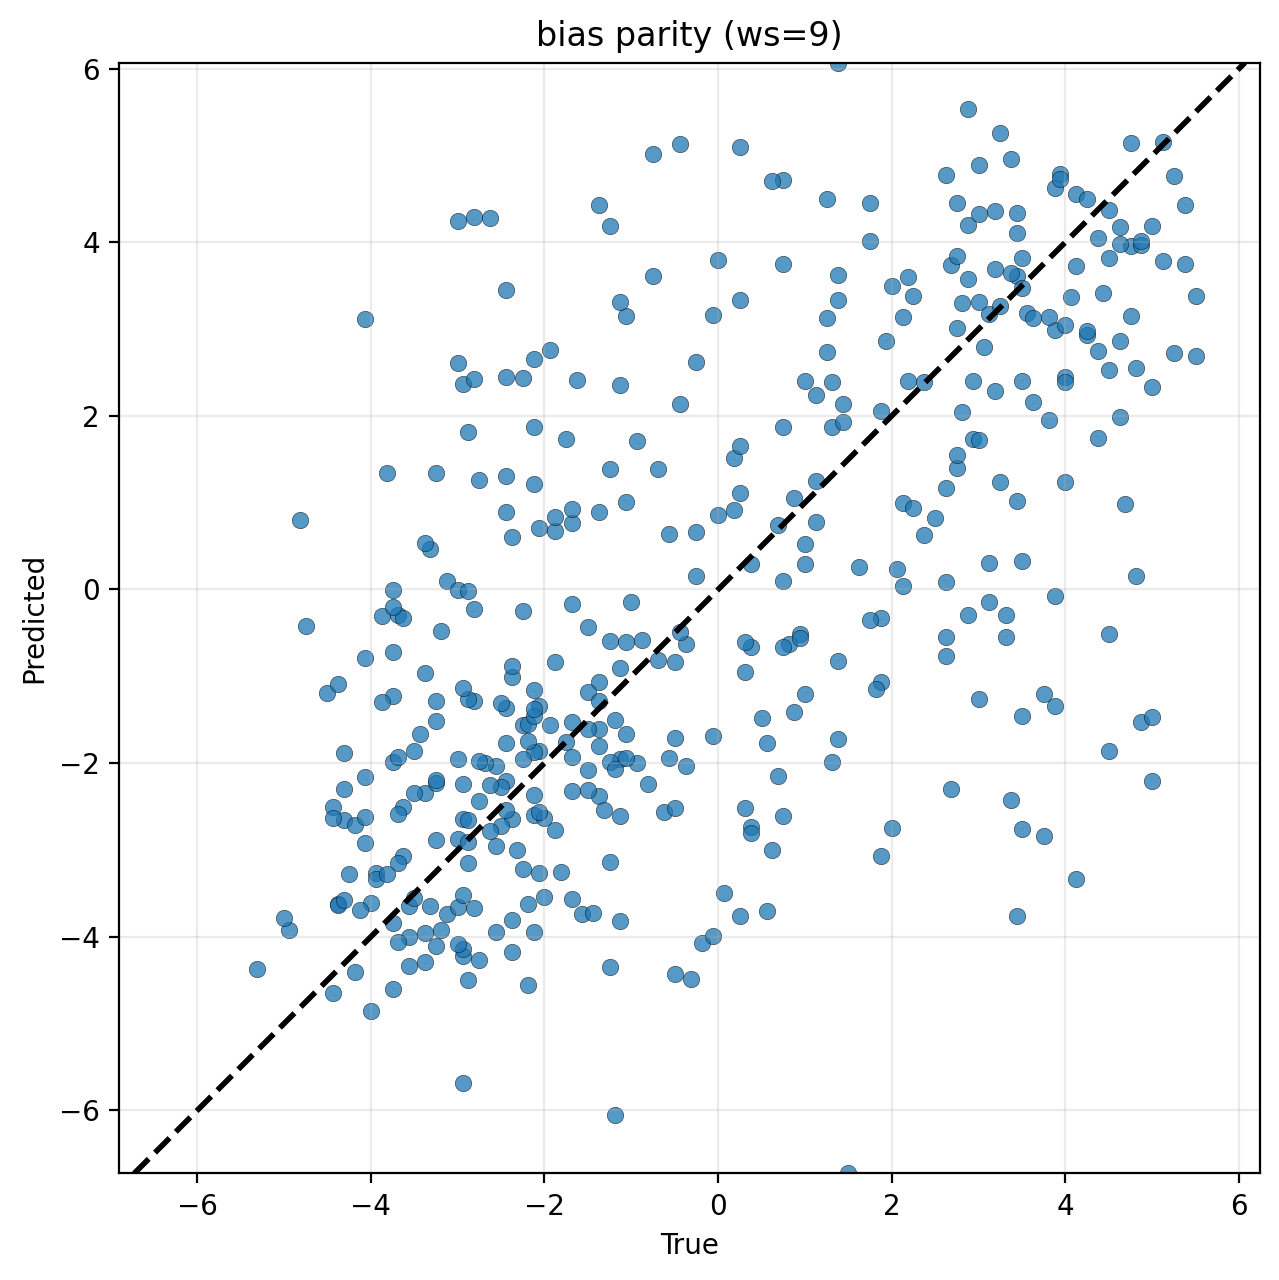

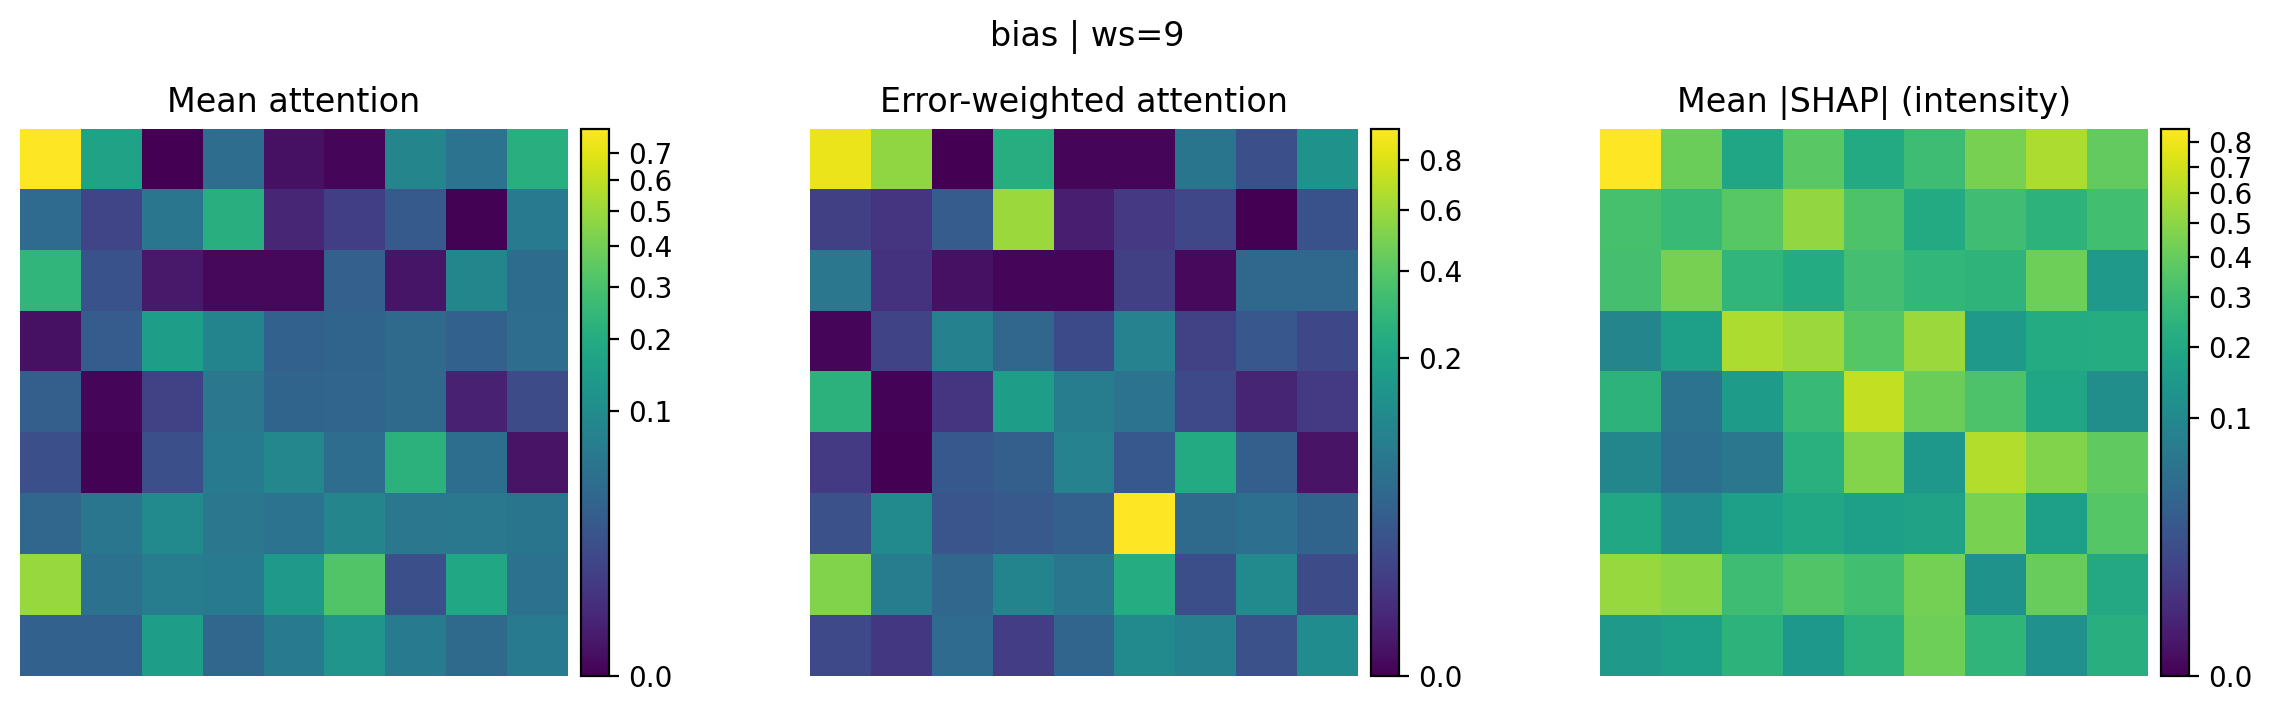


=== ws=9 | target=width | RMSE=28.59 ===


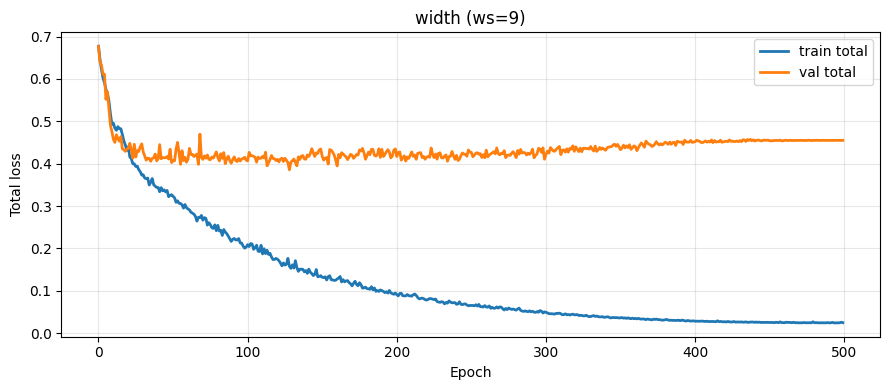

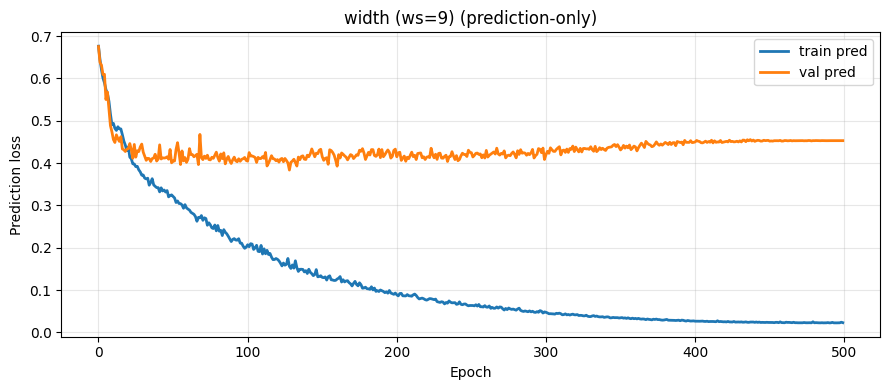

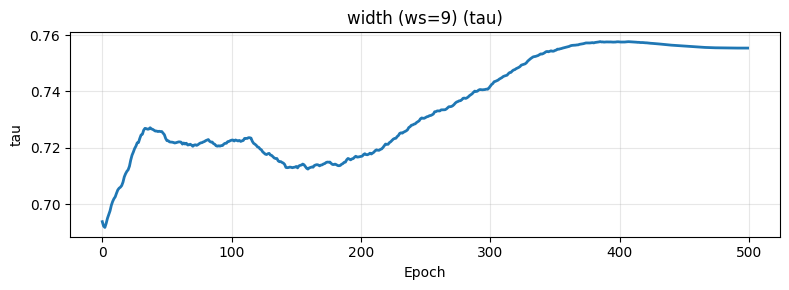

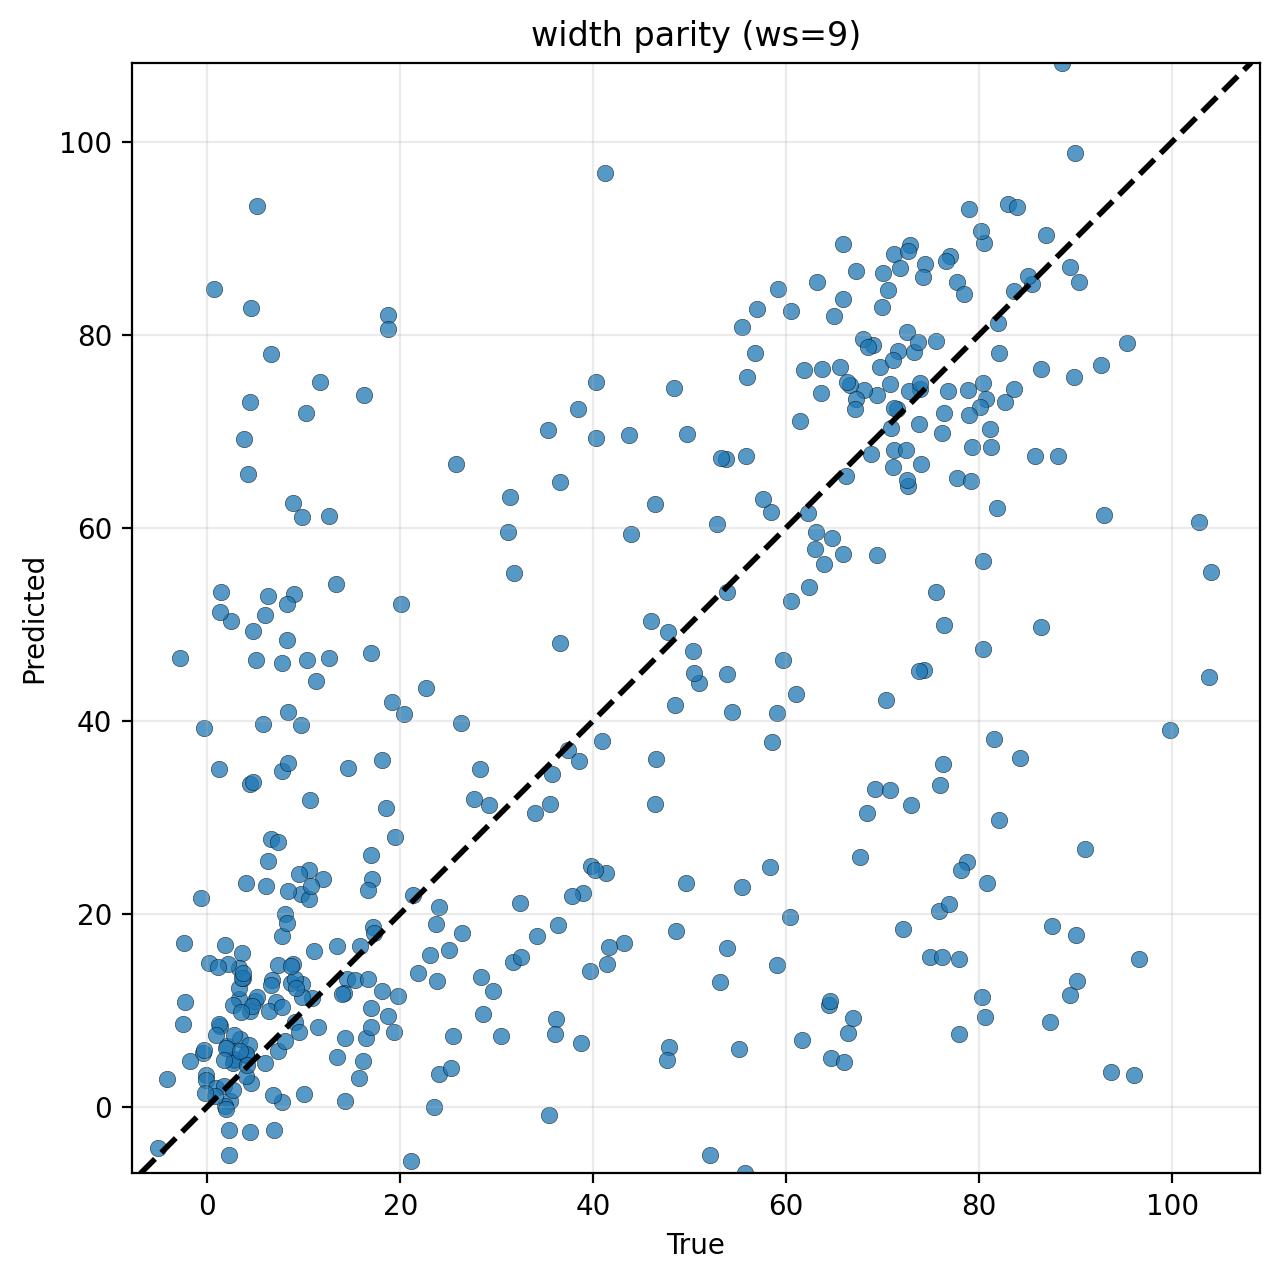

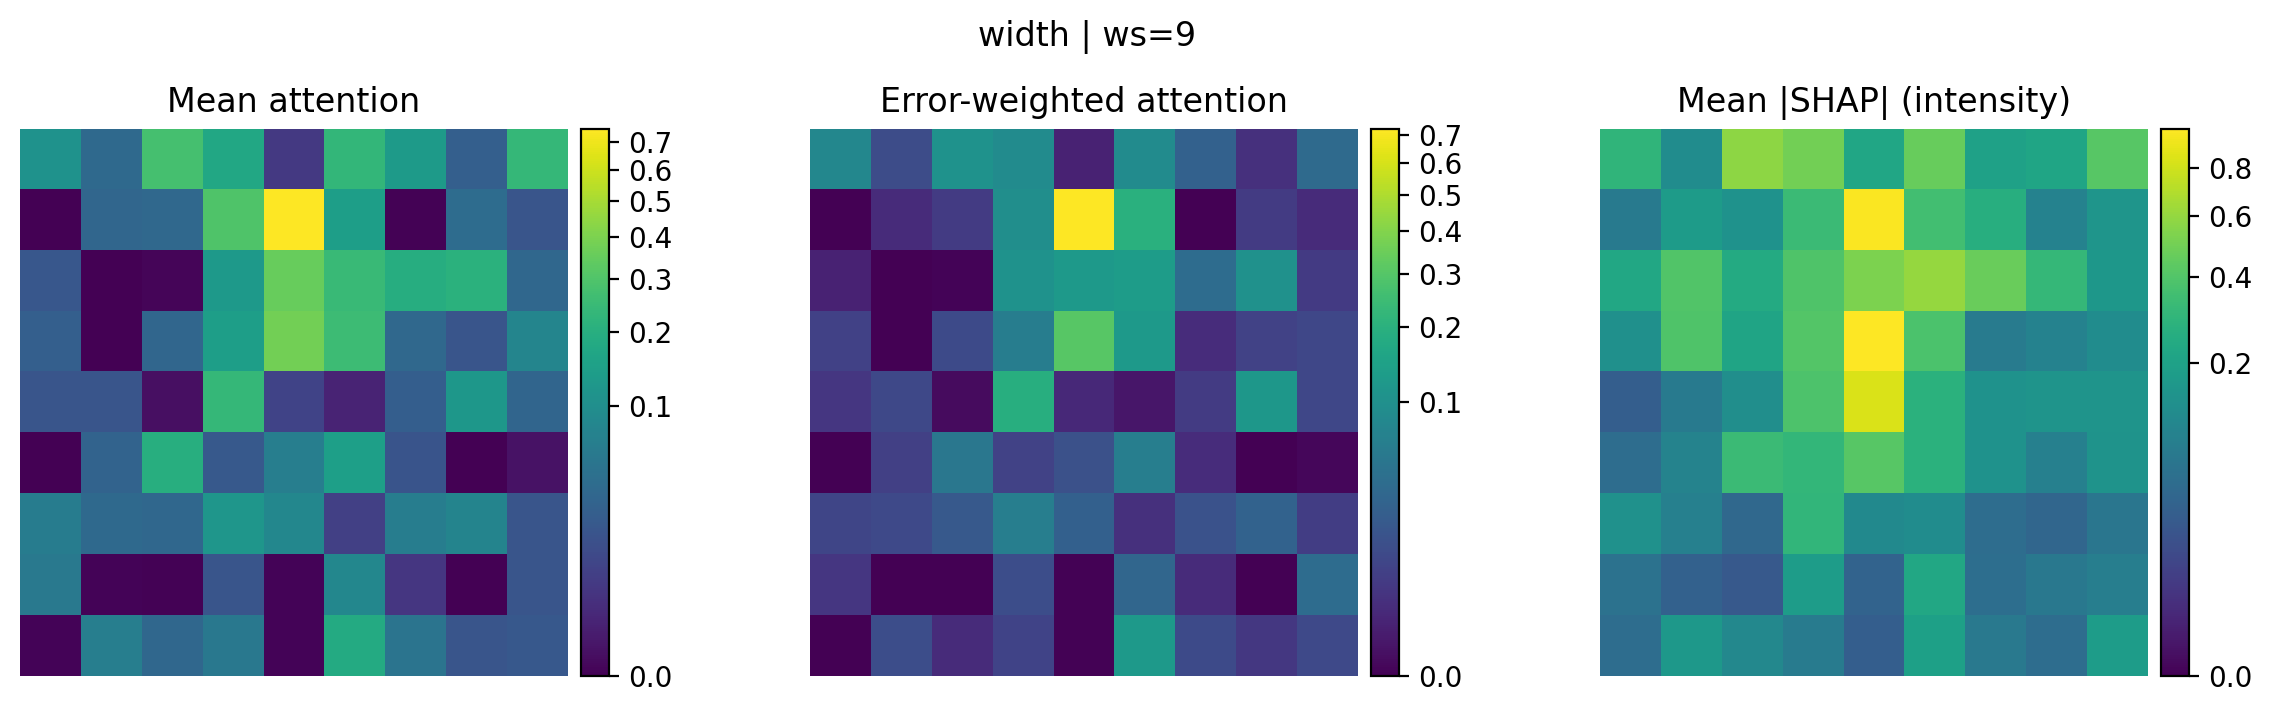


=== ws=25 | target=A_on | RMSE=0.008101 ===


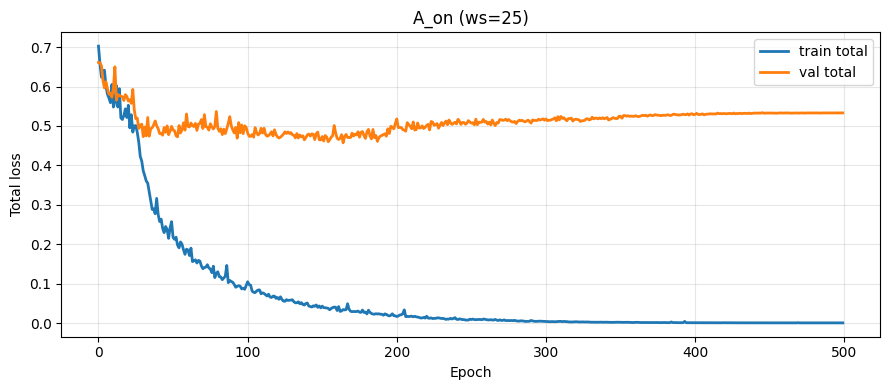

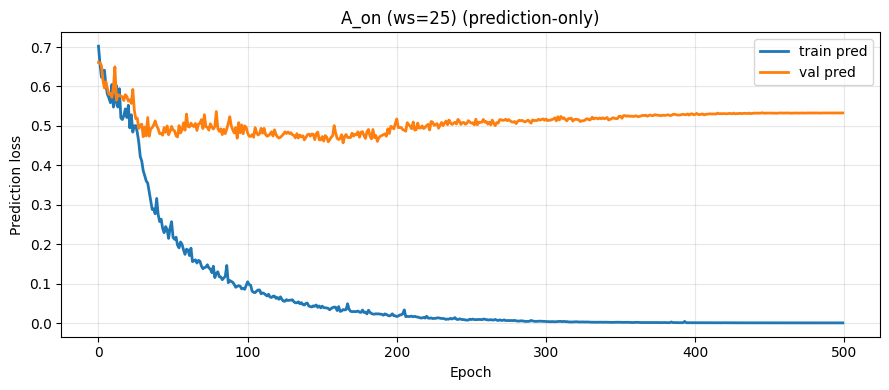

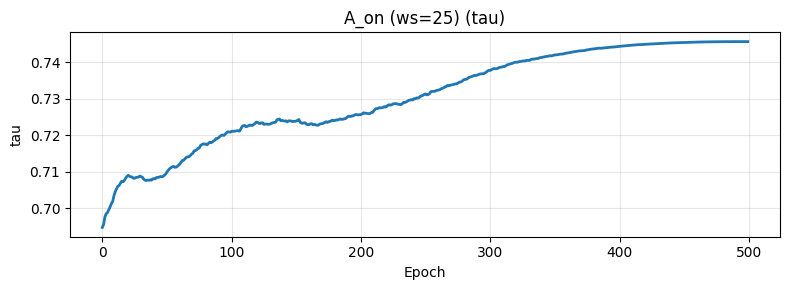

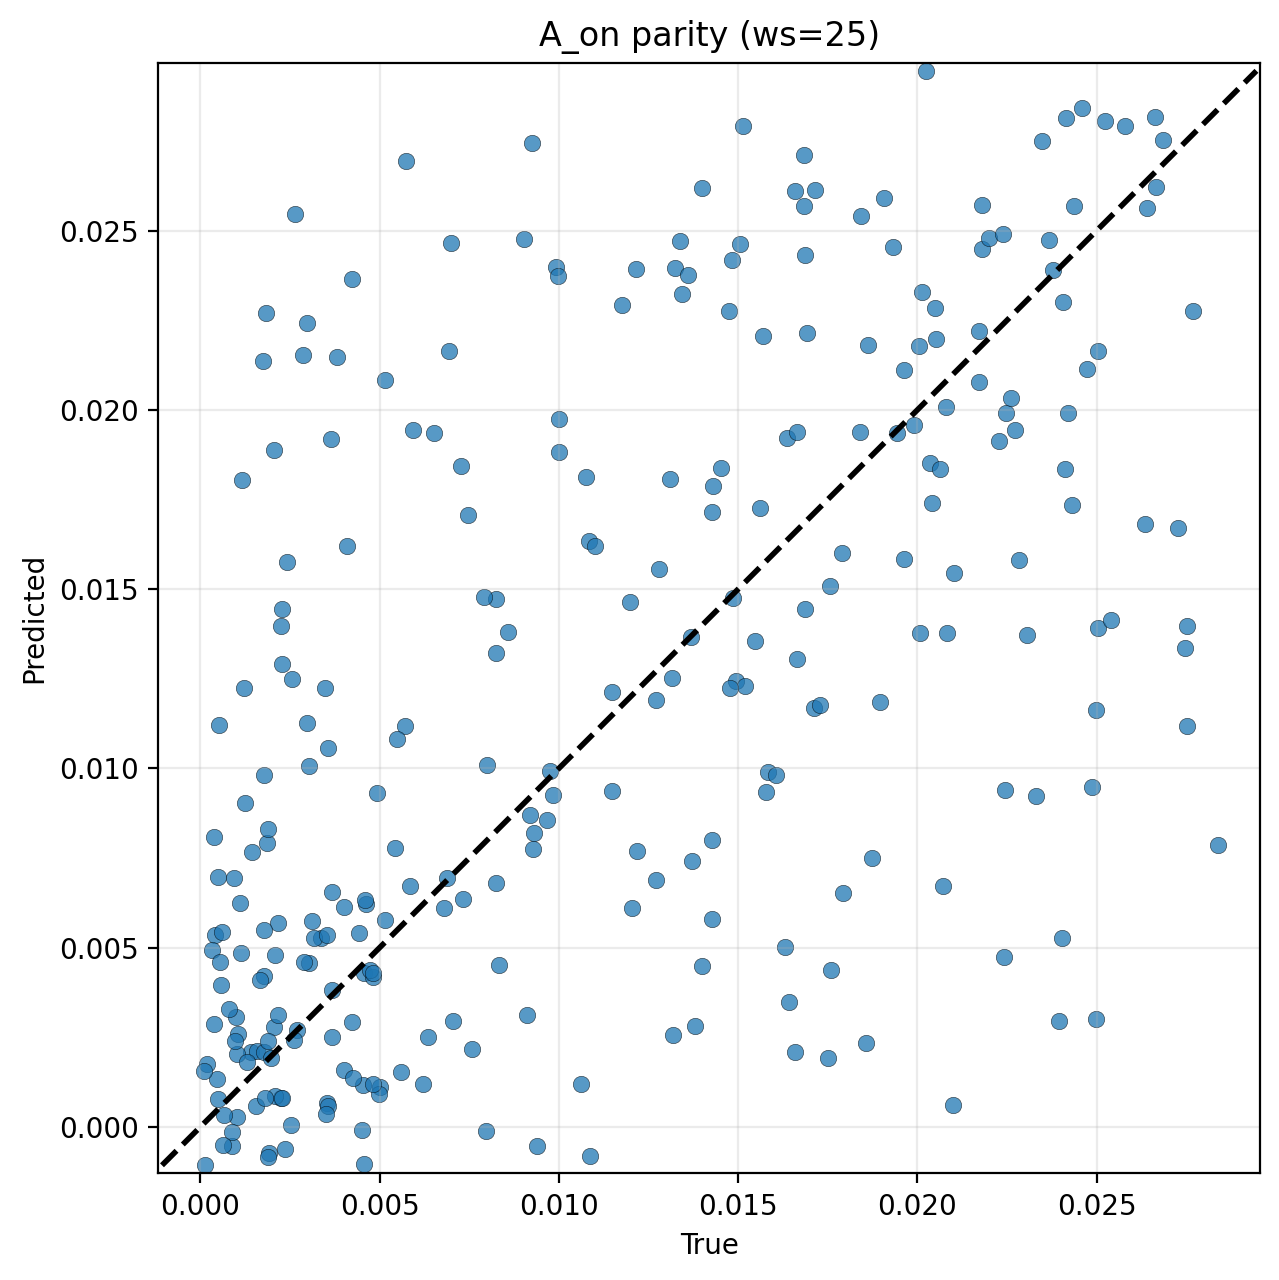

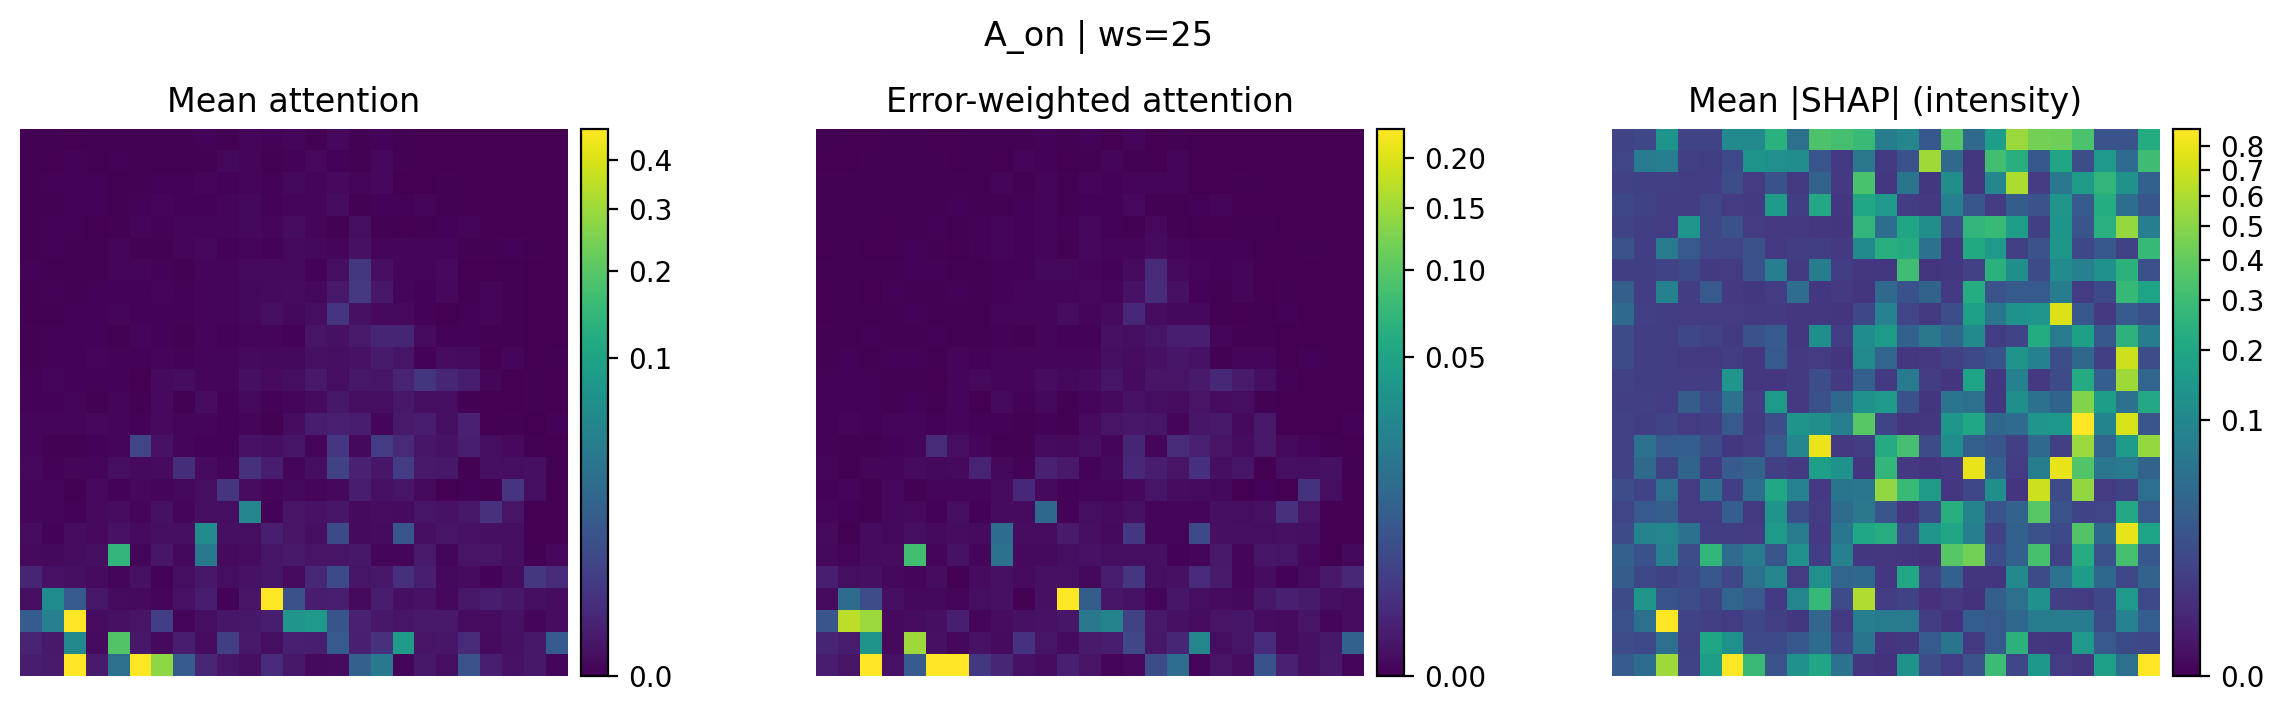


=== ws=25 | target=A_off | RMSE=0.007572 ===


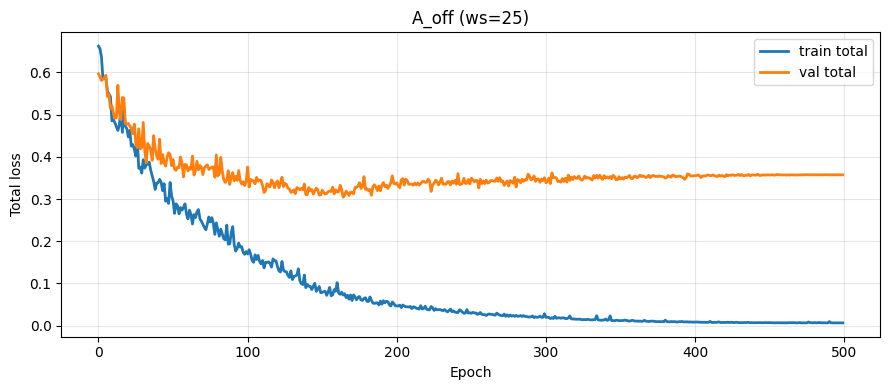

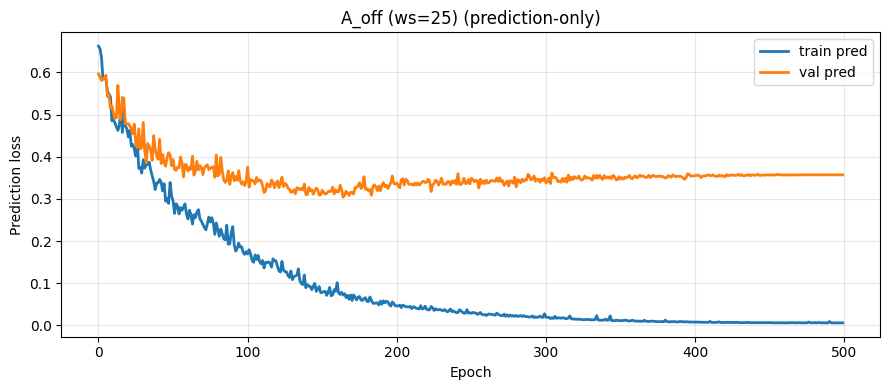

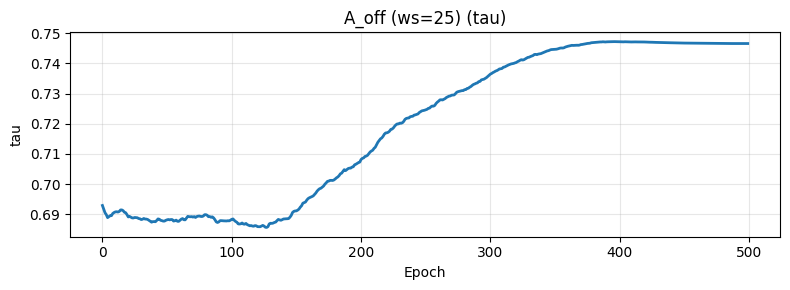

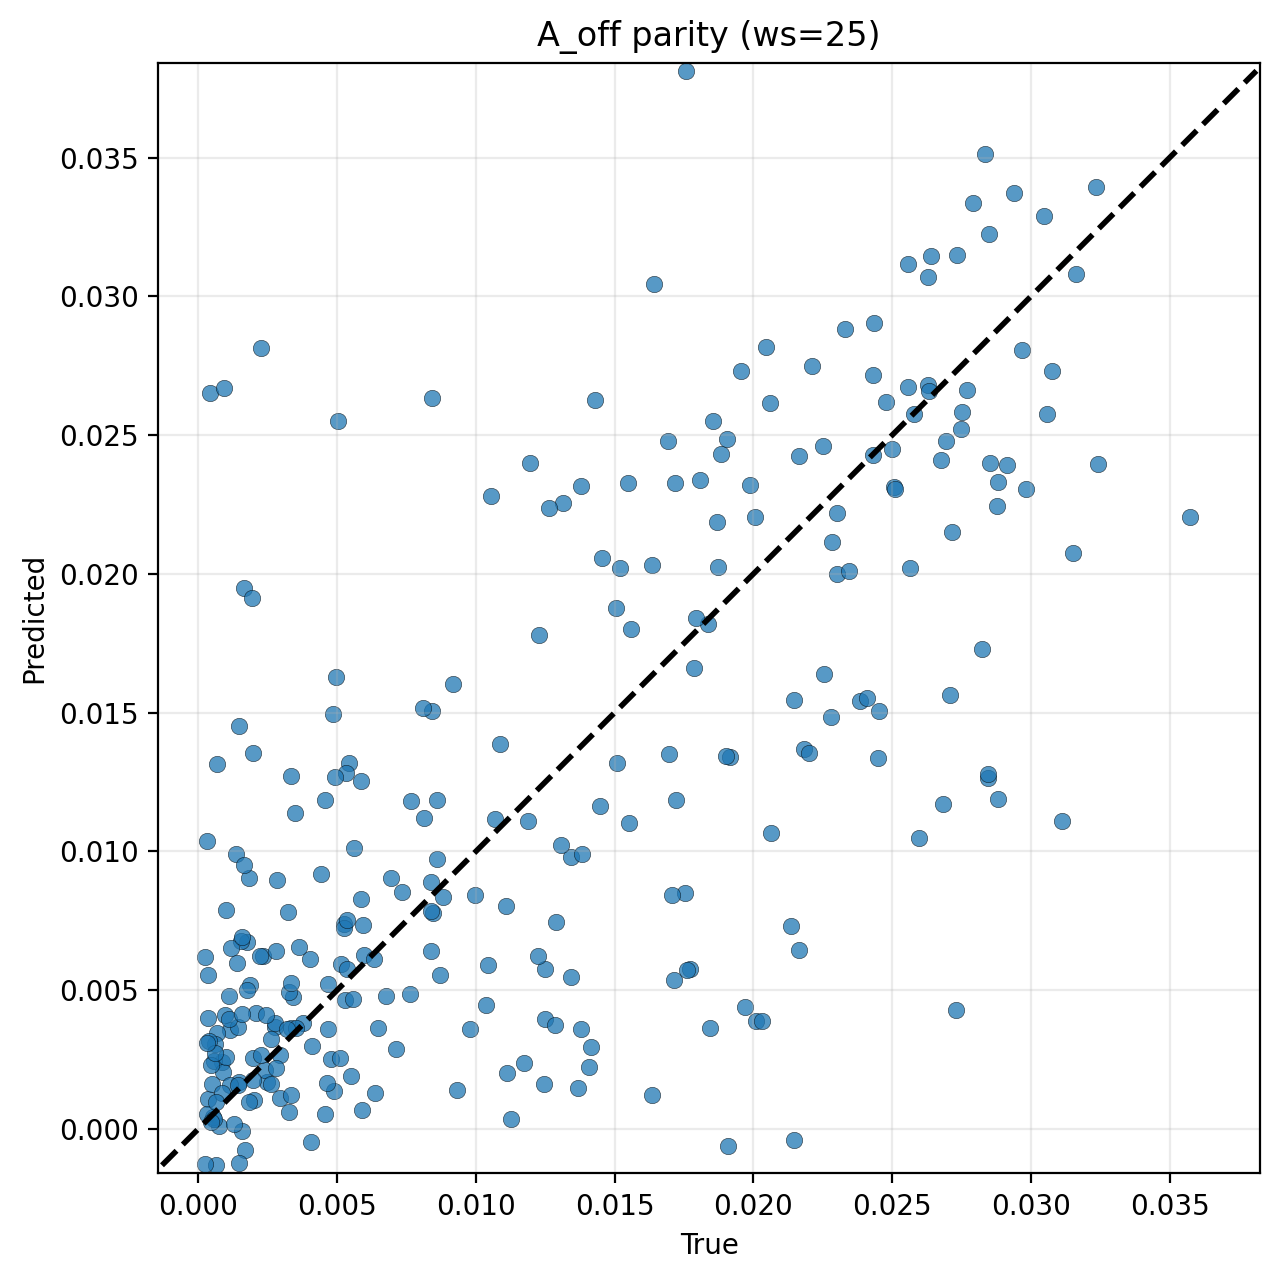

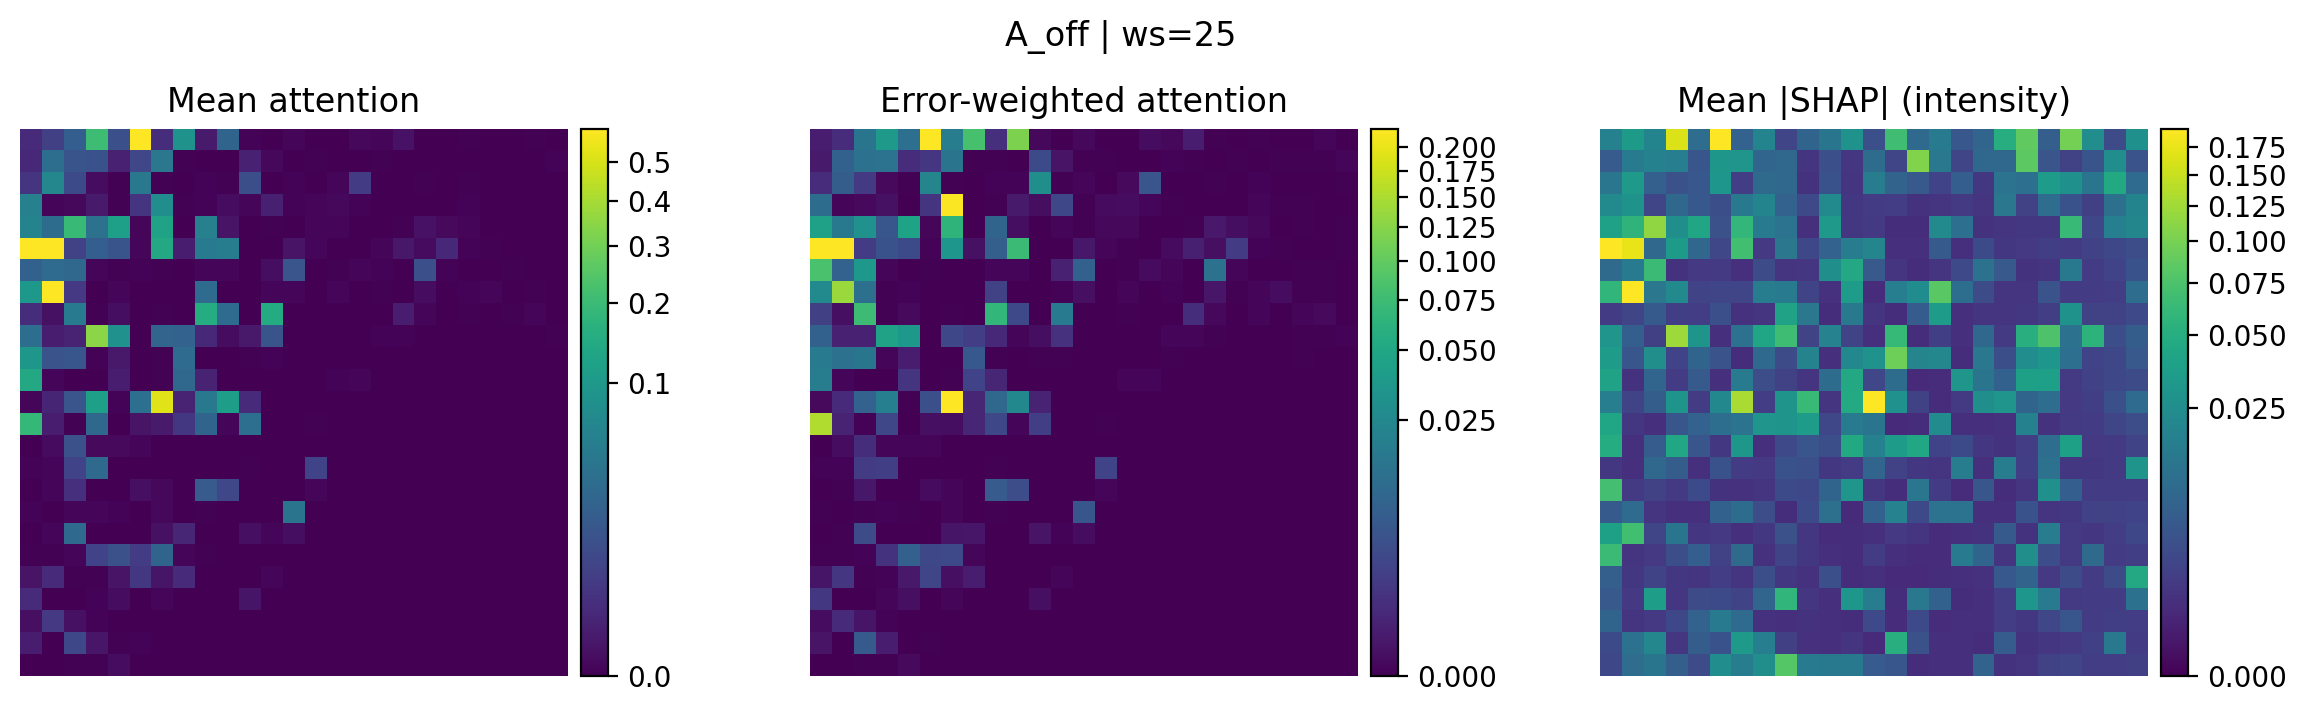


=== ws=25 | target=Cf | RMSE=2.213 ===


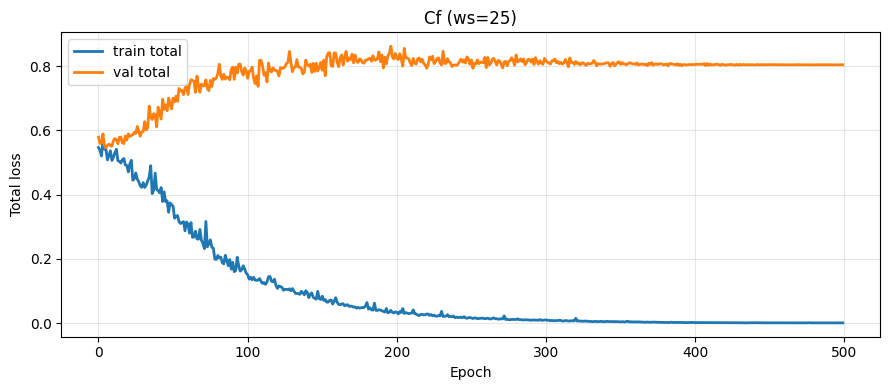

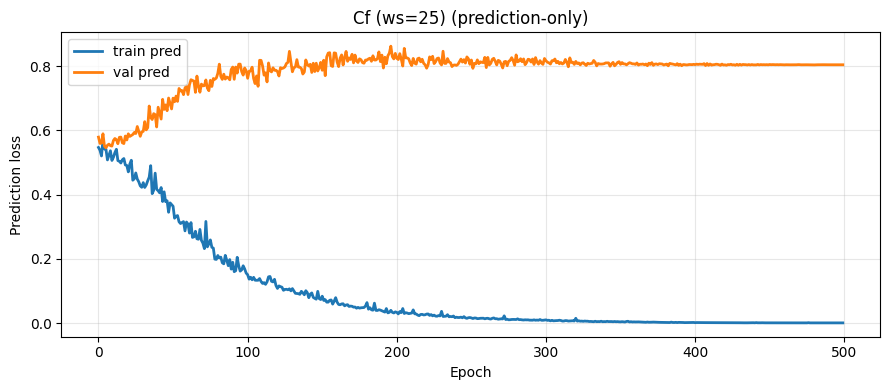

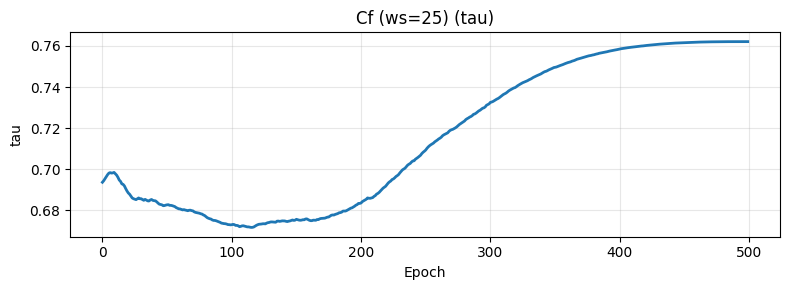

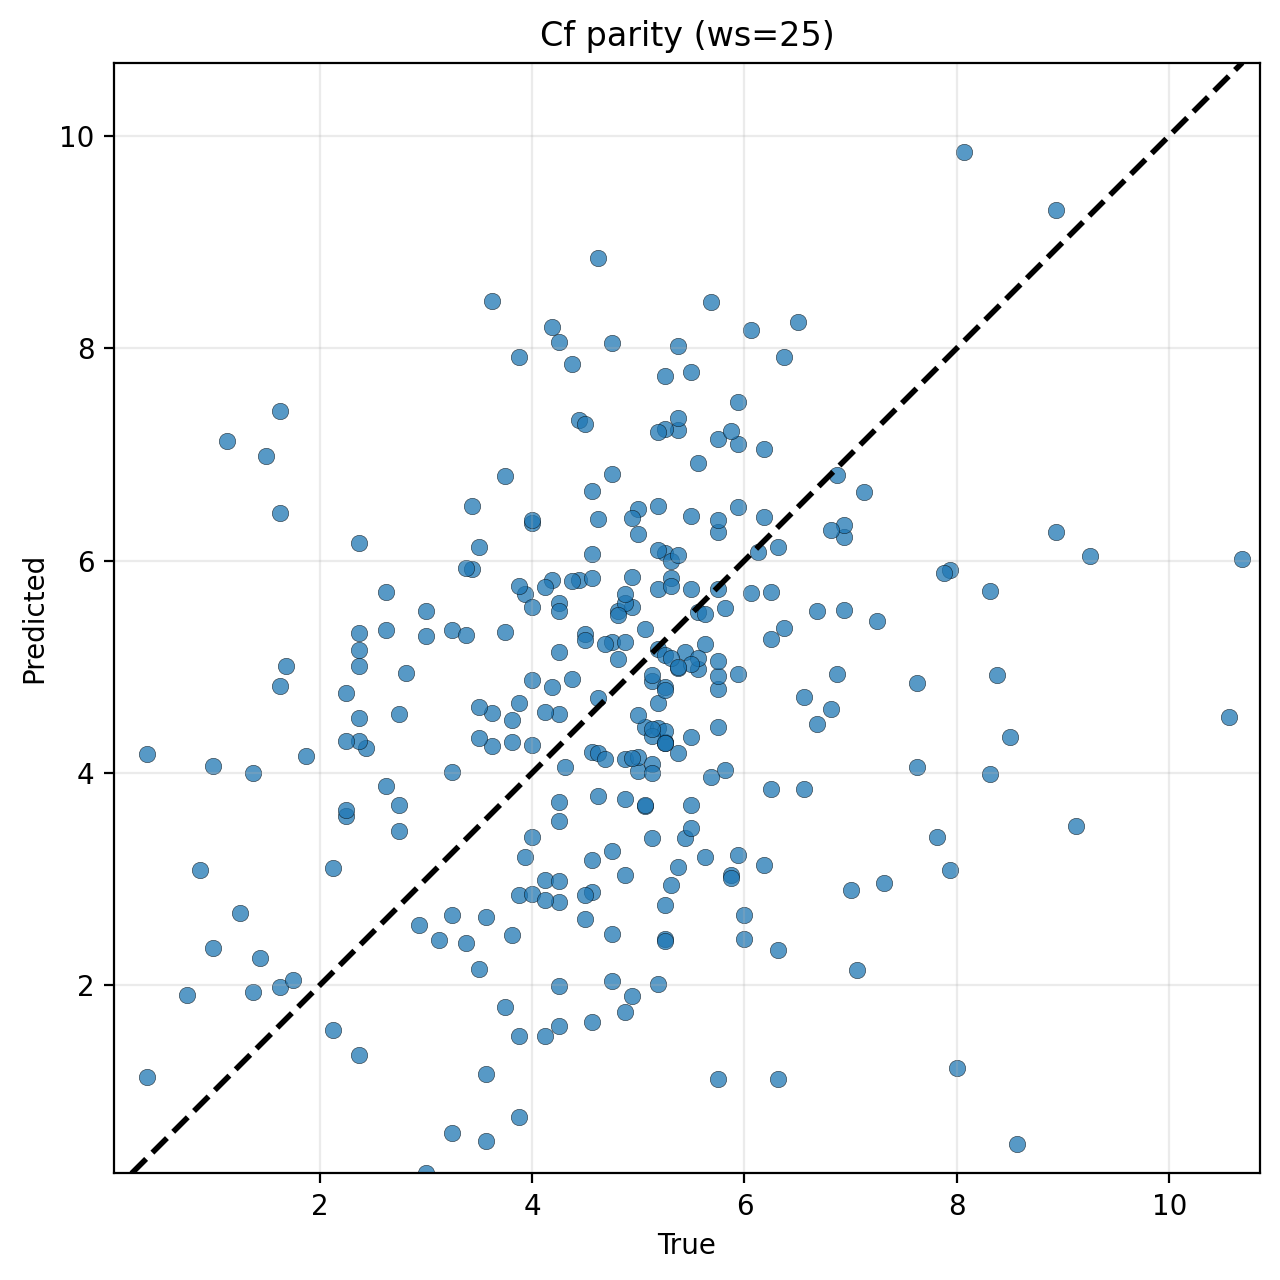

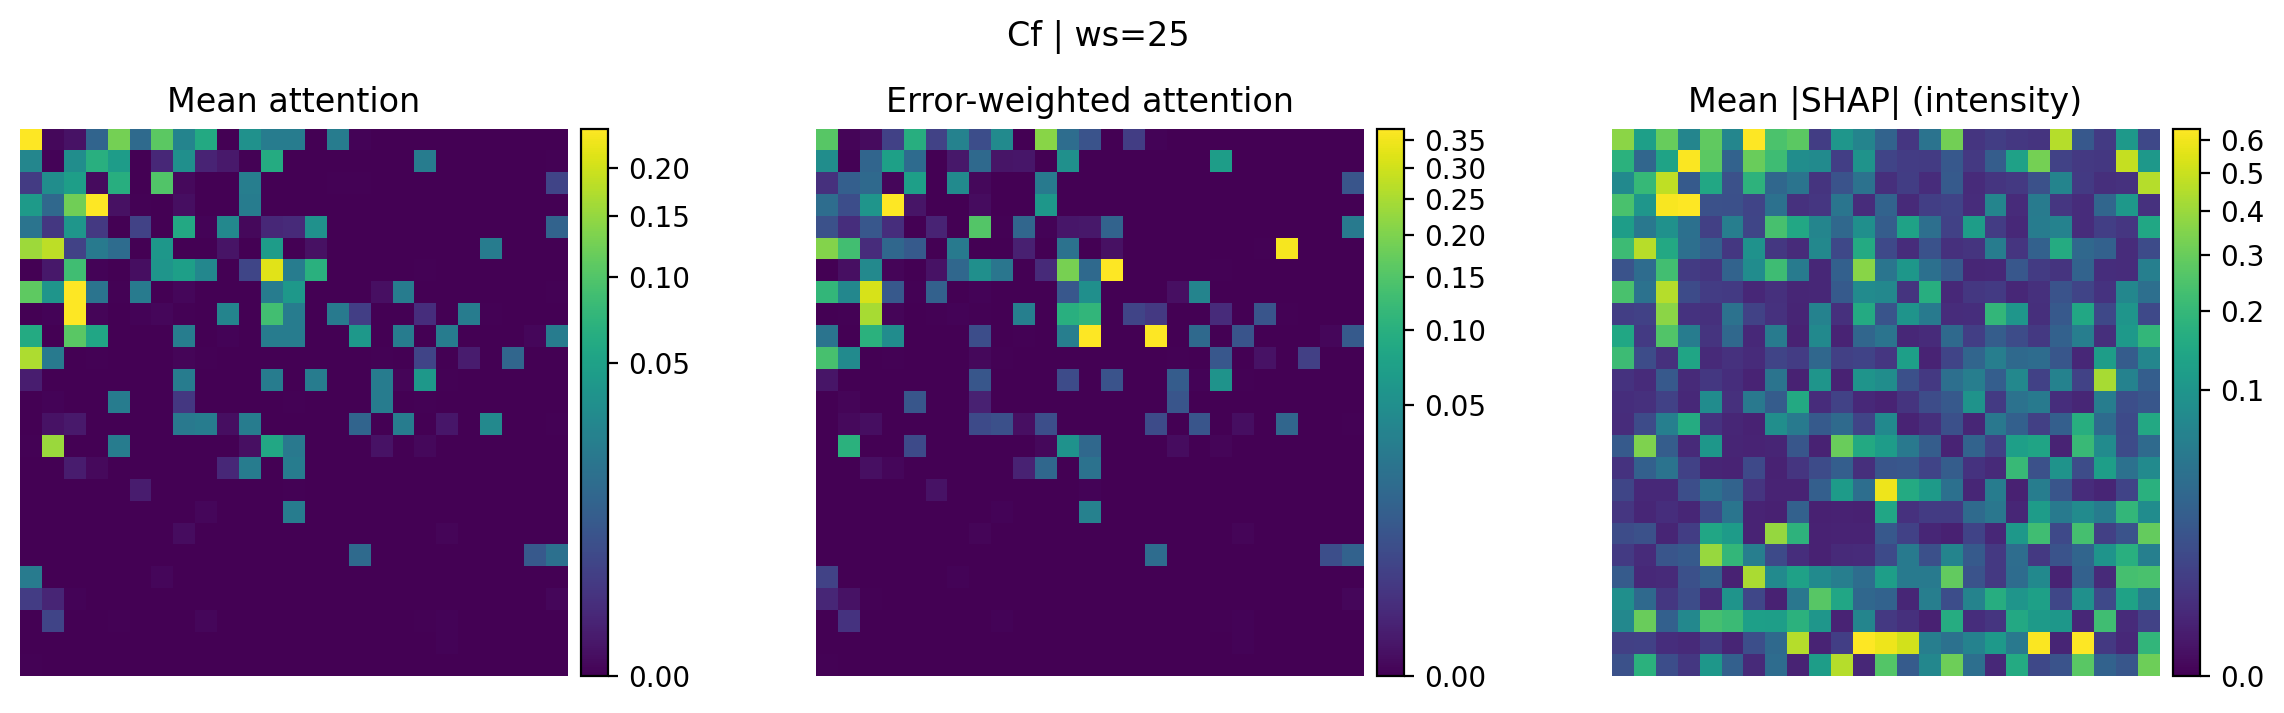


=== ws=25 | target=bias | RMSE=2.842 ===


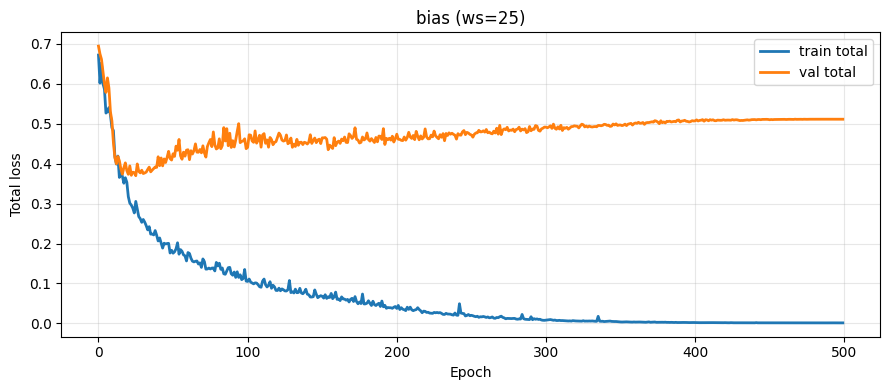

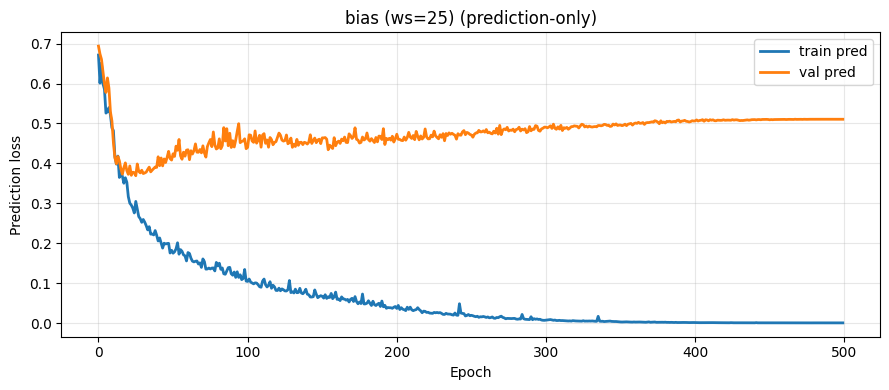

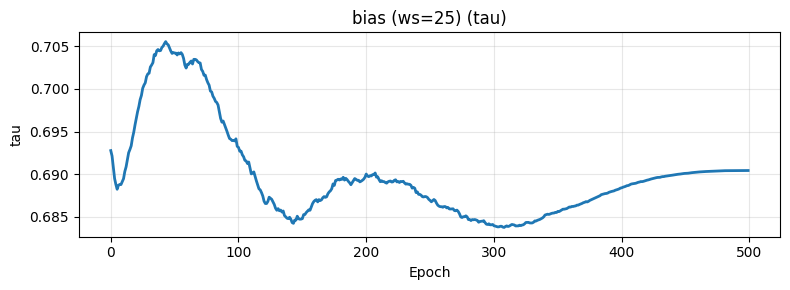

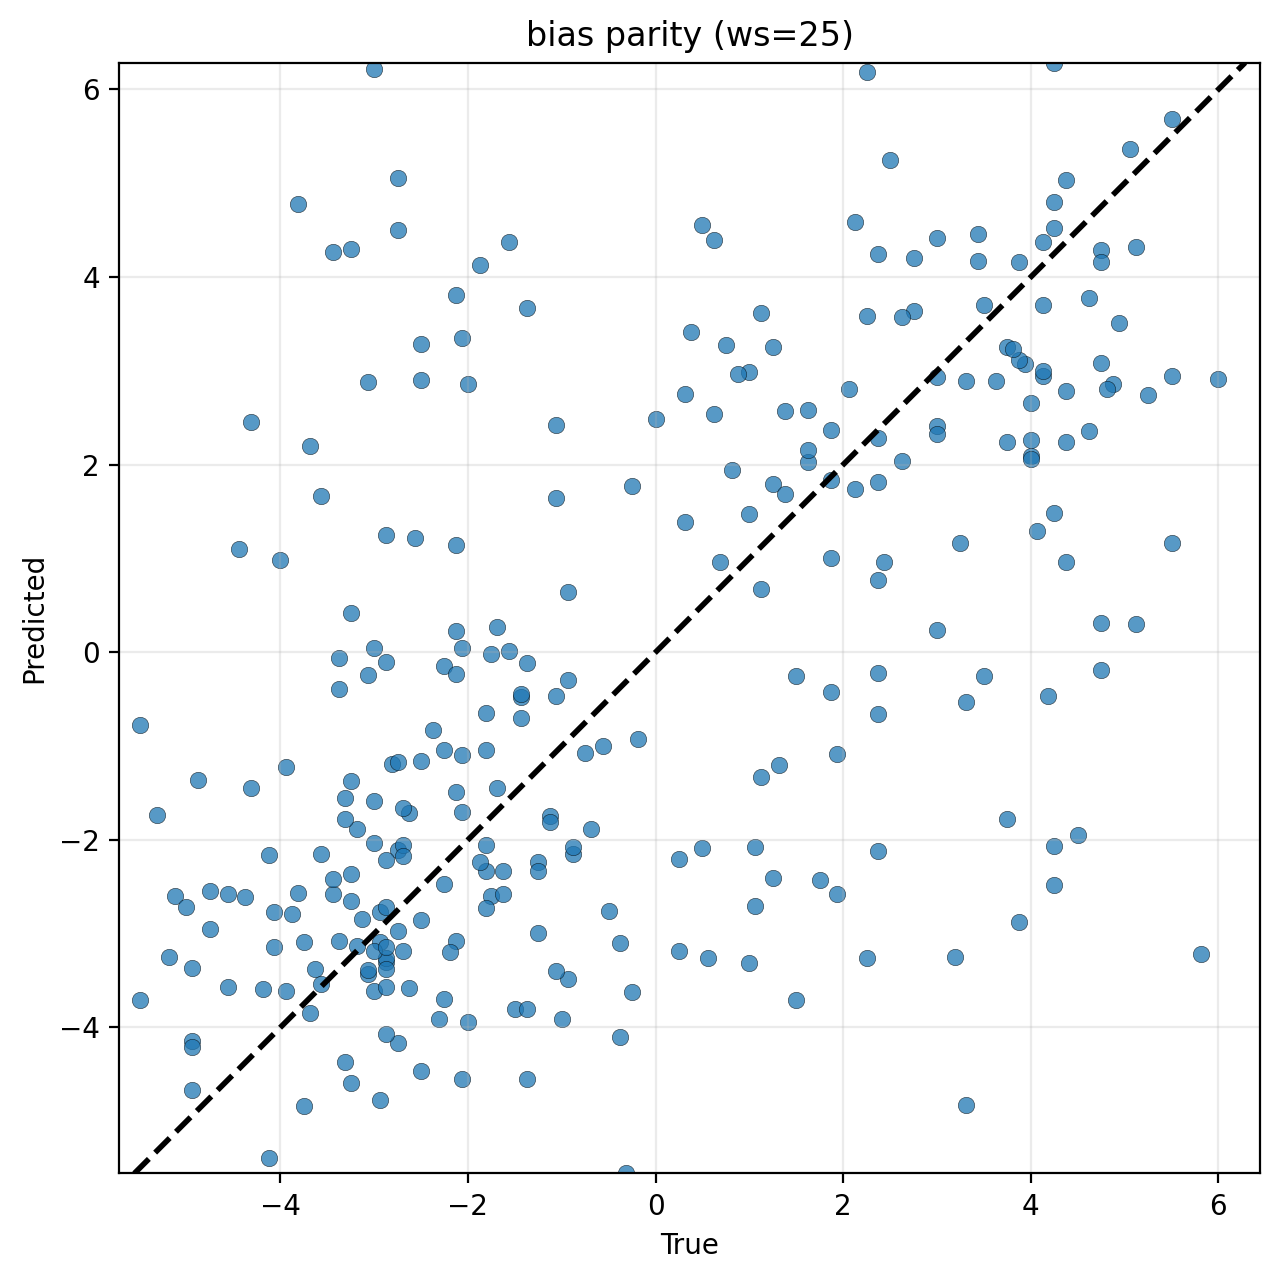

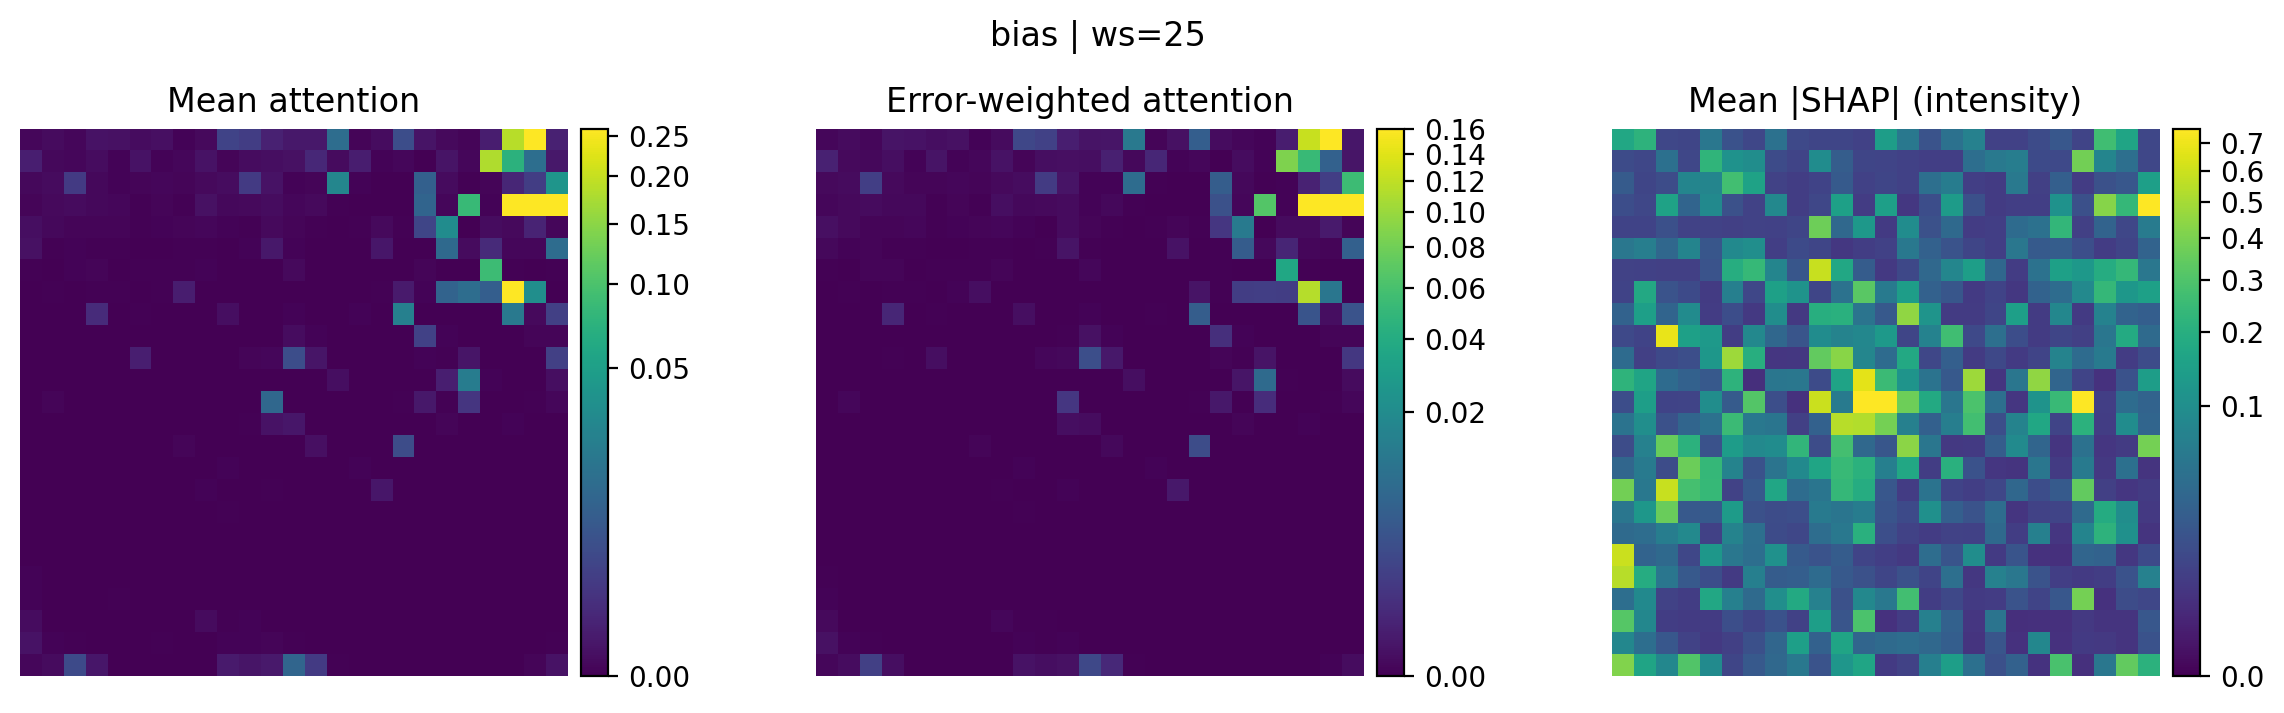


=== ws=25 | target=width | RMSE=24.77 ===


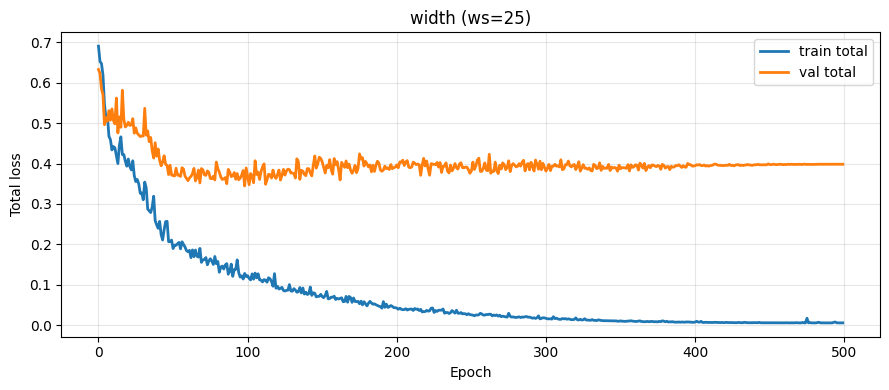

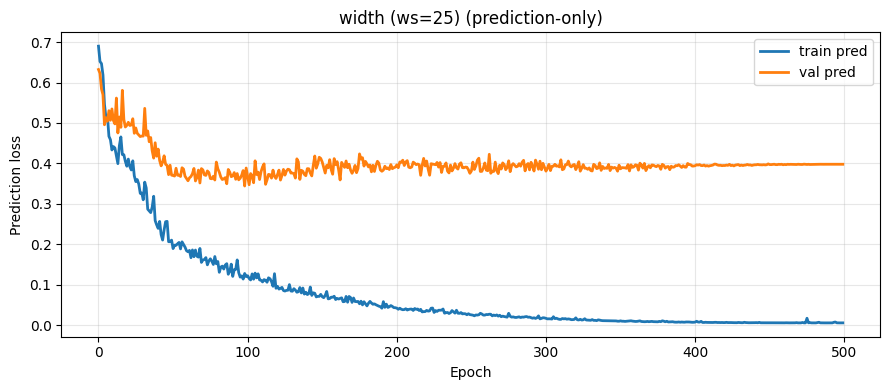

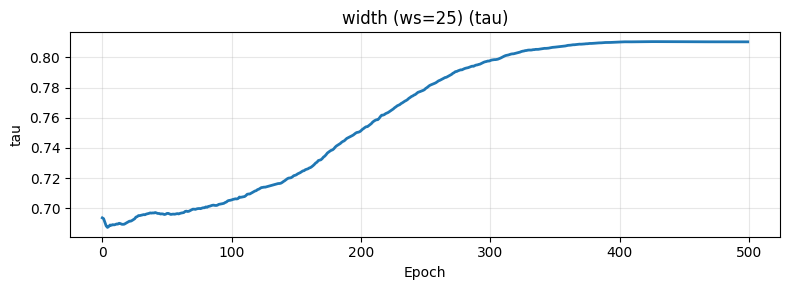

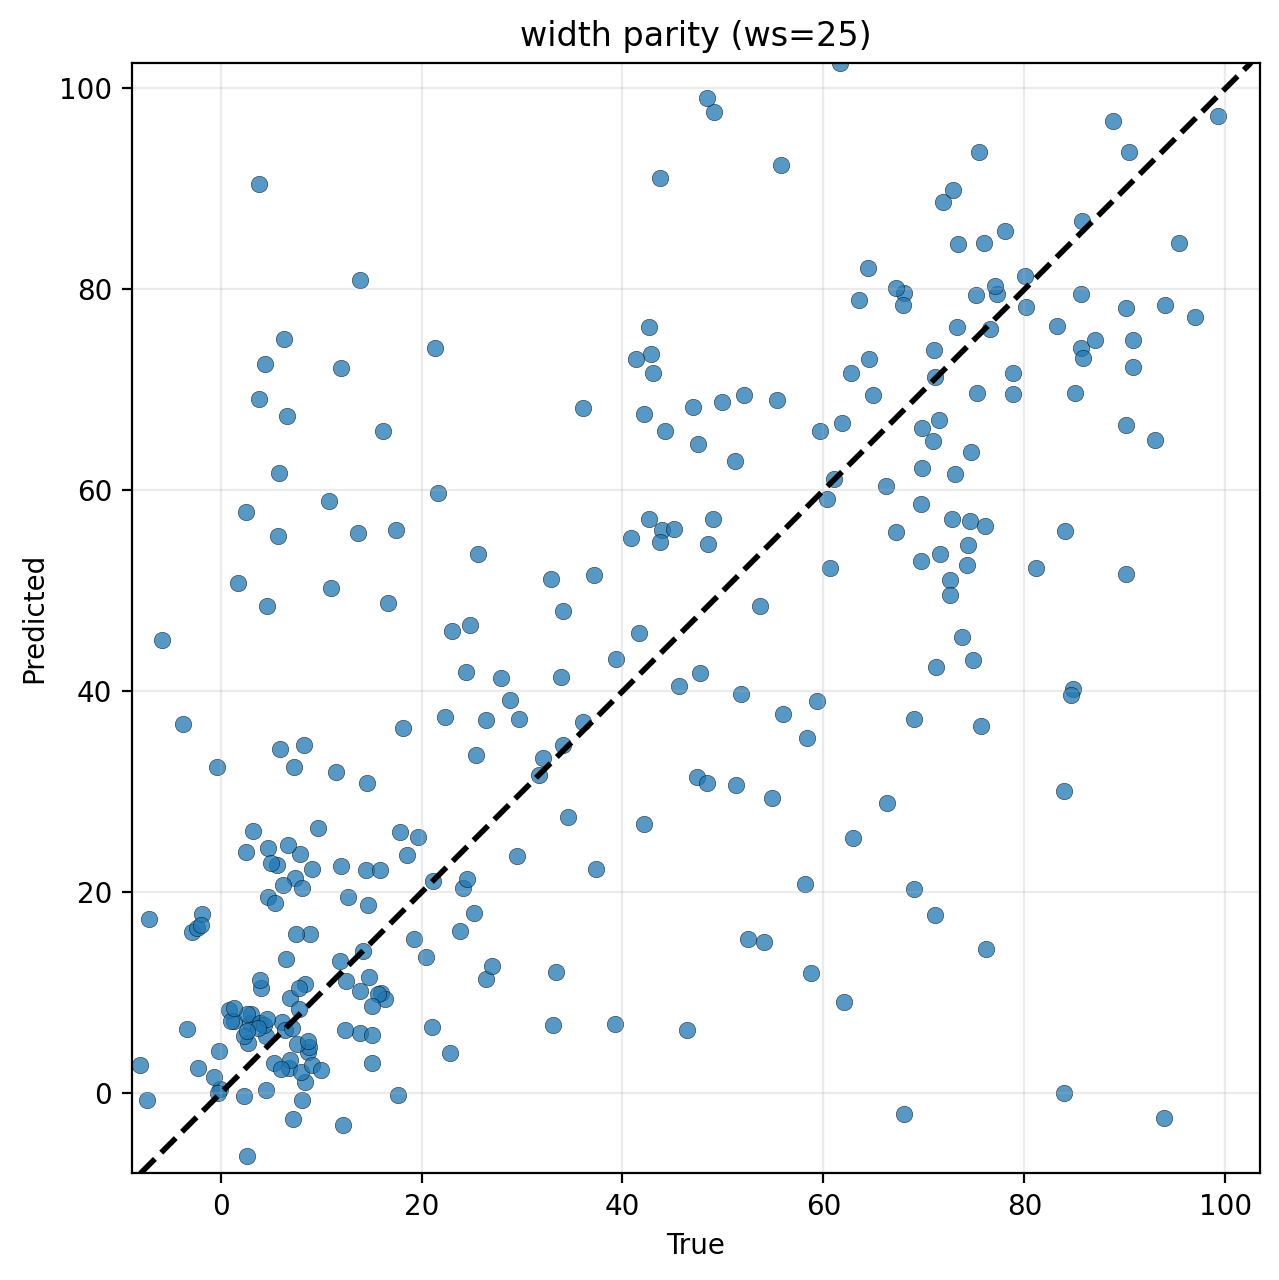

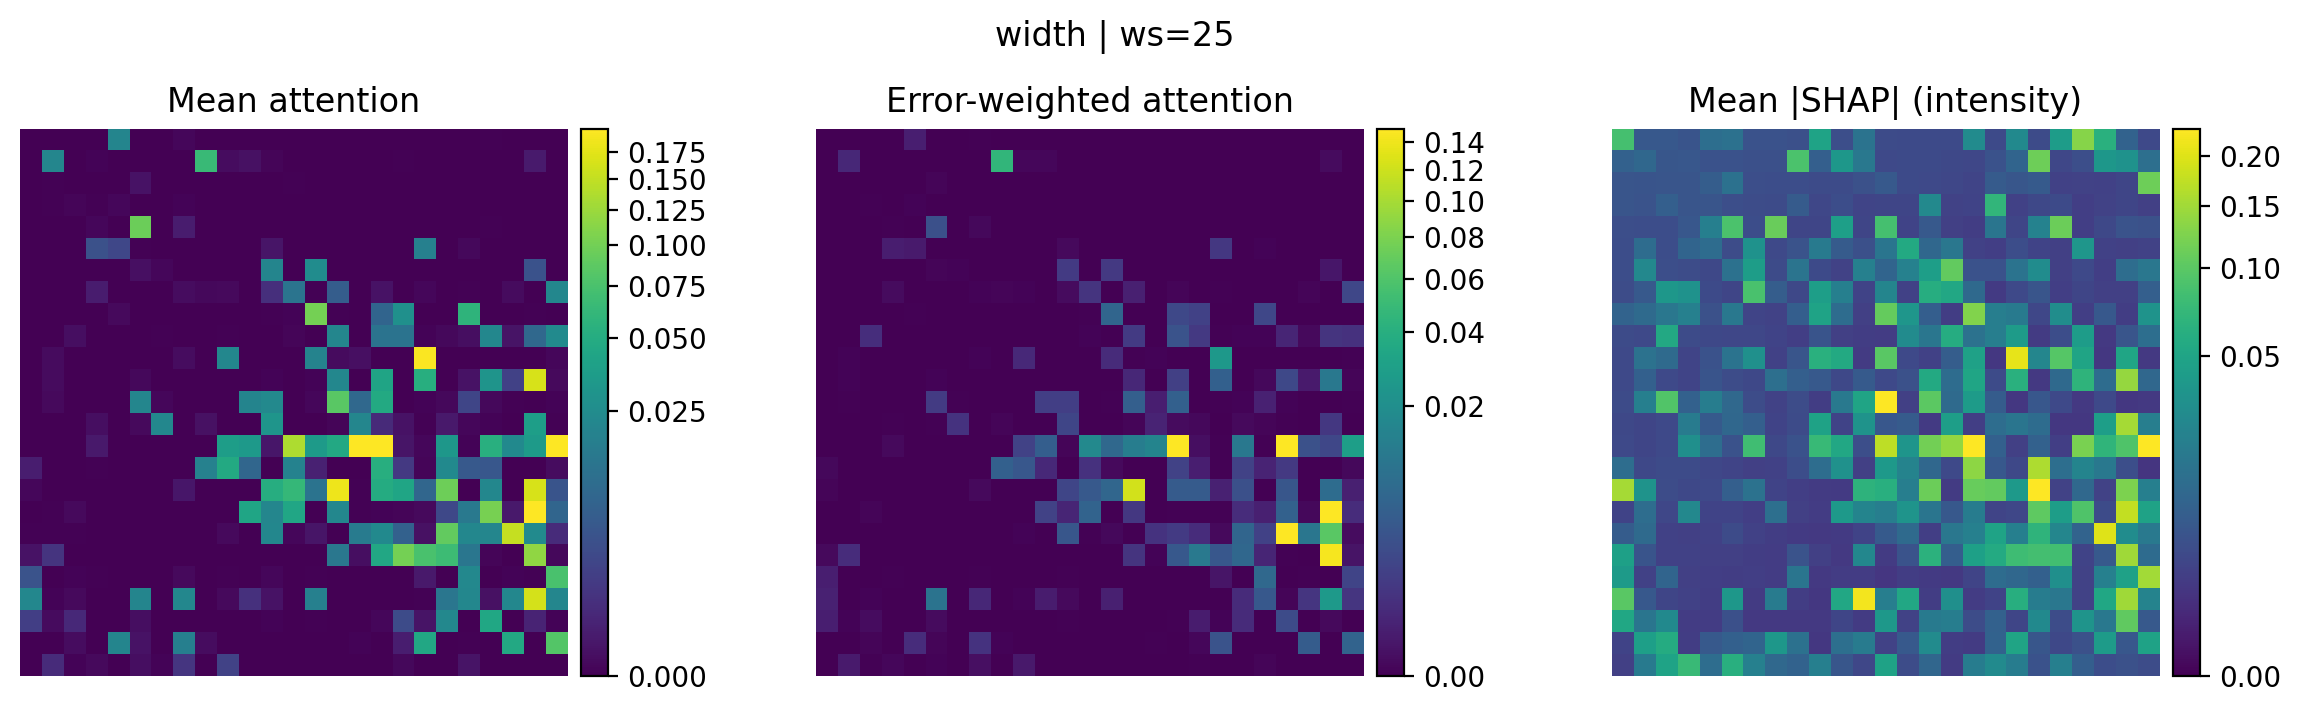

In [17]:
# --- Plots (learning curves, parity, attention+SHAP maps with better contrast) ---

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, LogNorm

def plot_learning_curves(hist, title="Learning curves"):
    plt.figure(figsize=(9,4))
    plt.plot(hist["tr"], label="train total", linewidth=2)
    plt.plot(hist["va"], label="val total", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Total loss")
    plt.title(title); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(hist["tr_pred"], label="train pred", linewidth=2)
    plt.plot(hist["va_pred"], label="val pred", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Prediction loss")
    plt.title(title + " (prediction-only)"); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,3))
    plt.plot(hist["tau"], linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("tau")
    plt.title(title + " (tau)"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


def plot_parity(y_true, y_pred, title="Parity"):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    mn = float(min(y_true.min(), y_pred.min()))
    mx = float(max(y_true.max(), y_pred.max()))
    plt.figure(figsize=(6.5,6.5), dpi=200)
    plt.scatter(y_true, y_pred, s=35, alpha=0.75, edgecolor="k", linewidth=0.2)
    plt.plot([mn,mx],[mn,mx],"k--",lw=2)
    plt.xlabel("True"); plt.ylabel("Predicted")
    plt.title(title); plt.axis("equal"); plt.xlim(mn,mx); plt.ylim(mn,mx)
    plt.grid(True, alpha=0.25)
    plt.tight_layout(); plt.show()


def plot_attention_maps(alpha_mean, alpha_w, shapI, ws, title_prefix="",
                        # Contrast controls:
                        gamma_att=0.35, gamma_shap=0.35,
                        use_log_shap=False,
                        # Robust scaling (prevents one hot pixel dominating):
                        clip_pct_att=99.5, clip_pct_shap=99.57,
                        cmap_att="viridis", cmap_shap="viridis"):
    """
    Display-only contrast boost for both attention and SHAP.
    - Uses robust vmax = percentile (so more structure shows up)
    - Uses PowerNorm(gamma<1) to lift low/mid values
    - Optional LogNorm for SHAP if it's extremely heavy-tailed
    """
    am = np.asarray(alpha_mean, float).reshape(ws, ws)
    aw = np.asarray(alpha_w, float).reshape(ws, ws)
    sm = np.asarray(shapI, float).reshape(ws, ws)

    eps = 1e-12

    # clip to non-negative (attention and mean|SHAP| should be >=0 already)
    am = np.clip(am, 0, None)
    aw = np.clip(aw, 0, None)
    sm = np.clip(sm, 0, None)

    # Robust vmax to show more values
    am_vmax = np.percentile(am, clip_pct_att)
    aw_vmax = np.percentile(aw, clip_pct_att)
    sm_vmax = np.percentile(sm, clip_pct_shap)

    # Norms
    att_norm_am = PowerNorm(gamma=gamma_att, vmin=0, vmax=am_vmax + eps)
    att_norm_aw = PowerNorm(gamma=gamma_att, vmin=0, vmax=aw_vmax + eps)

    if use_log_shap:
        # Pick a small positive vmin for LogNorm
        sm_pos = sm[sm > 0]
        sm_vmin = max(np.percentile(sm_pos, 5), eps) if sm_pos.size else eps
        shap_norm = LogNorm(vmin=sm_vmin, vmax=sm_vmax + eps)
    else:
        shap_norm = PowerNorm(gamma=gamma_shap, vmin=0, vmax=sm_vmax + eps)

    plt.figure(figsize=(12,3.5), dpi=200)

    ax = plt.subplot(1,3,1)
    im = ax.imshow(am, norm=att_norm_am, cmap=cmap_att)
    ax.set_title("Mean attention"); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    ax = plt.subplot(1,3,2)
    im = ax.imshow(aw, norm=att_norm_aw, cmap=cmap_att)
    ax.set_title("Error-weighted attention"); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    ax = plt.subplot(1,3,3)
    im = ax.imshow(sm, norm=shap_norm, cmap=cmap_shap)
    ax.set_title("Mean |SHAP| (intensity)"); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    plt.suptitle(f"{title_prefix} | ws={ws}")
    plt.tight_layout()
    plt.show()


# --- Run summaries for each (ws, target) ---
for ws in ws_list:
    for tname in target_names:
        R = full_res[ws][tname]
        S = full_res_shap[ws][tname]
        print(f"\n=== ws={ws} | target={tname} | RMSE={R['rmse']:.4g} ===")
        plot_learning_curves(R["hist"], title=f"{tname} (ws={ws})")
        plot_parity(R["yval_phys"], R["pred_val_phys"], title=f"{tname} parity (ws={ws})")

        # Adjust these if needed:
        plot_attention_maps(
            R["alpha_mean"], R["alpha_w"], S["shapI"], ws,
            title_prefix=tname,
            gamma_att=0.35,
            gamma_shap=0.35,
            use_log_shap=False,      # set True if SHAP is extremely heavy-tailed
            clip_pct_att=99.5,
            clip_pct_shap=99.5
        )


## 9) Per-sample attention overlays

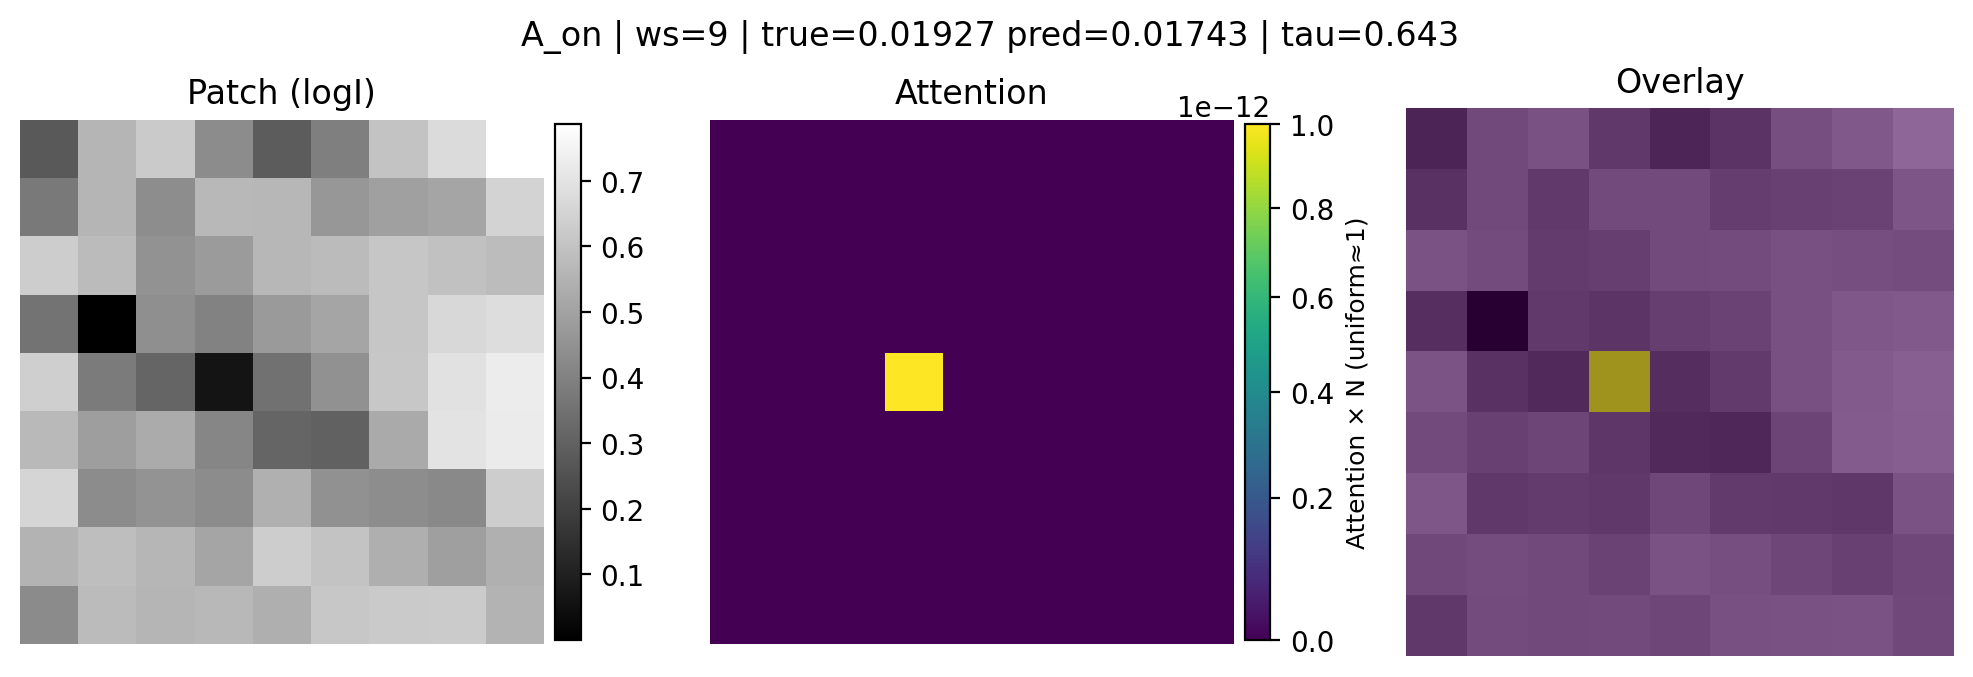

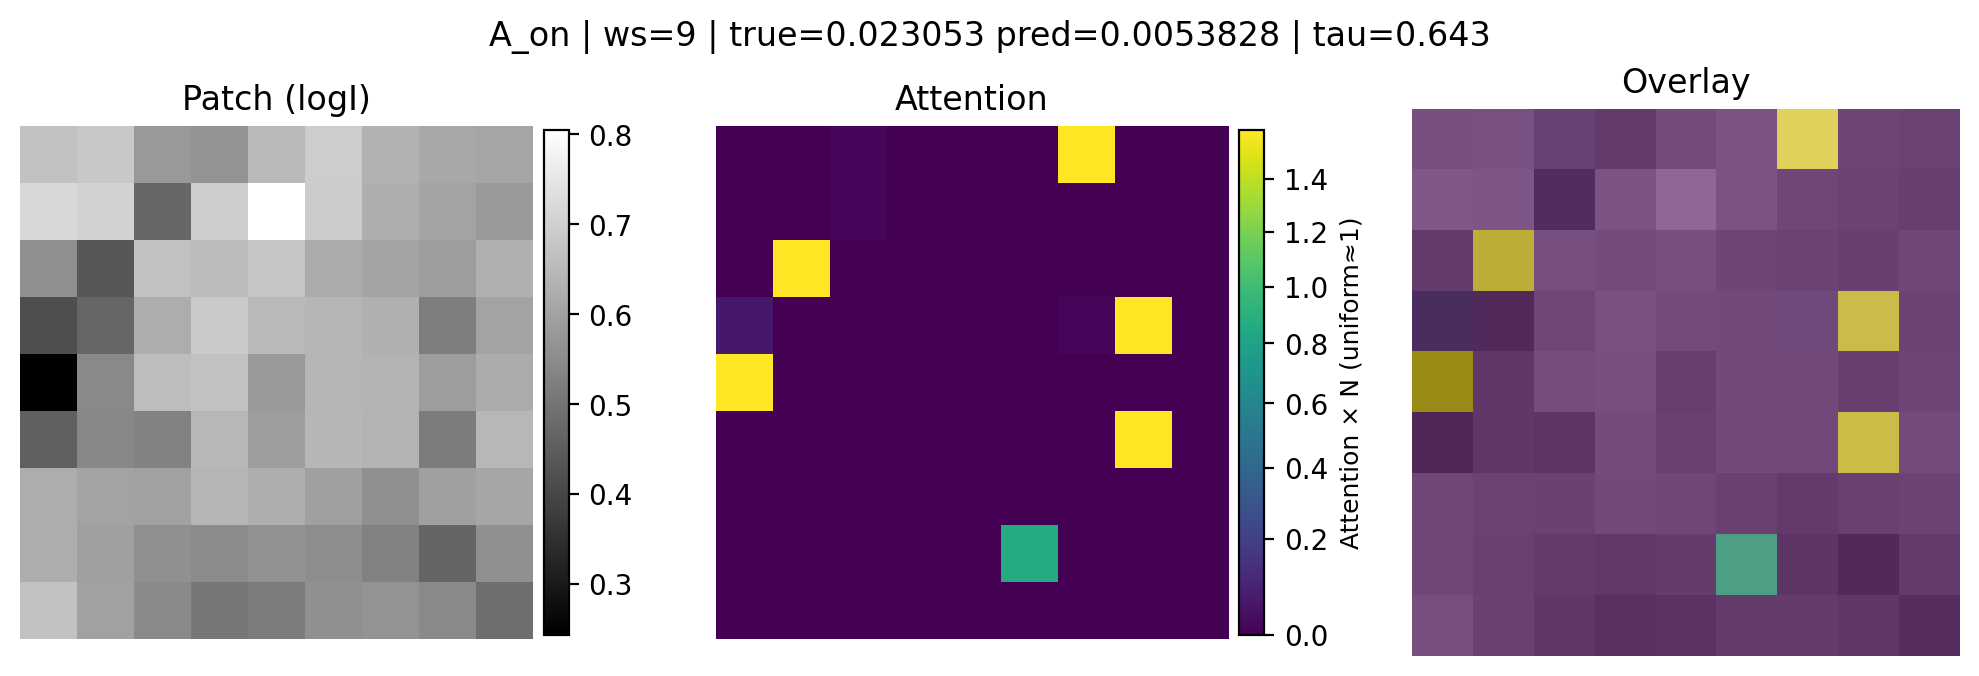

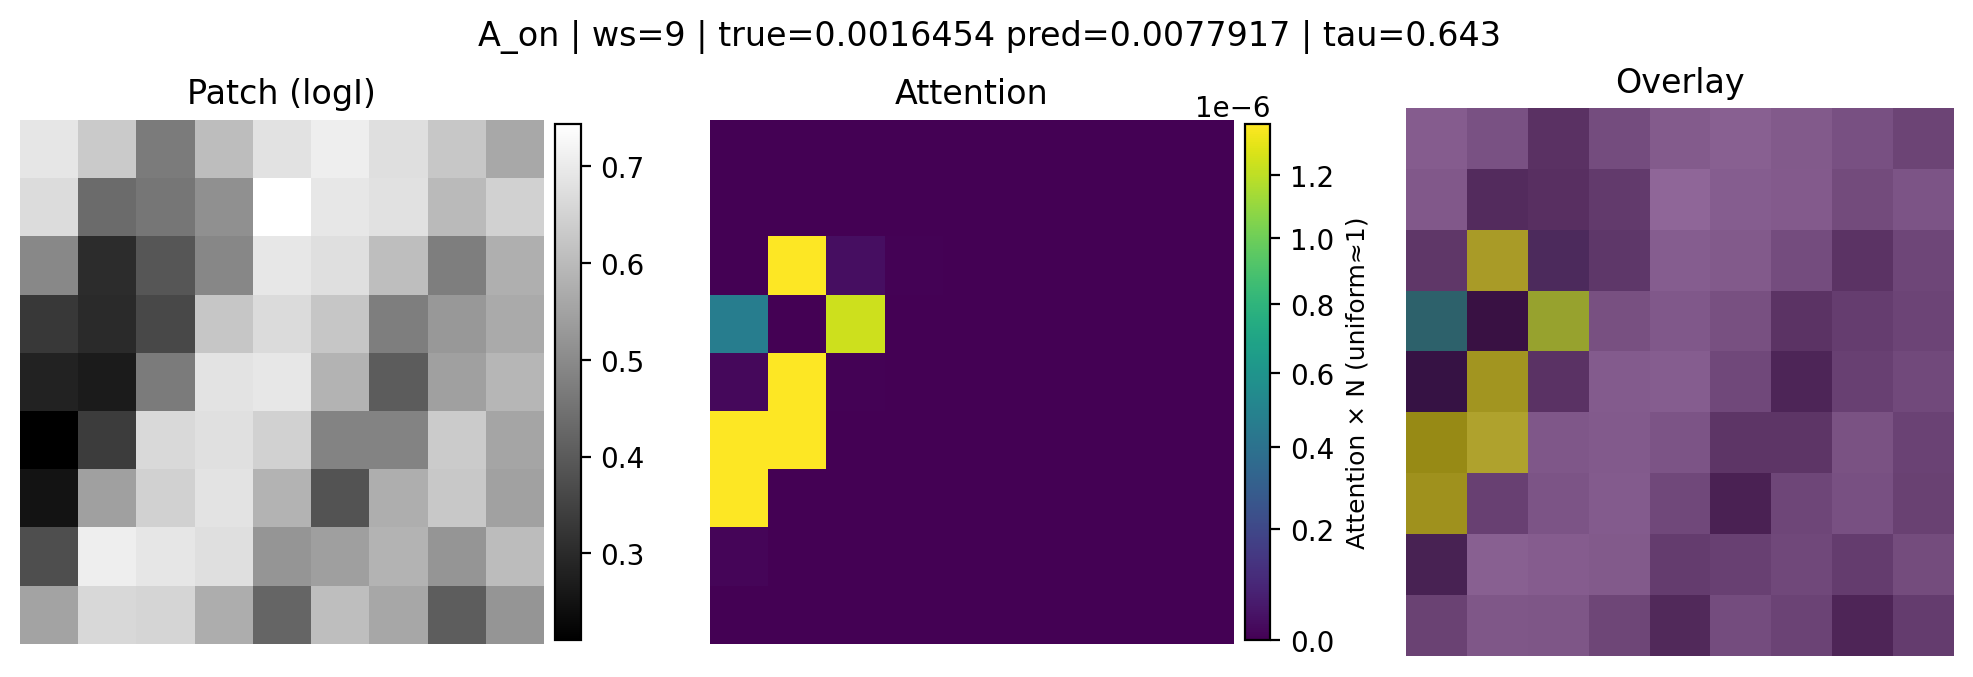

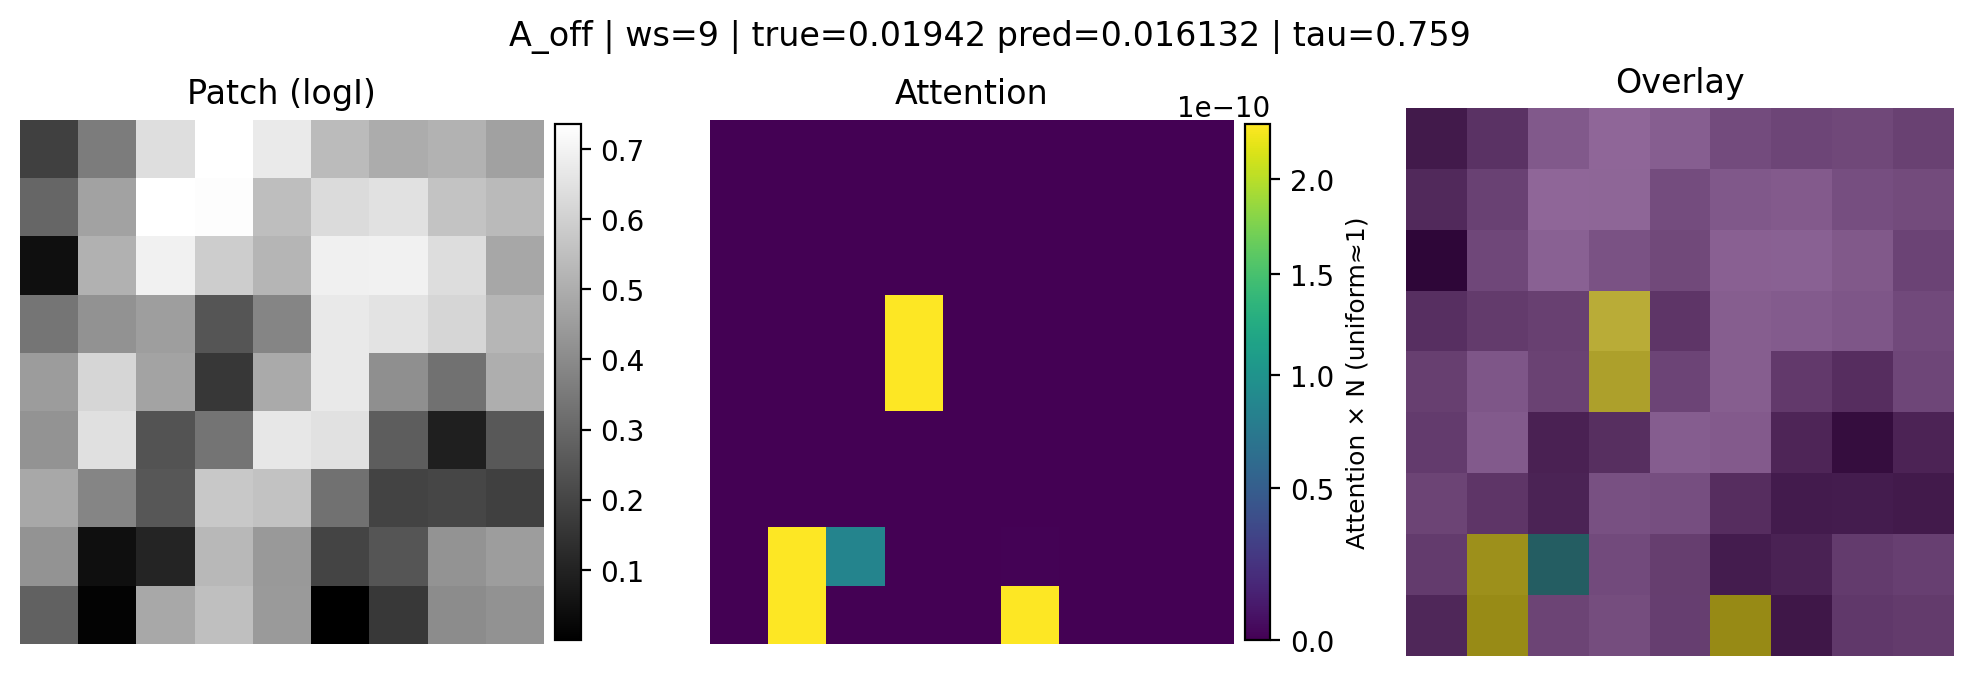

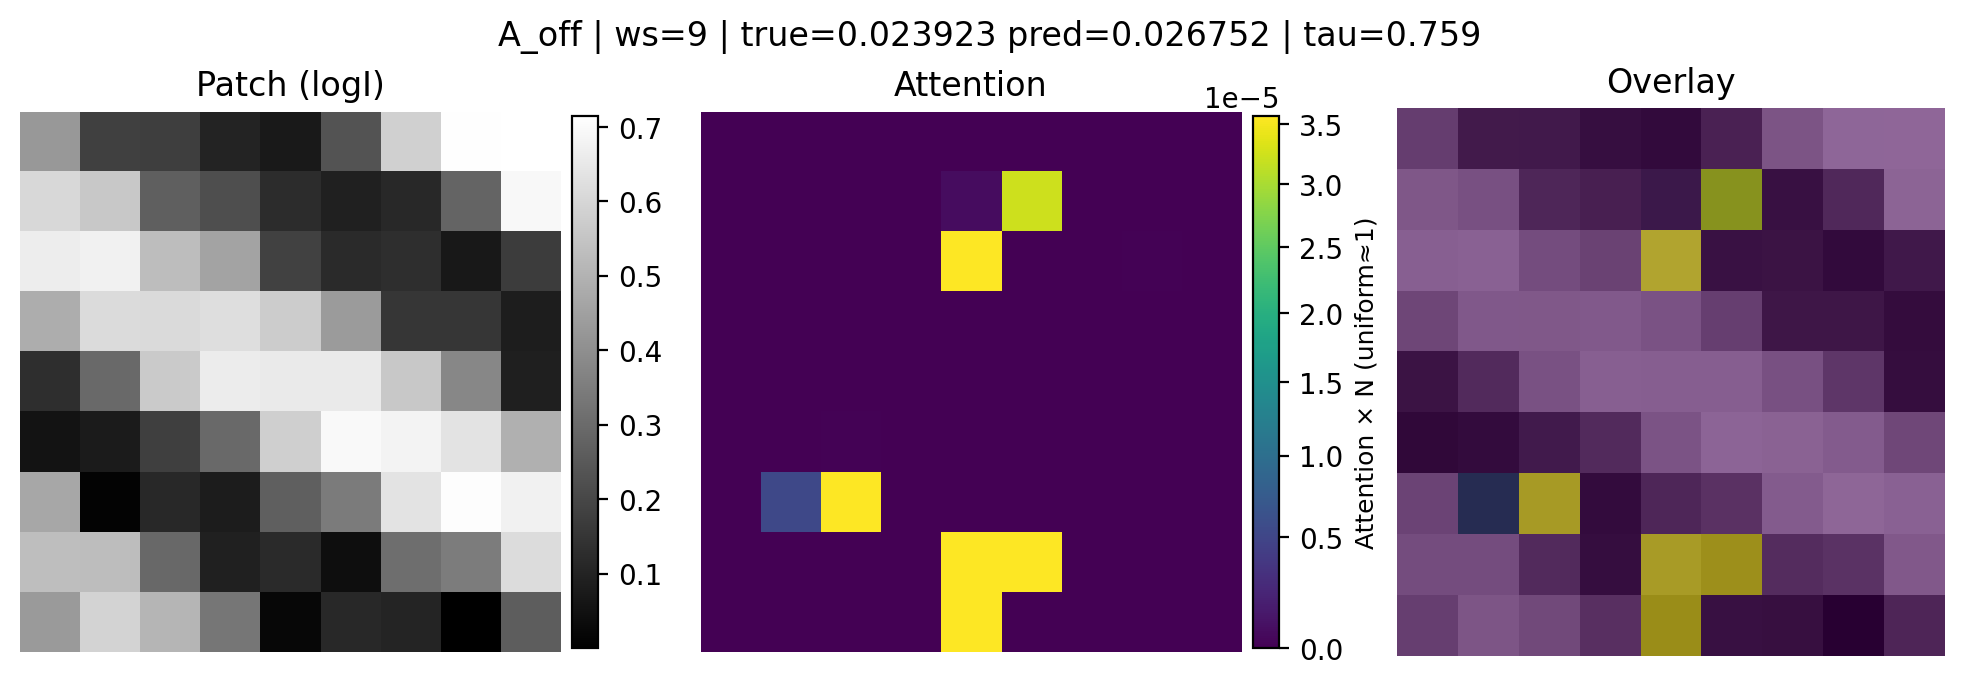

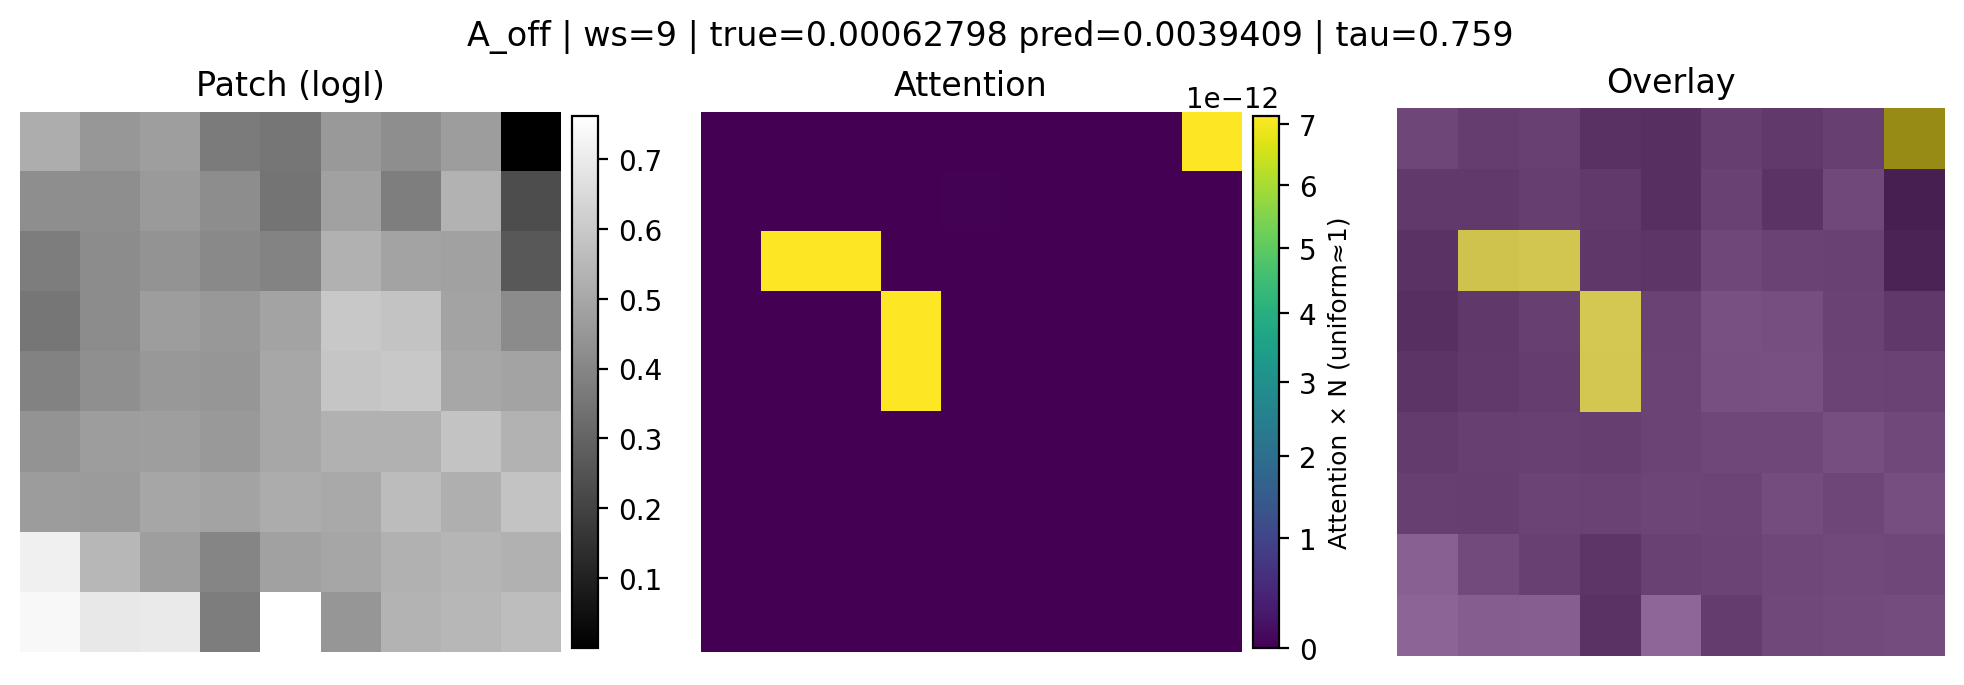

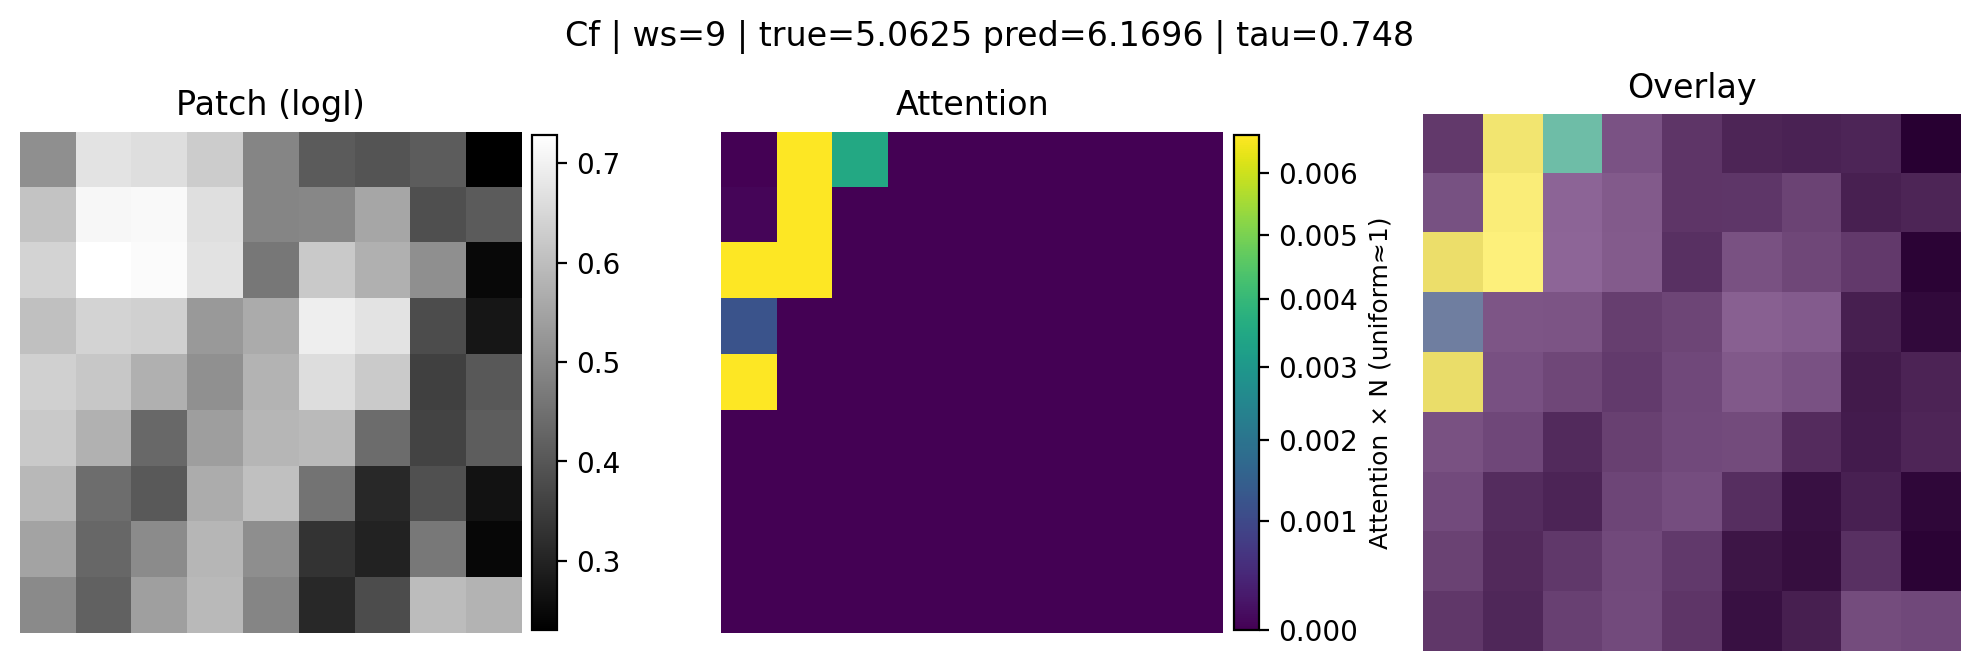

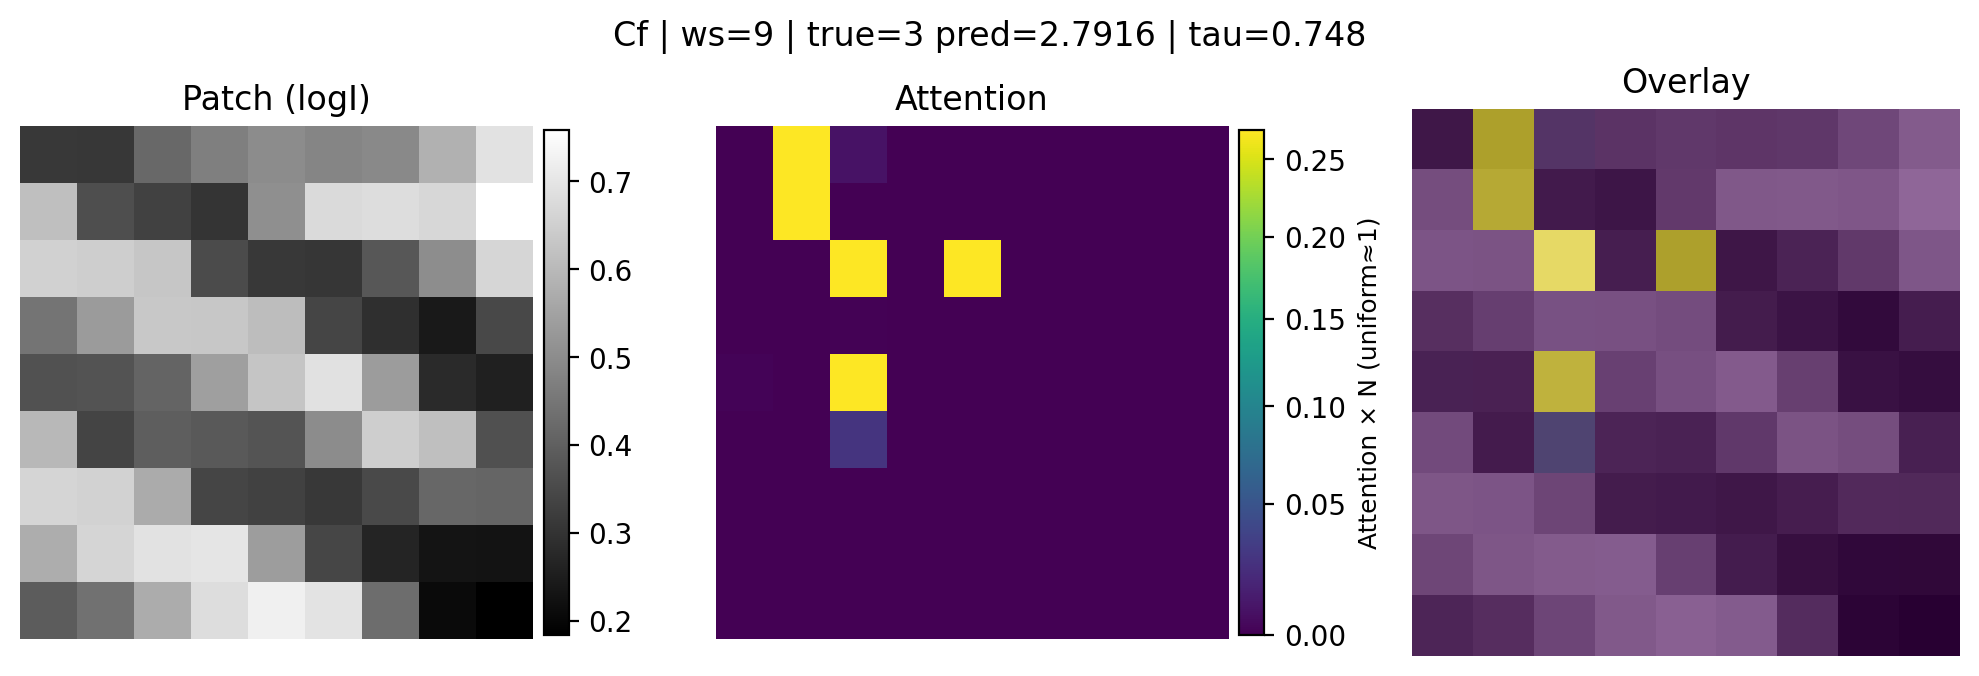

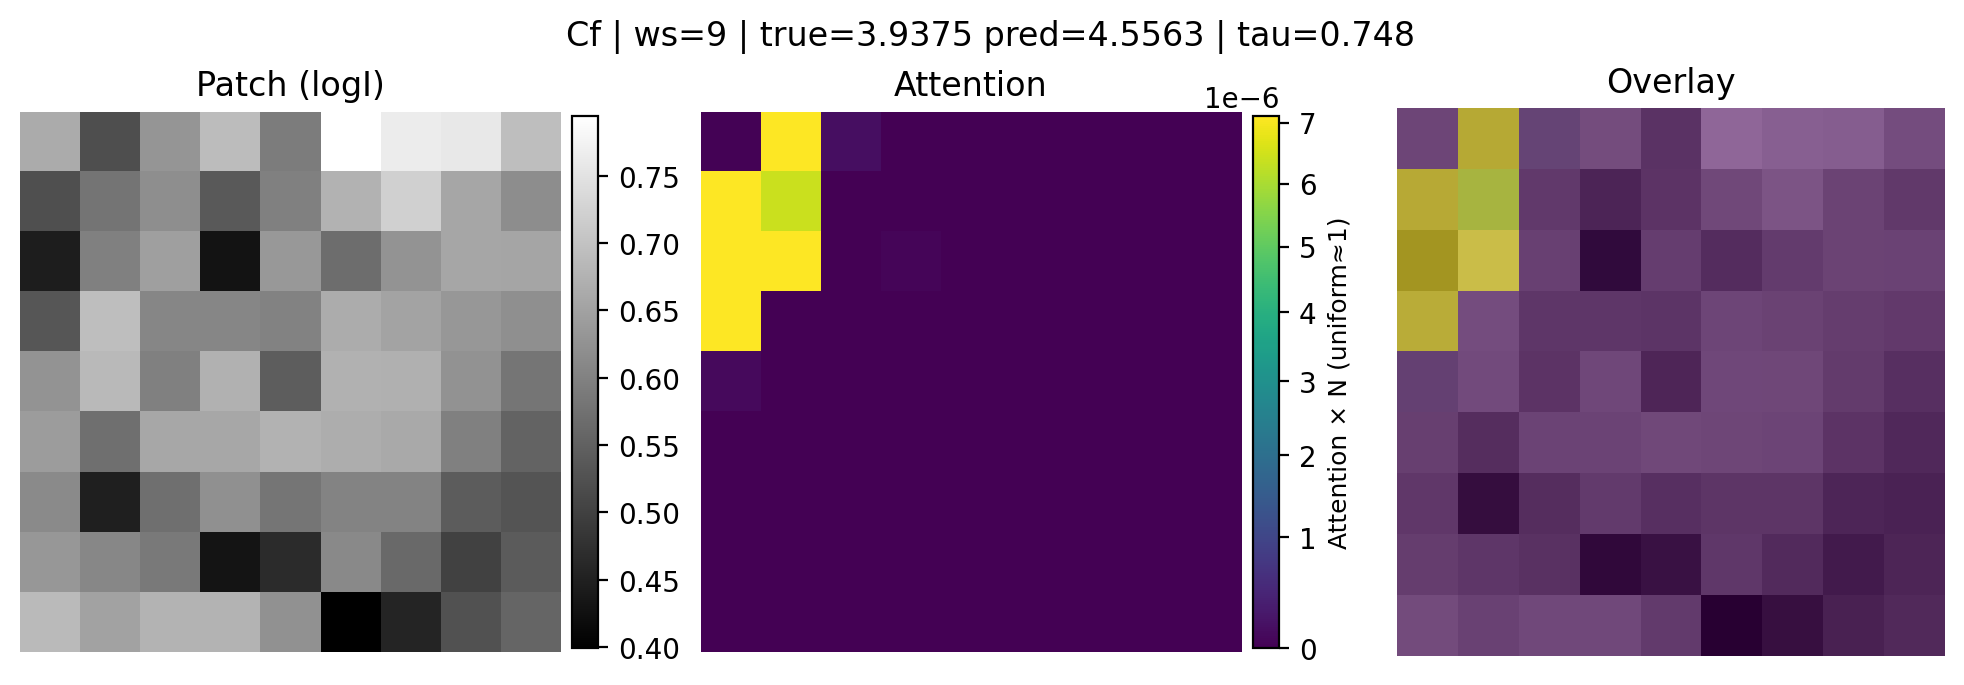

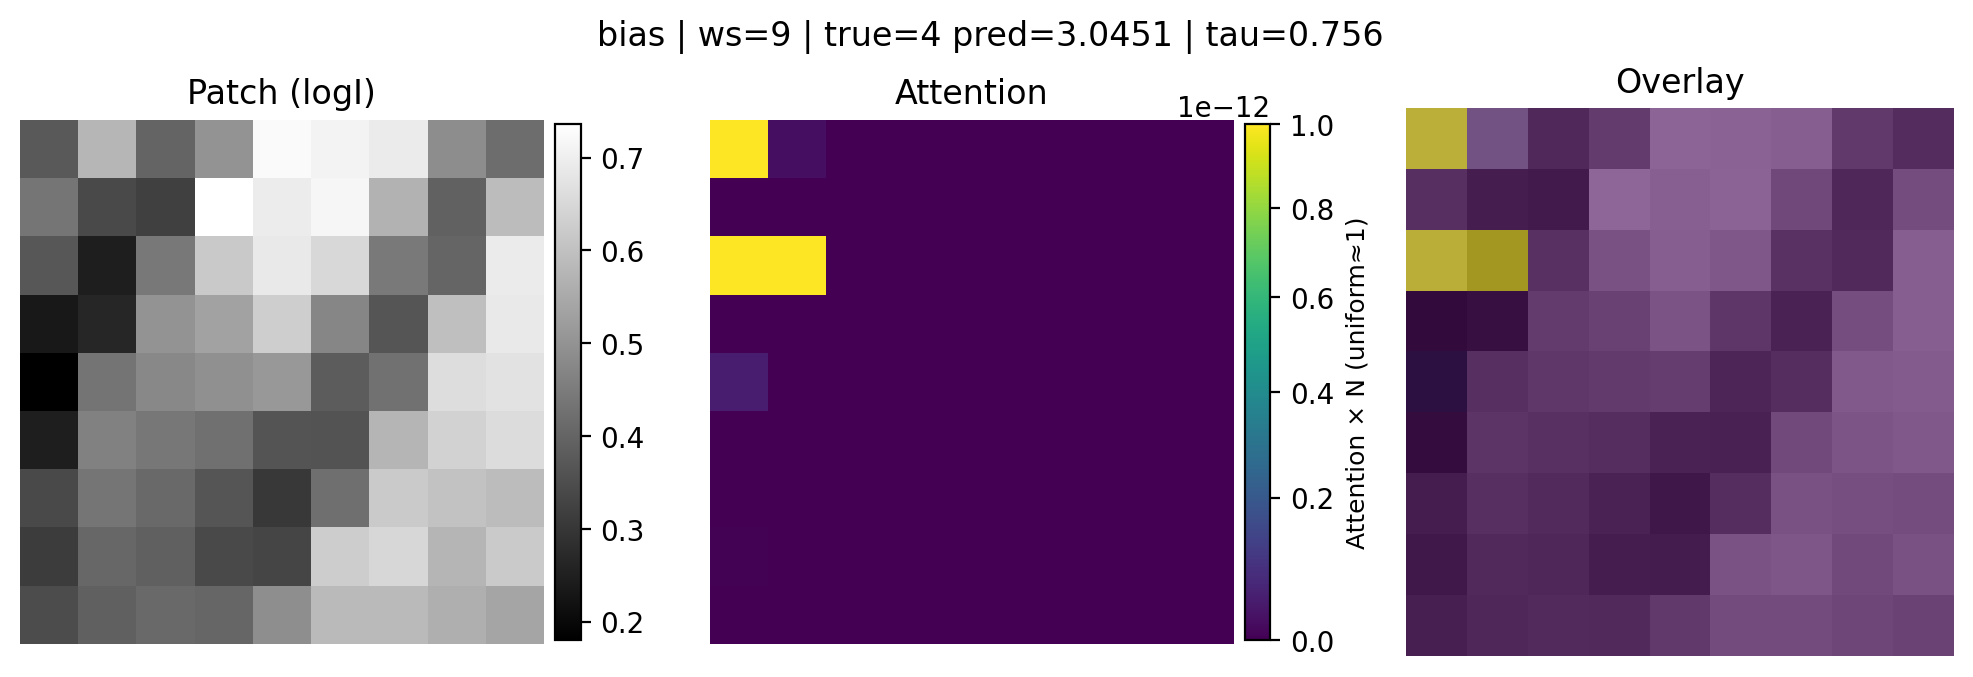

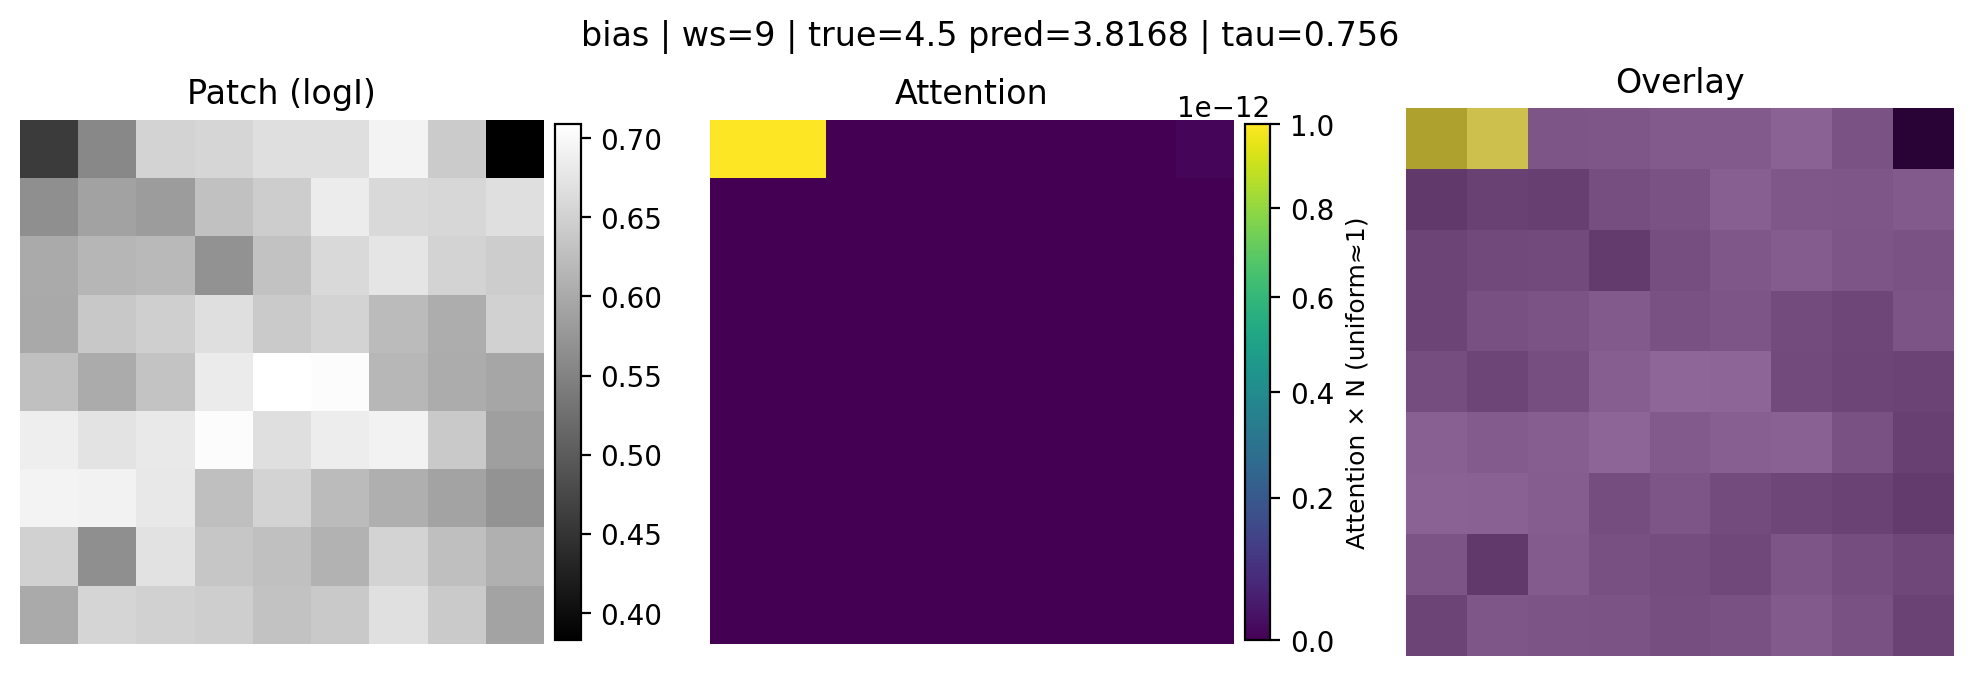

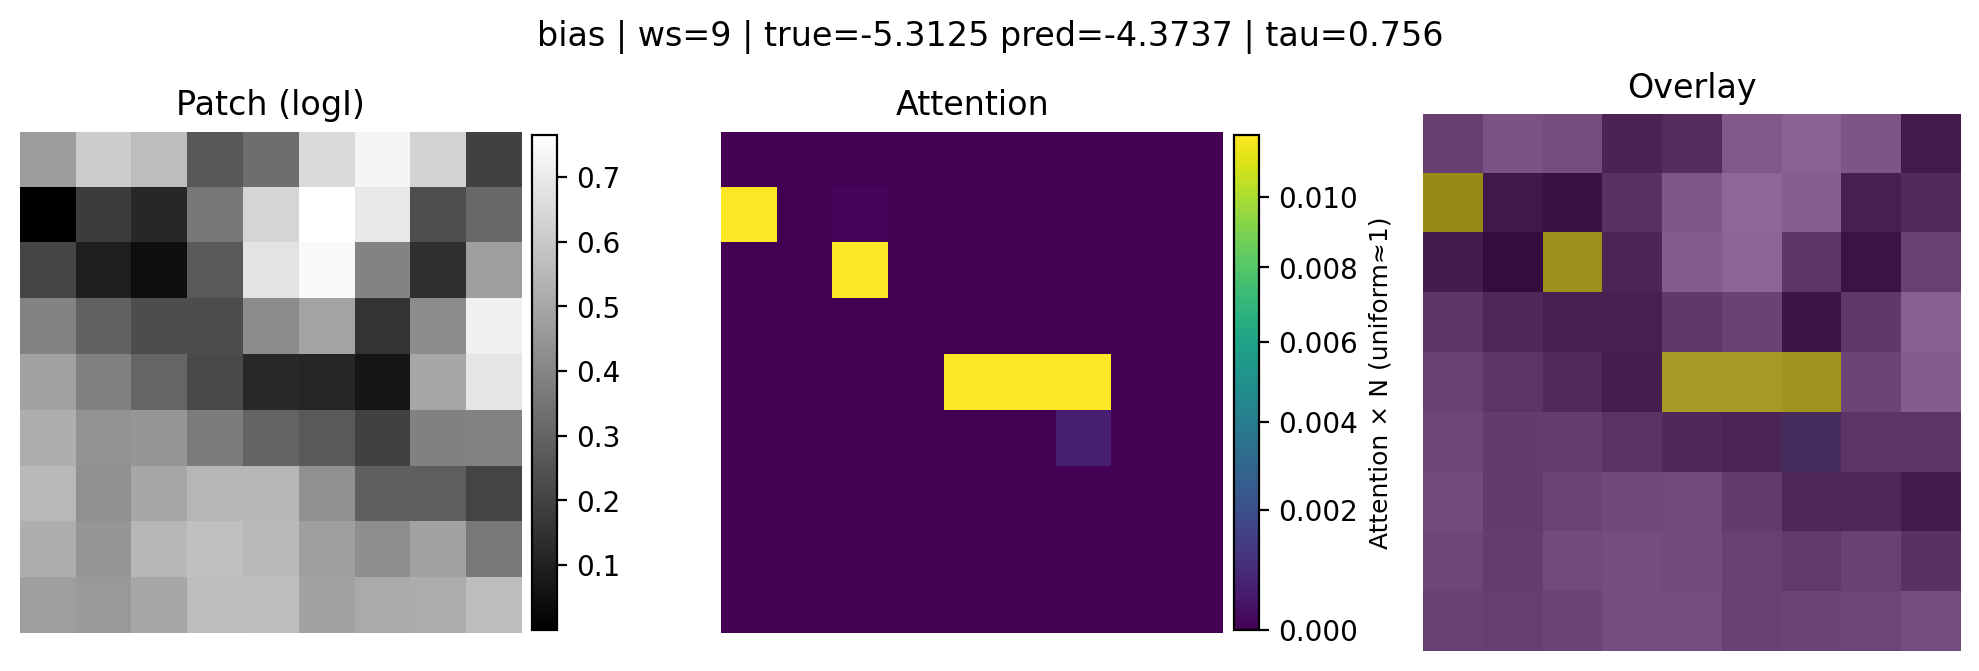

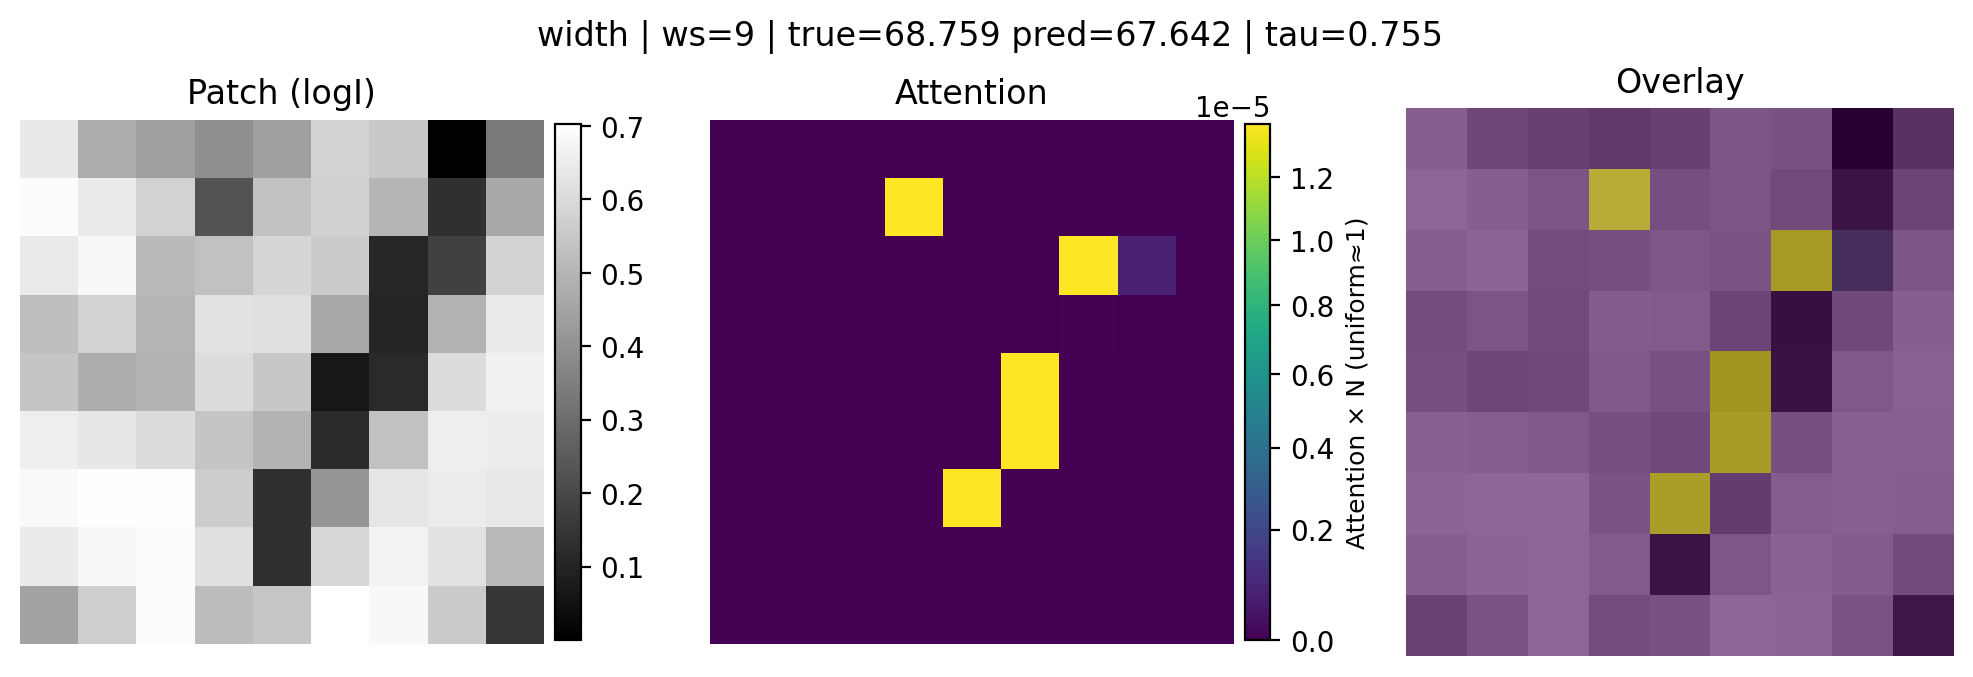

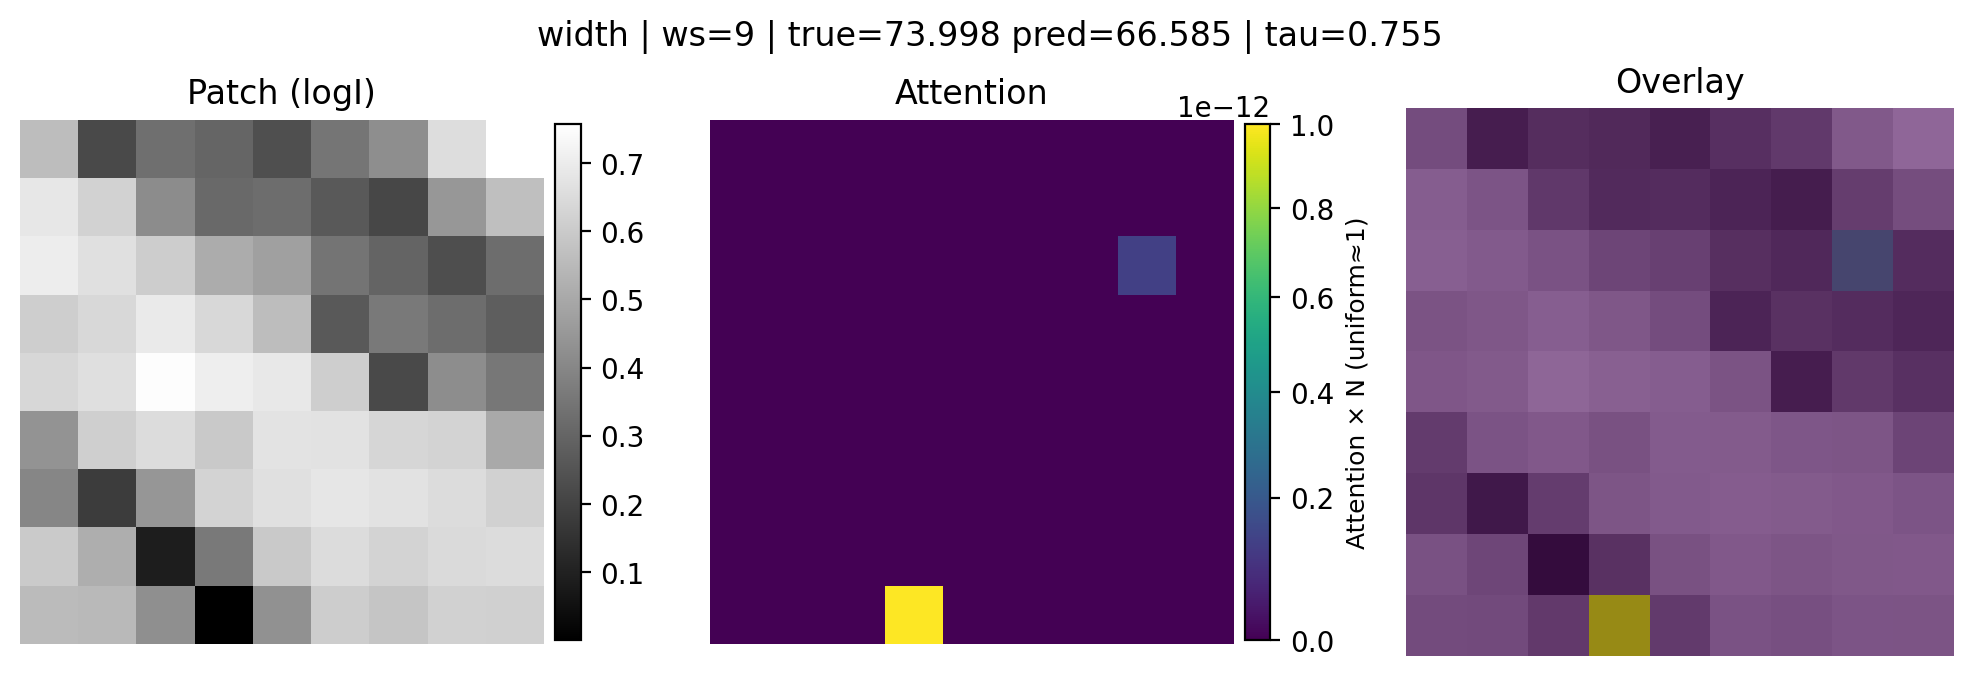

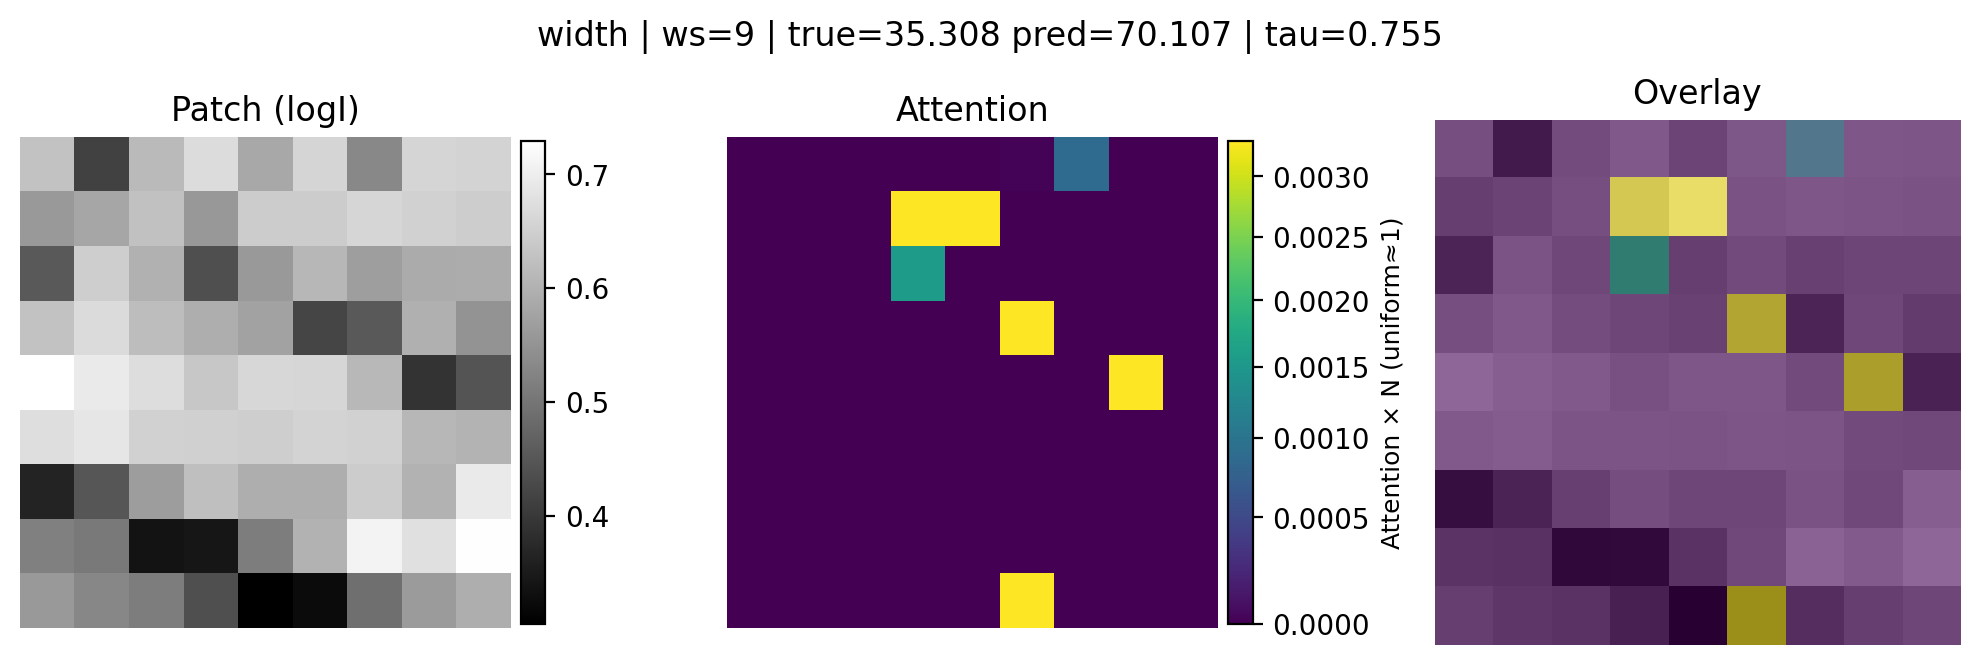

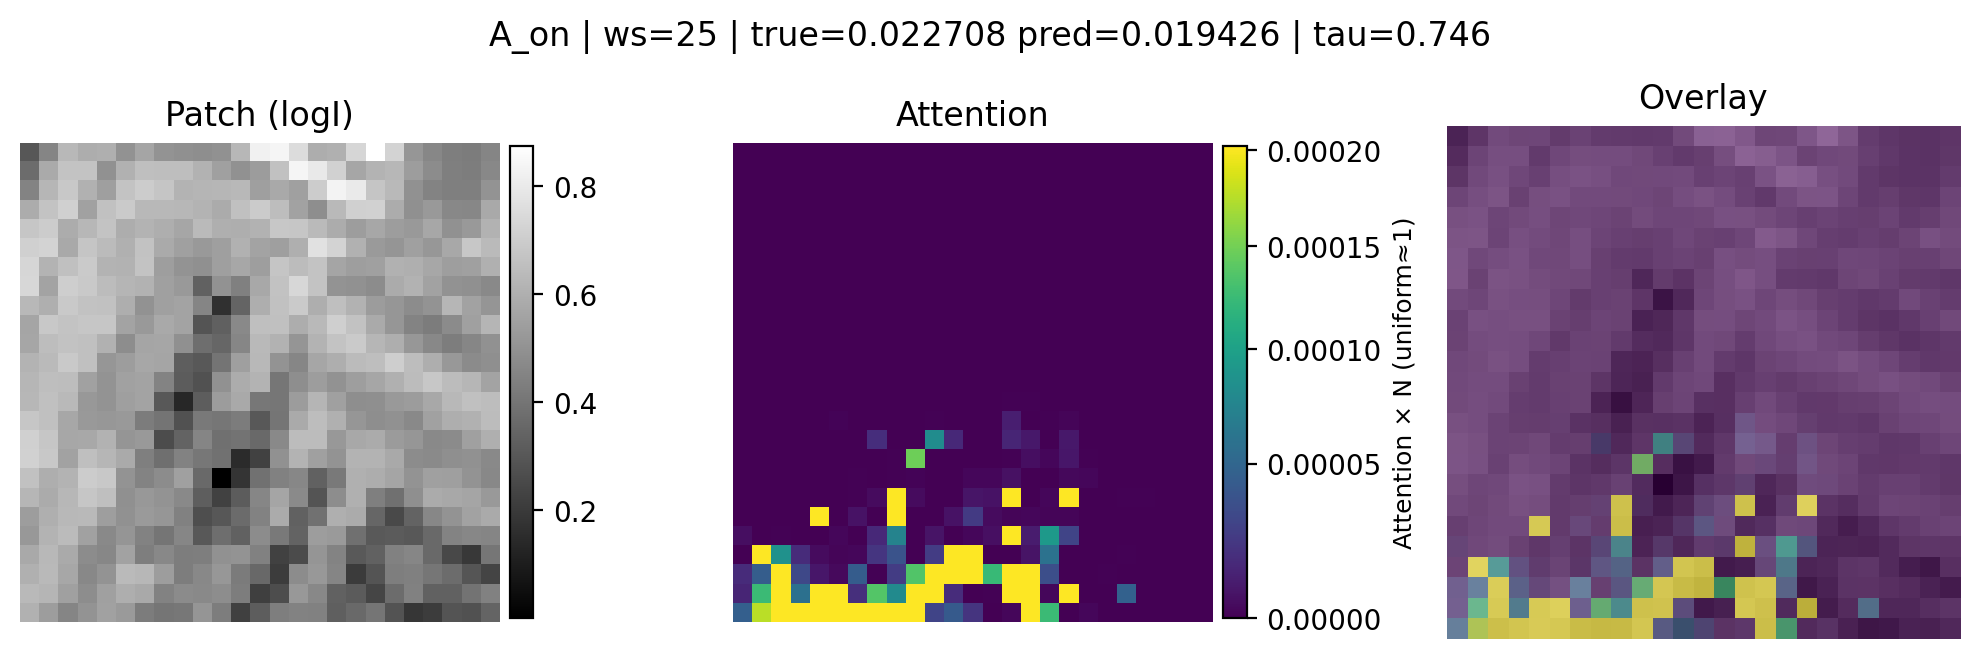

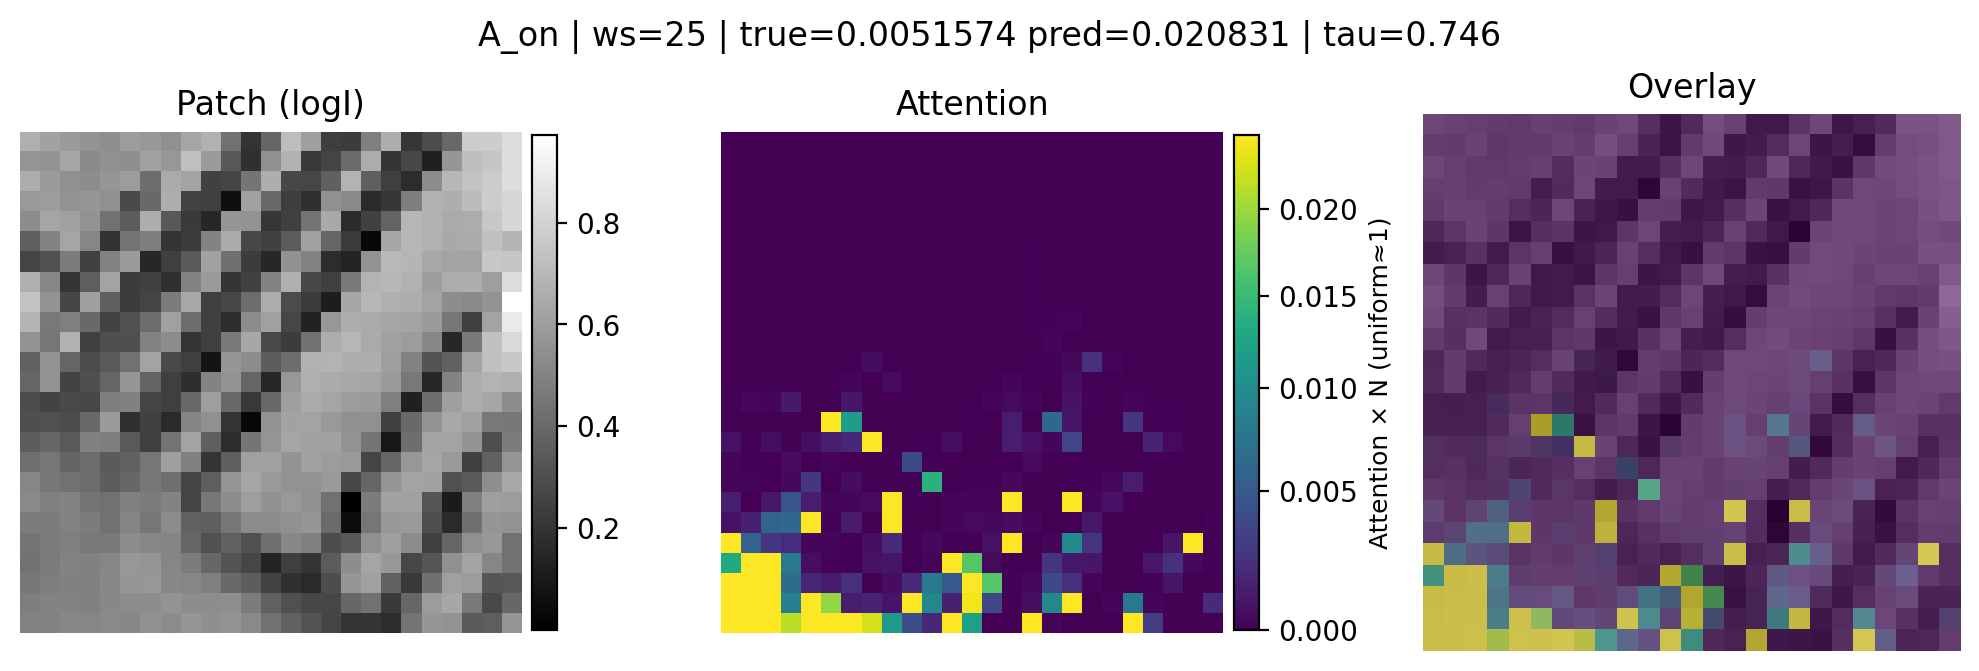

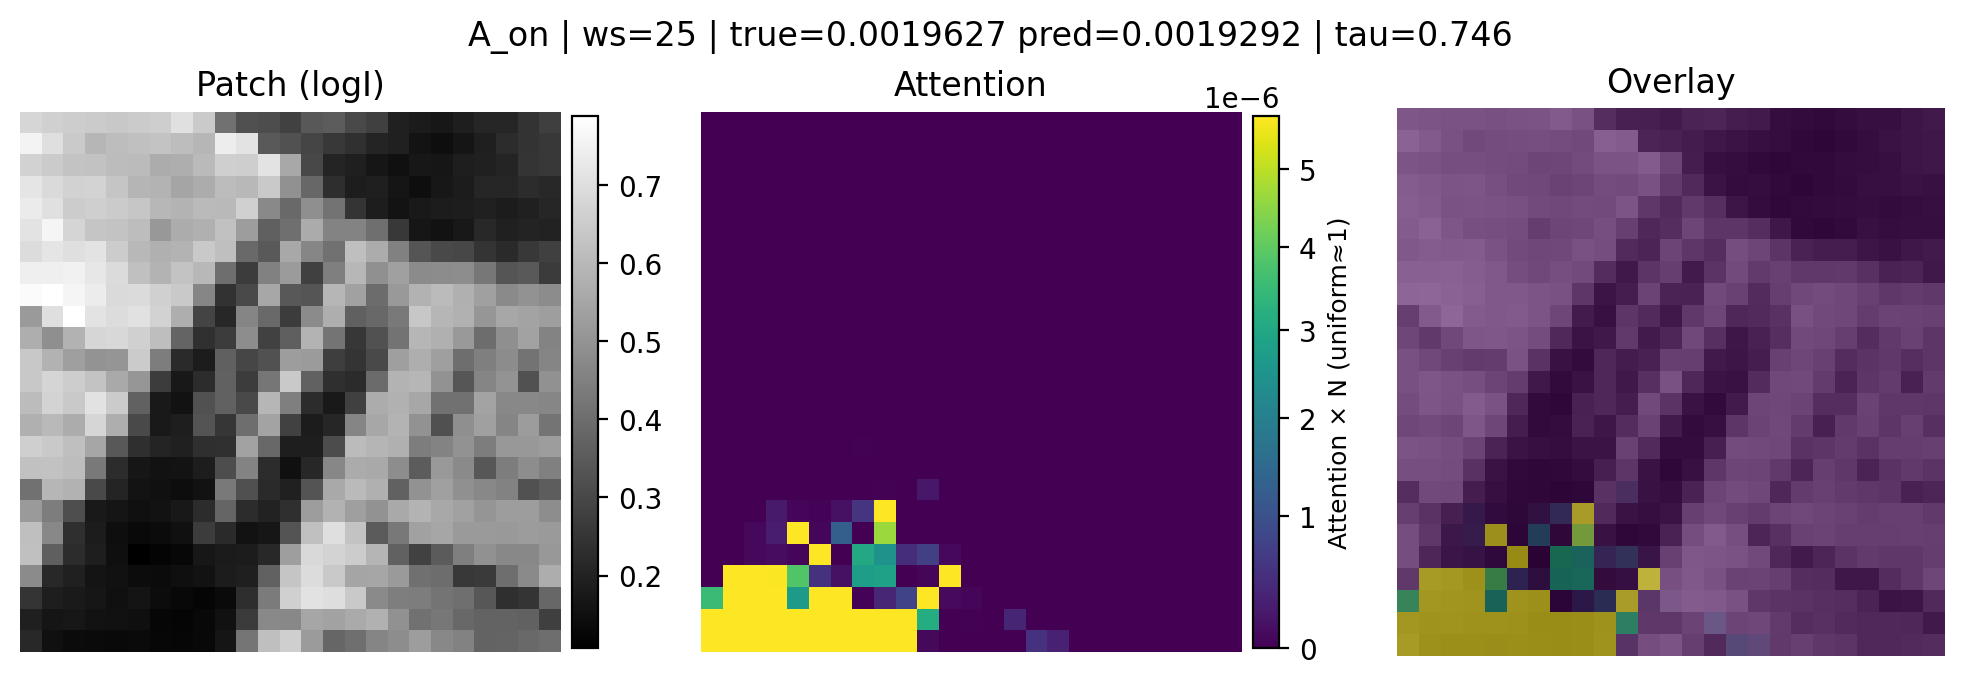

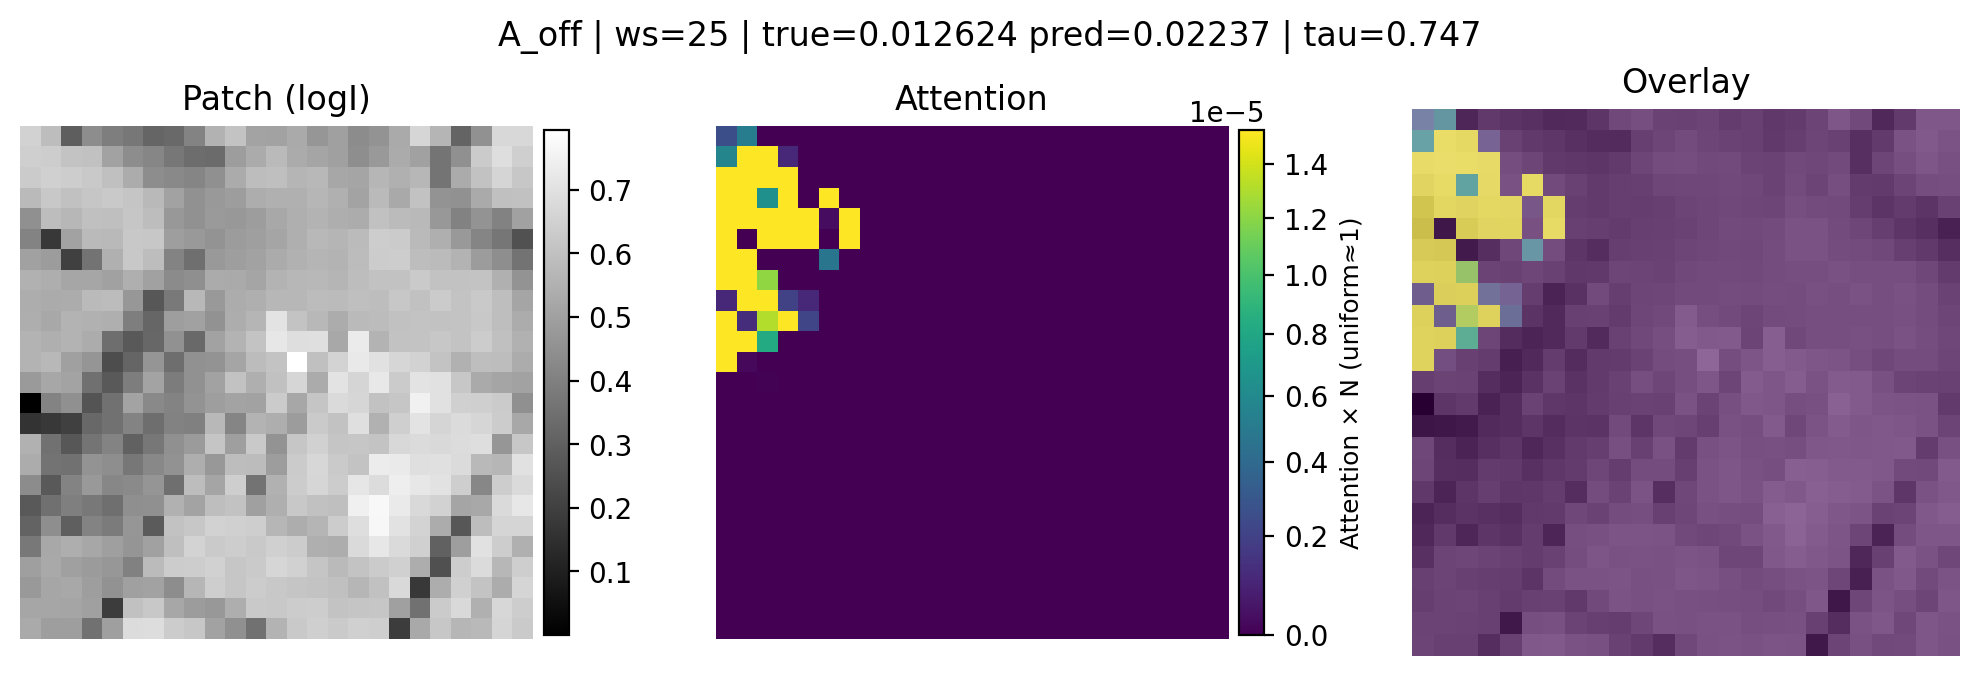

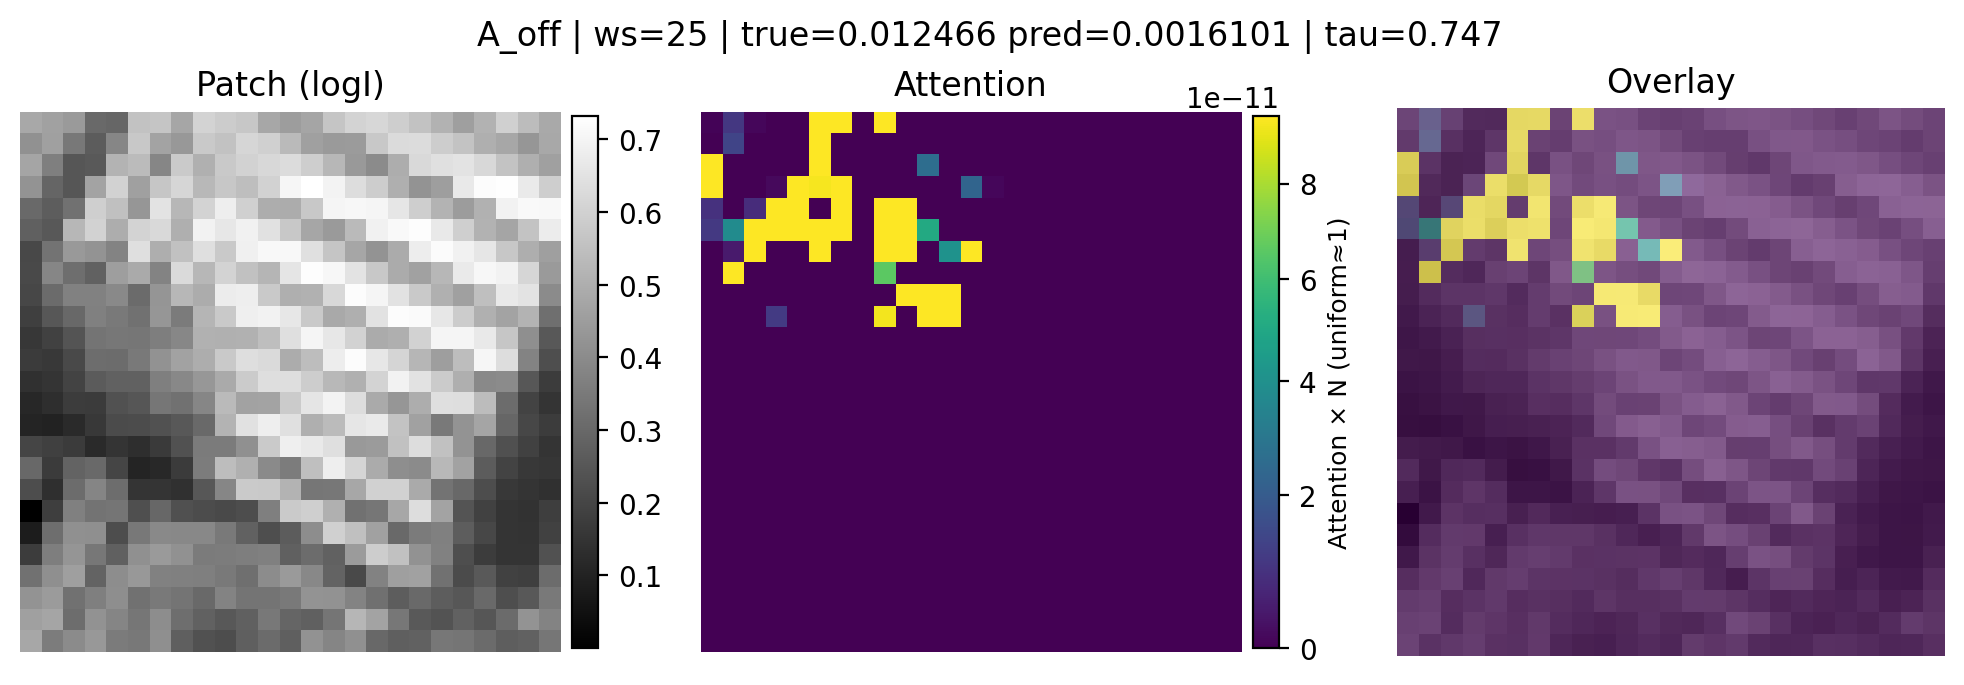

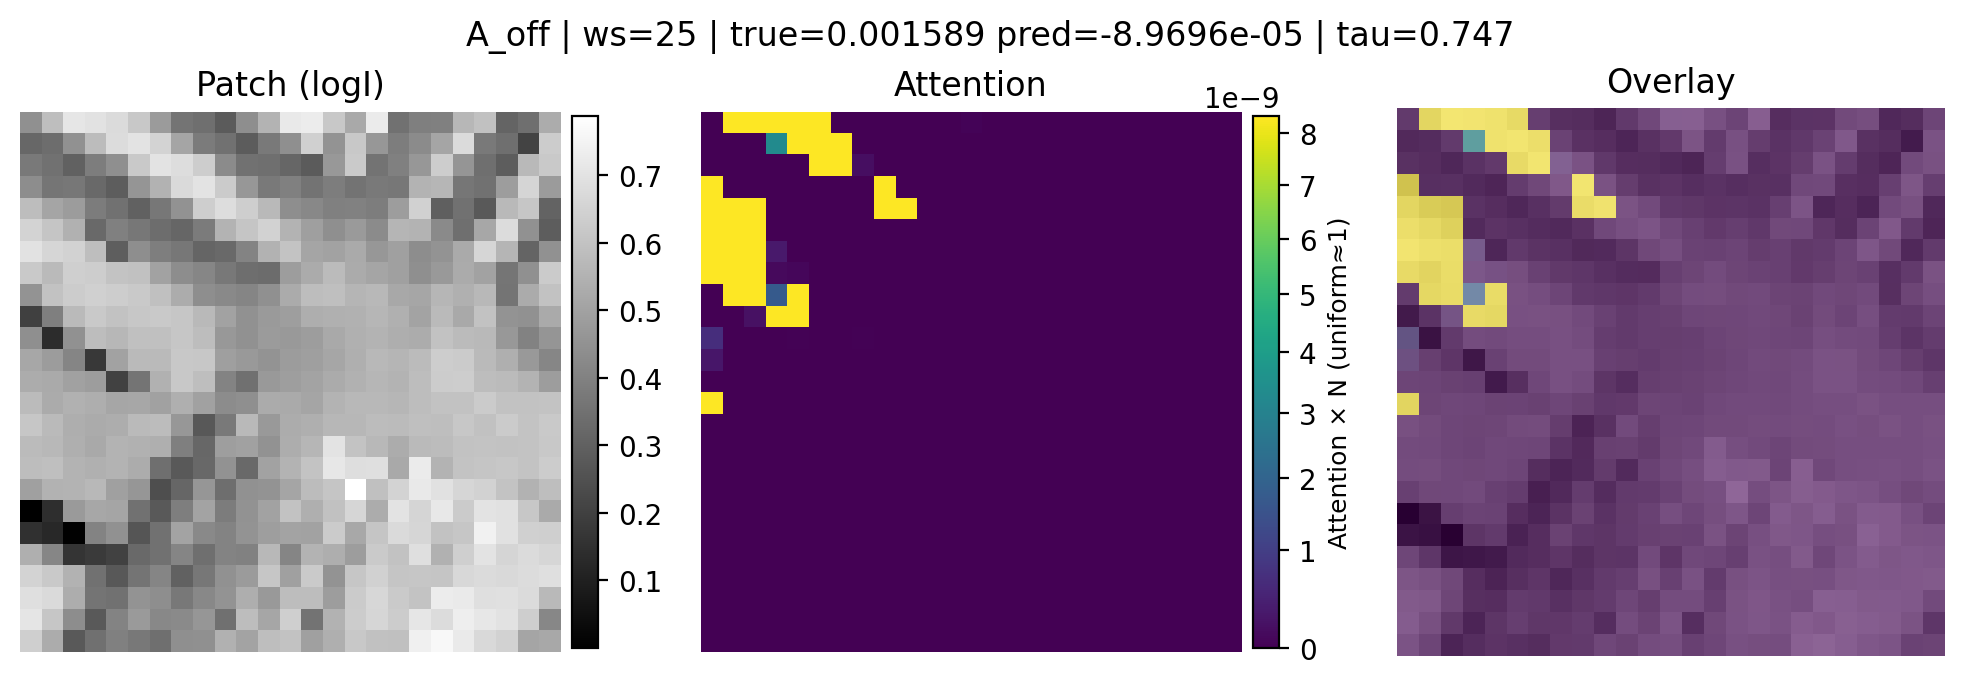

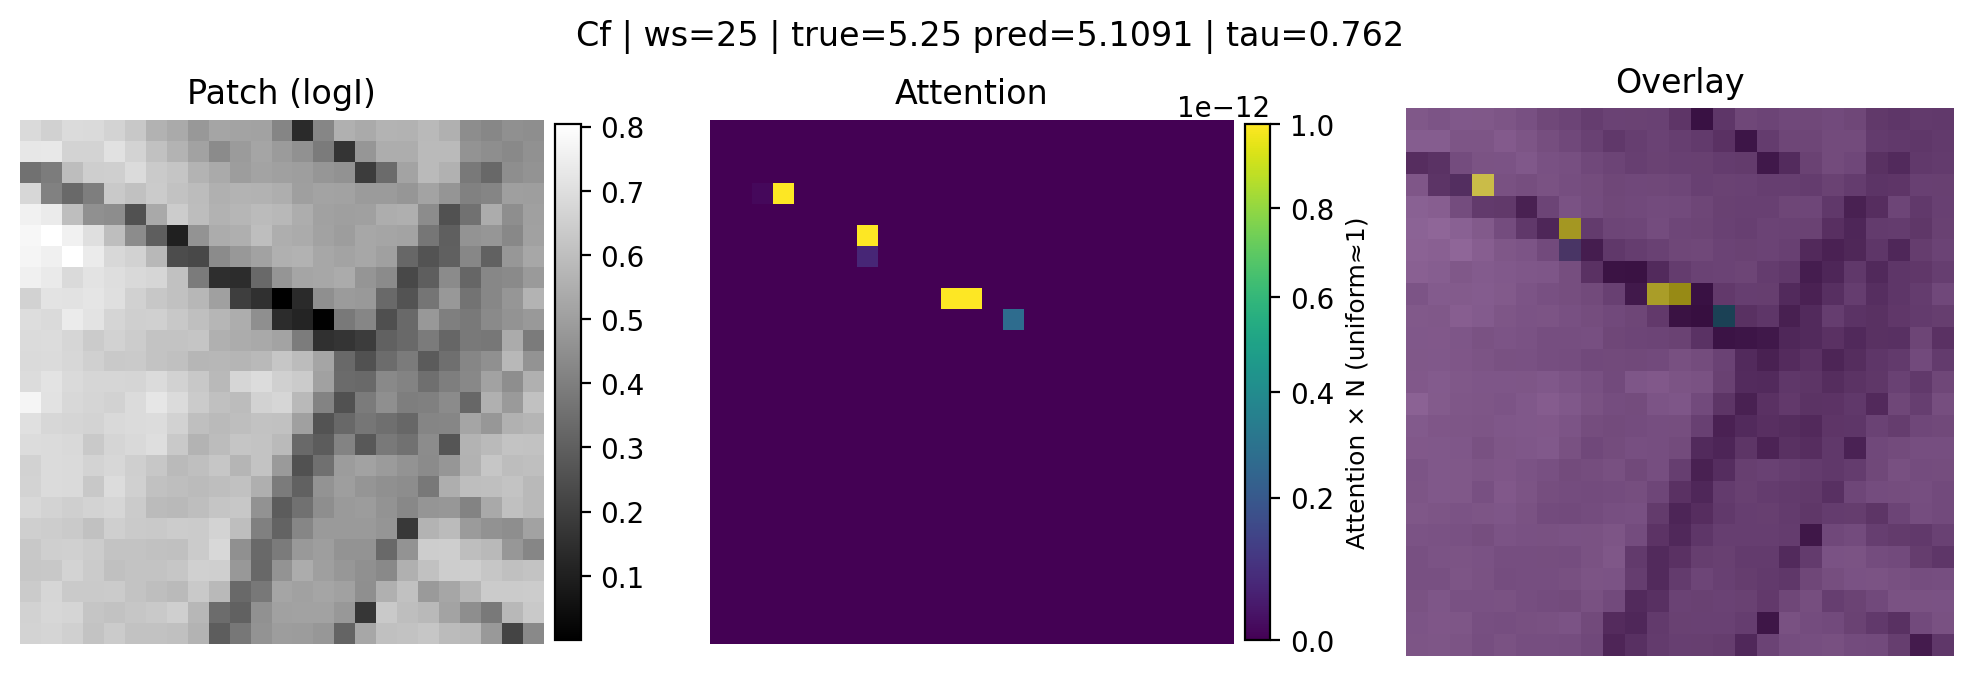

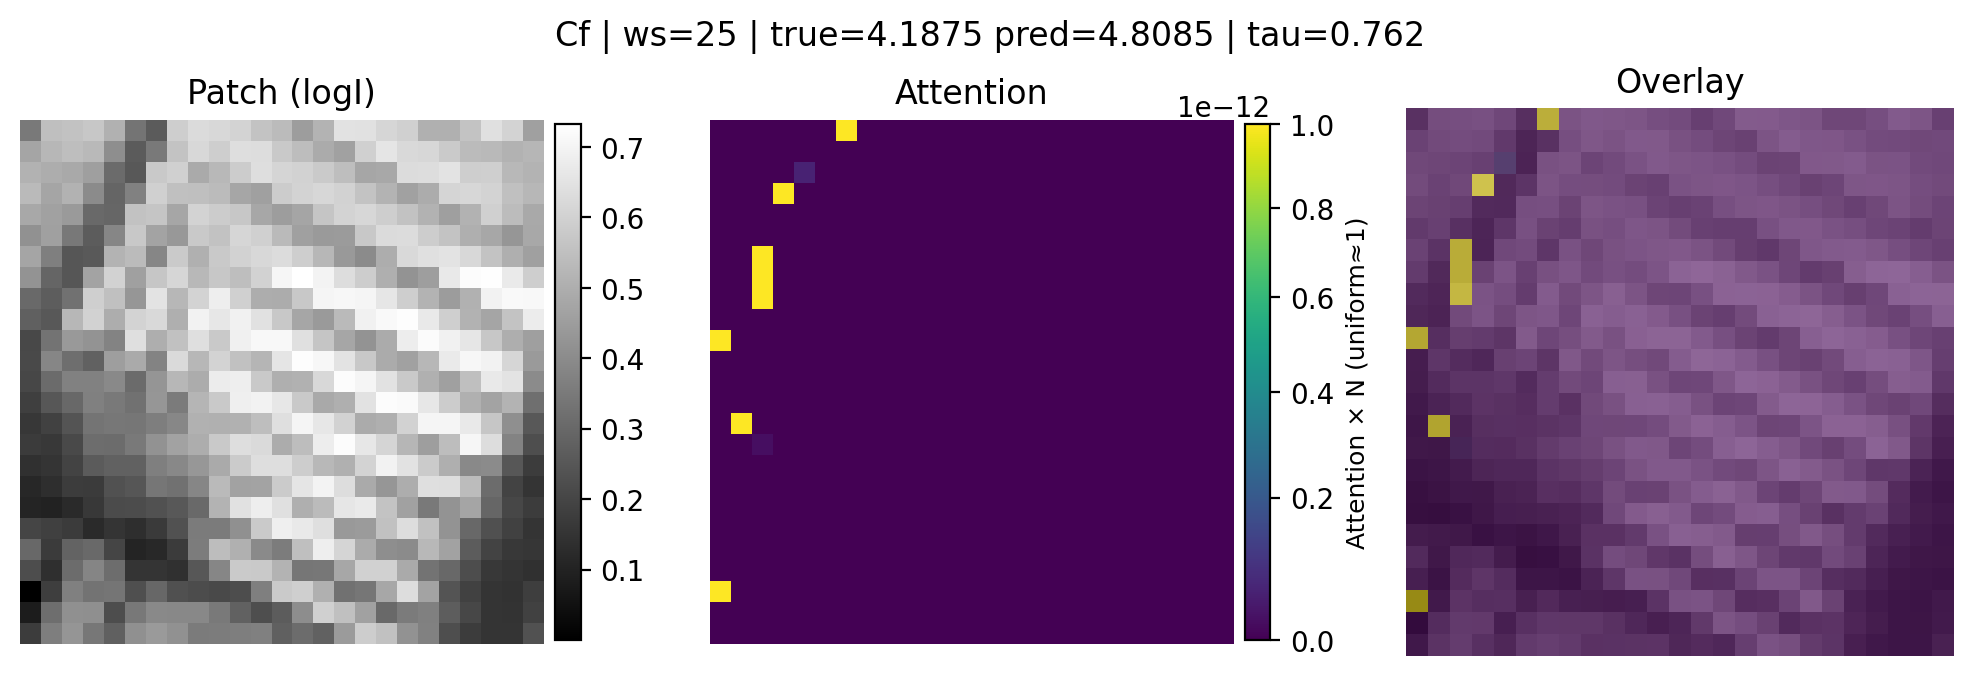

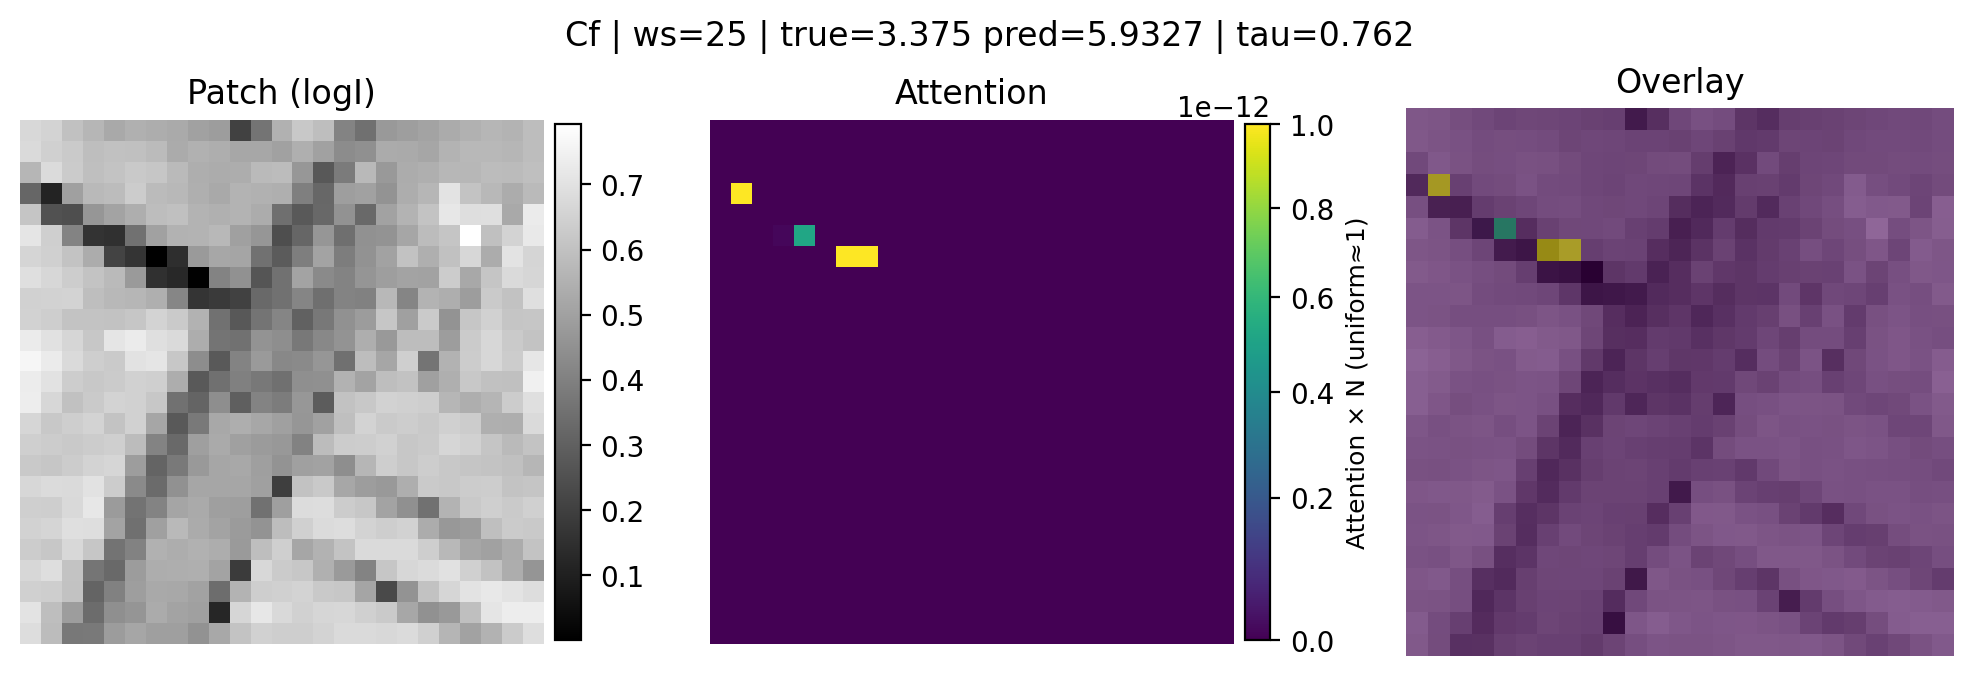

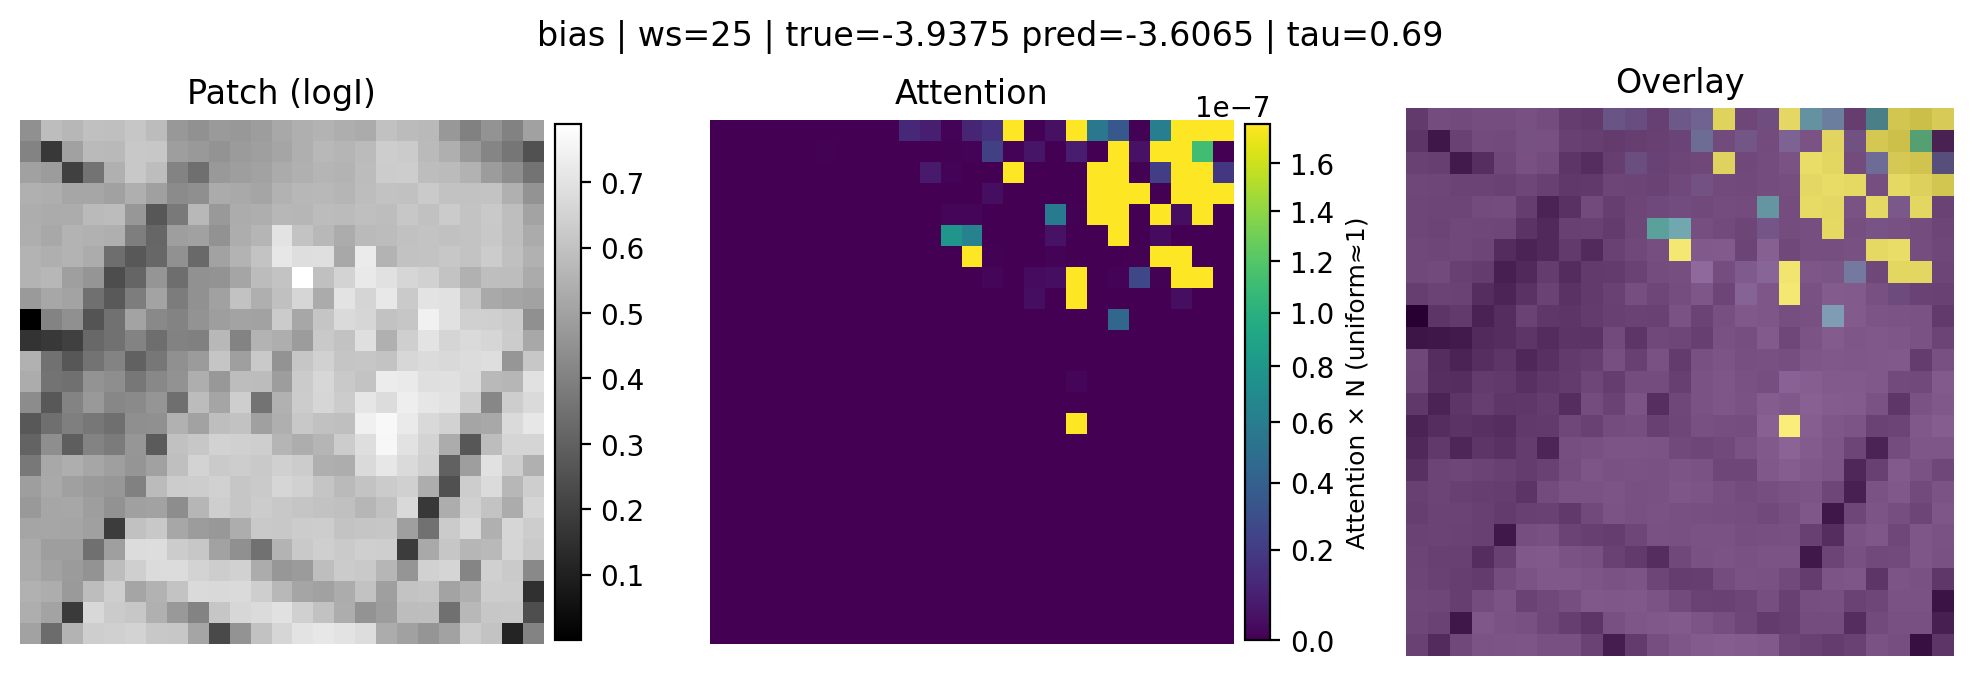

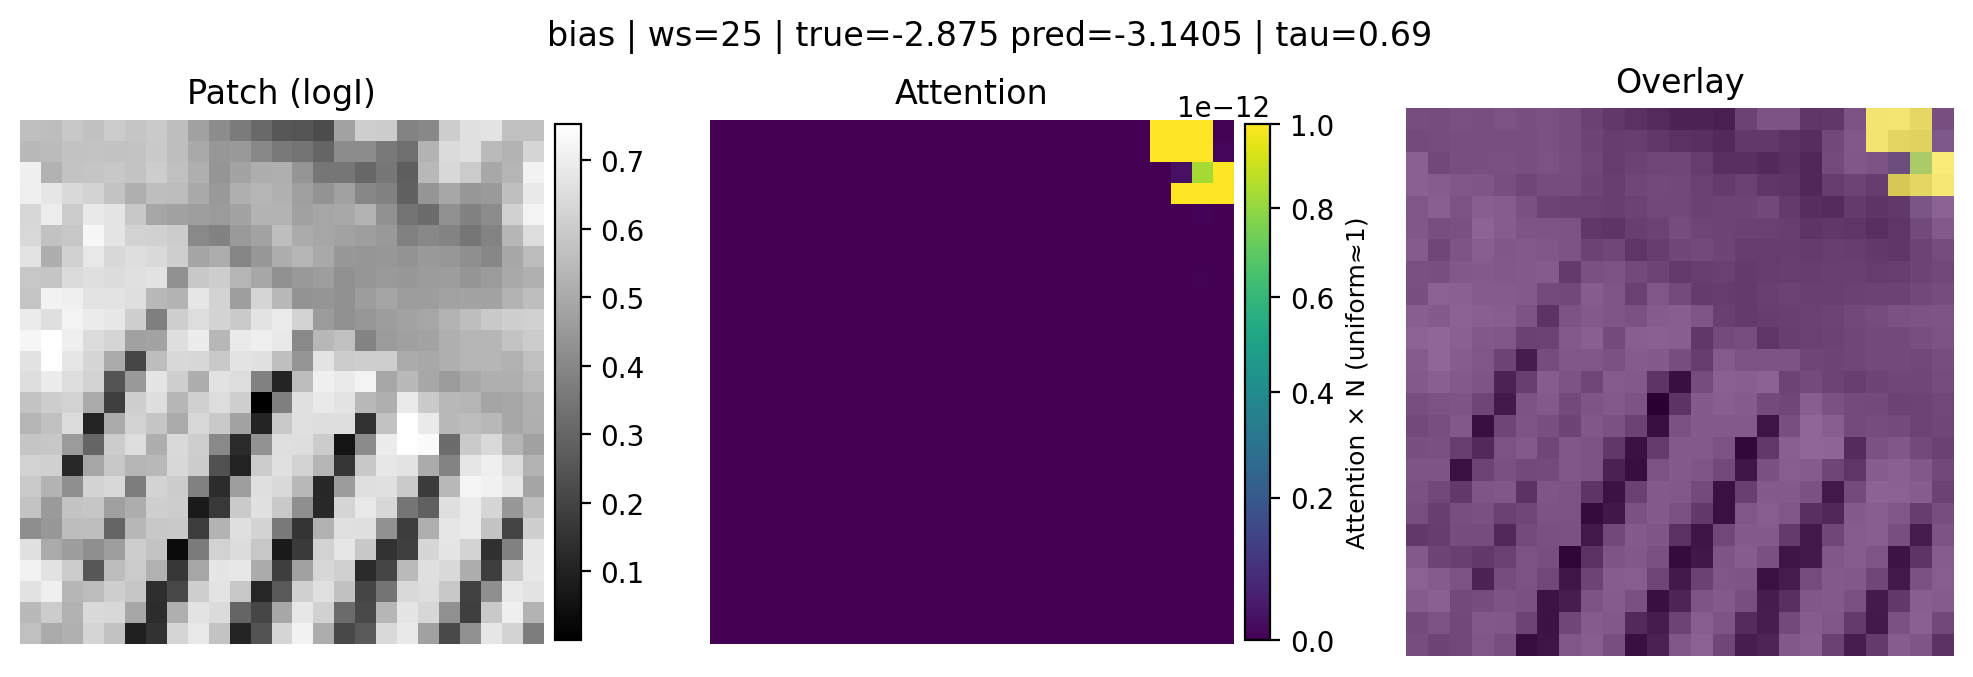

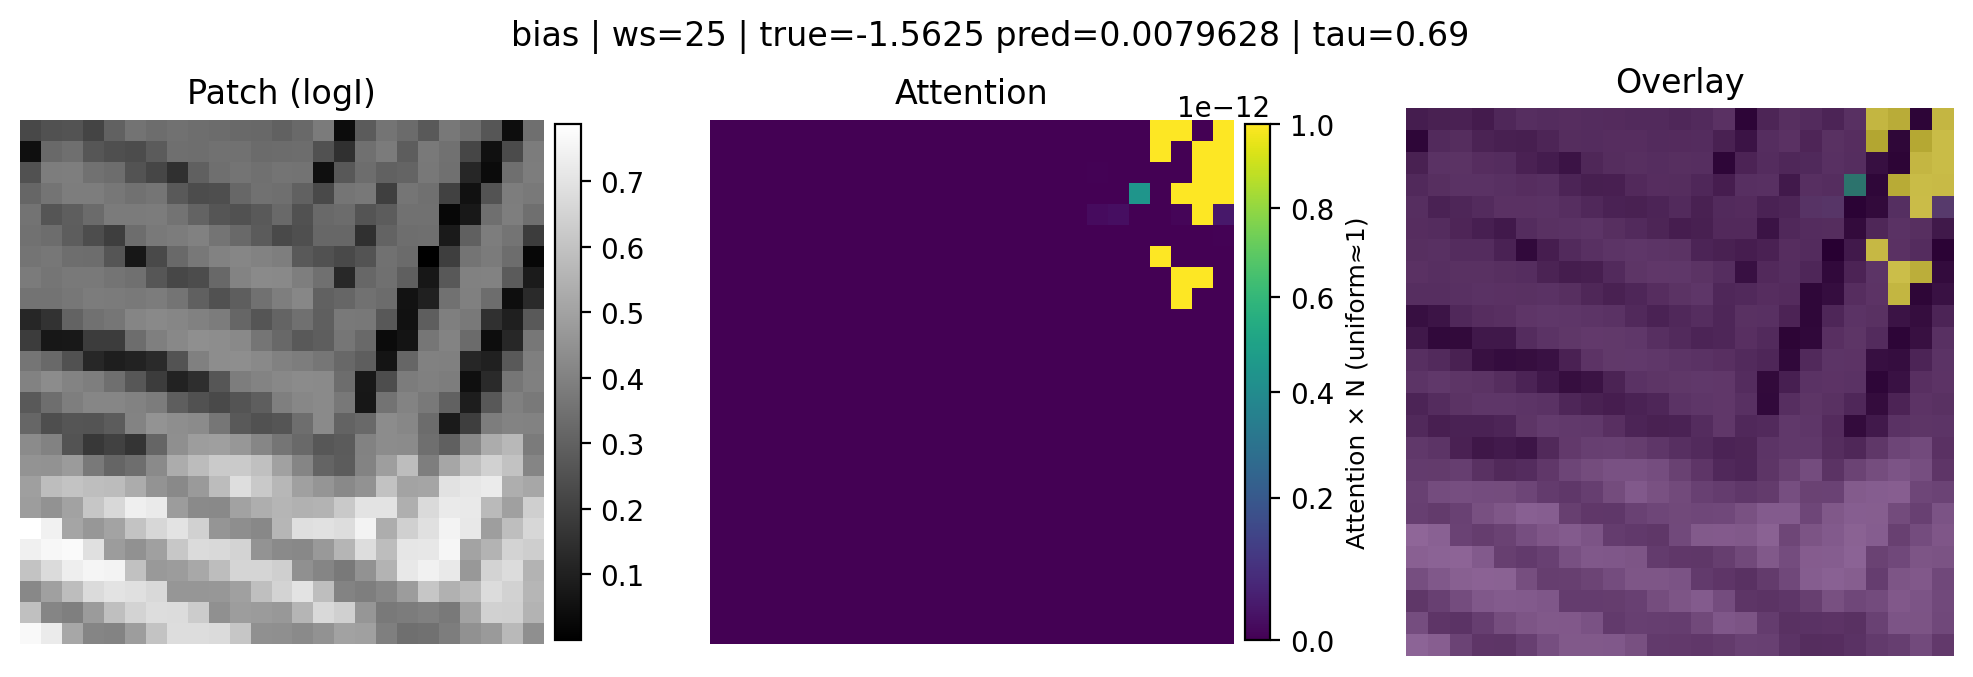

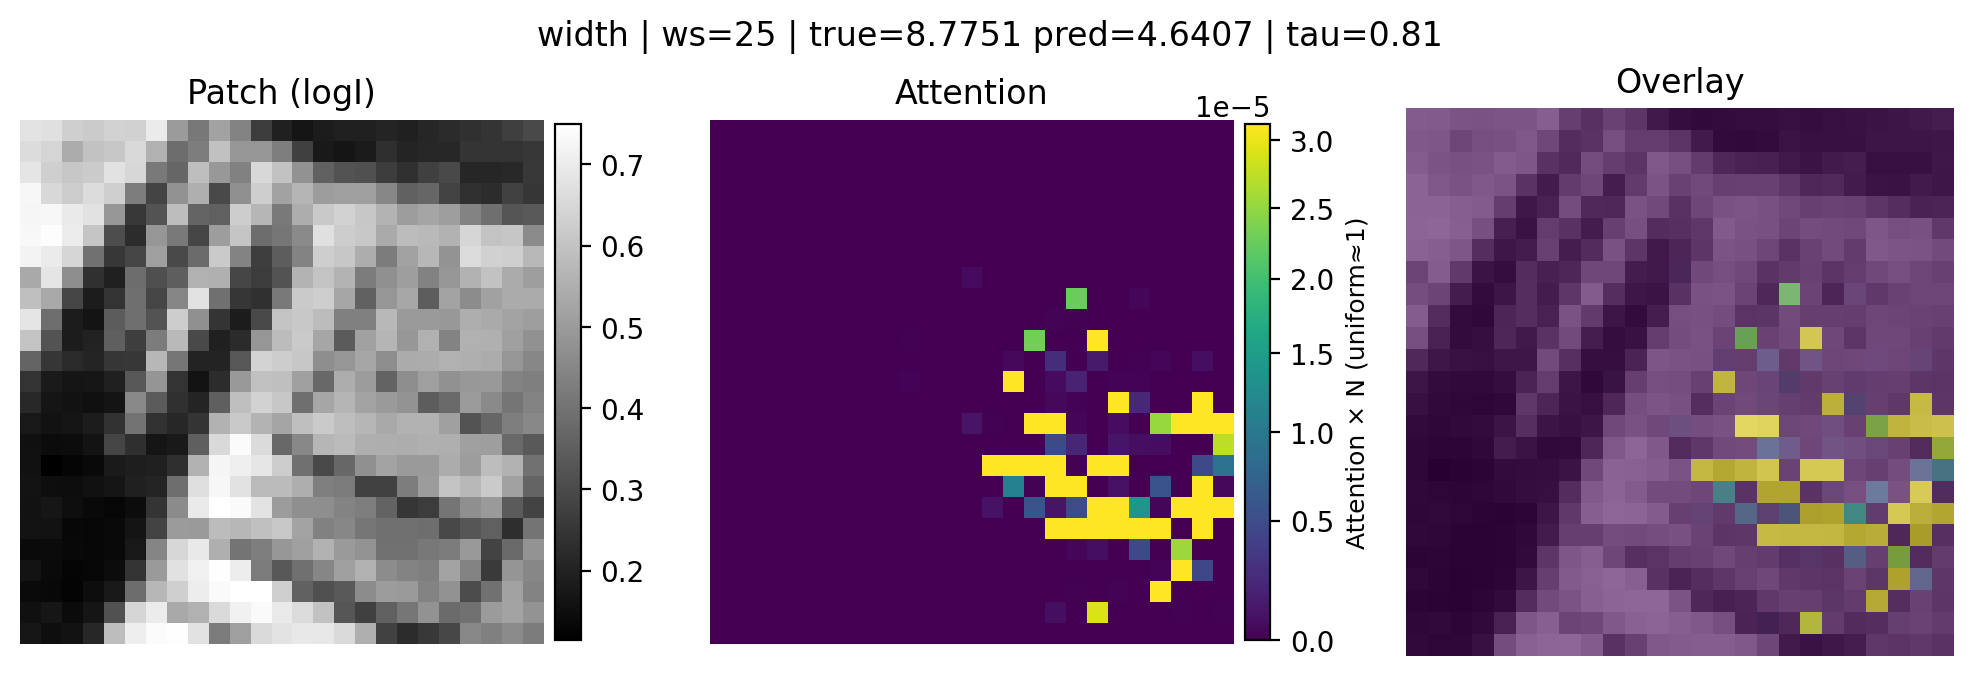

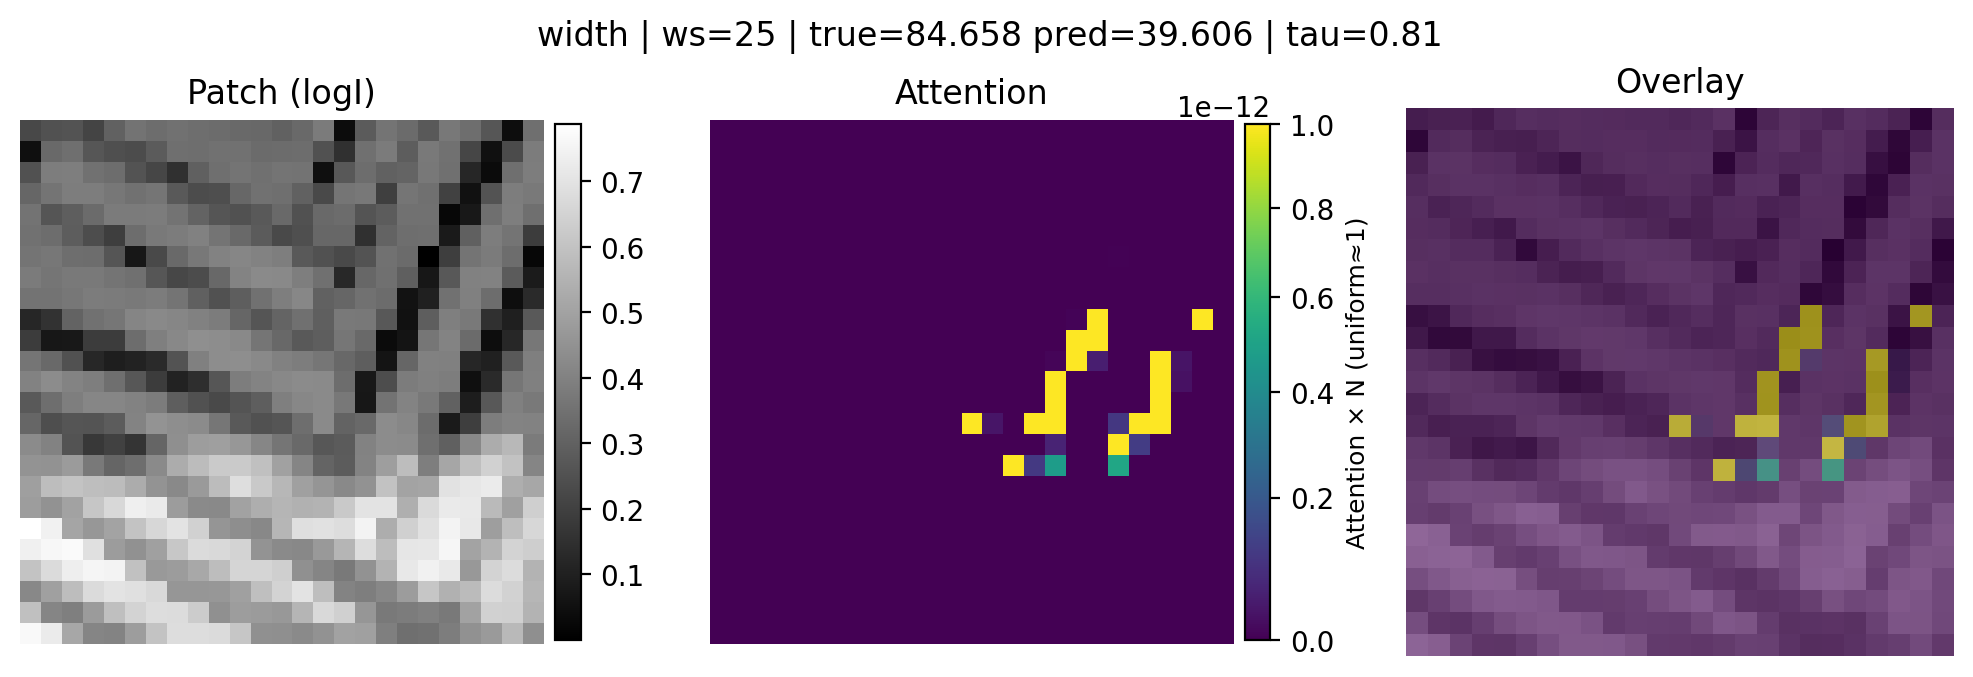

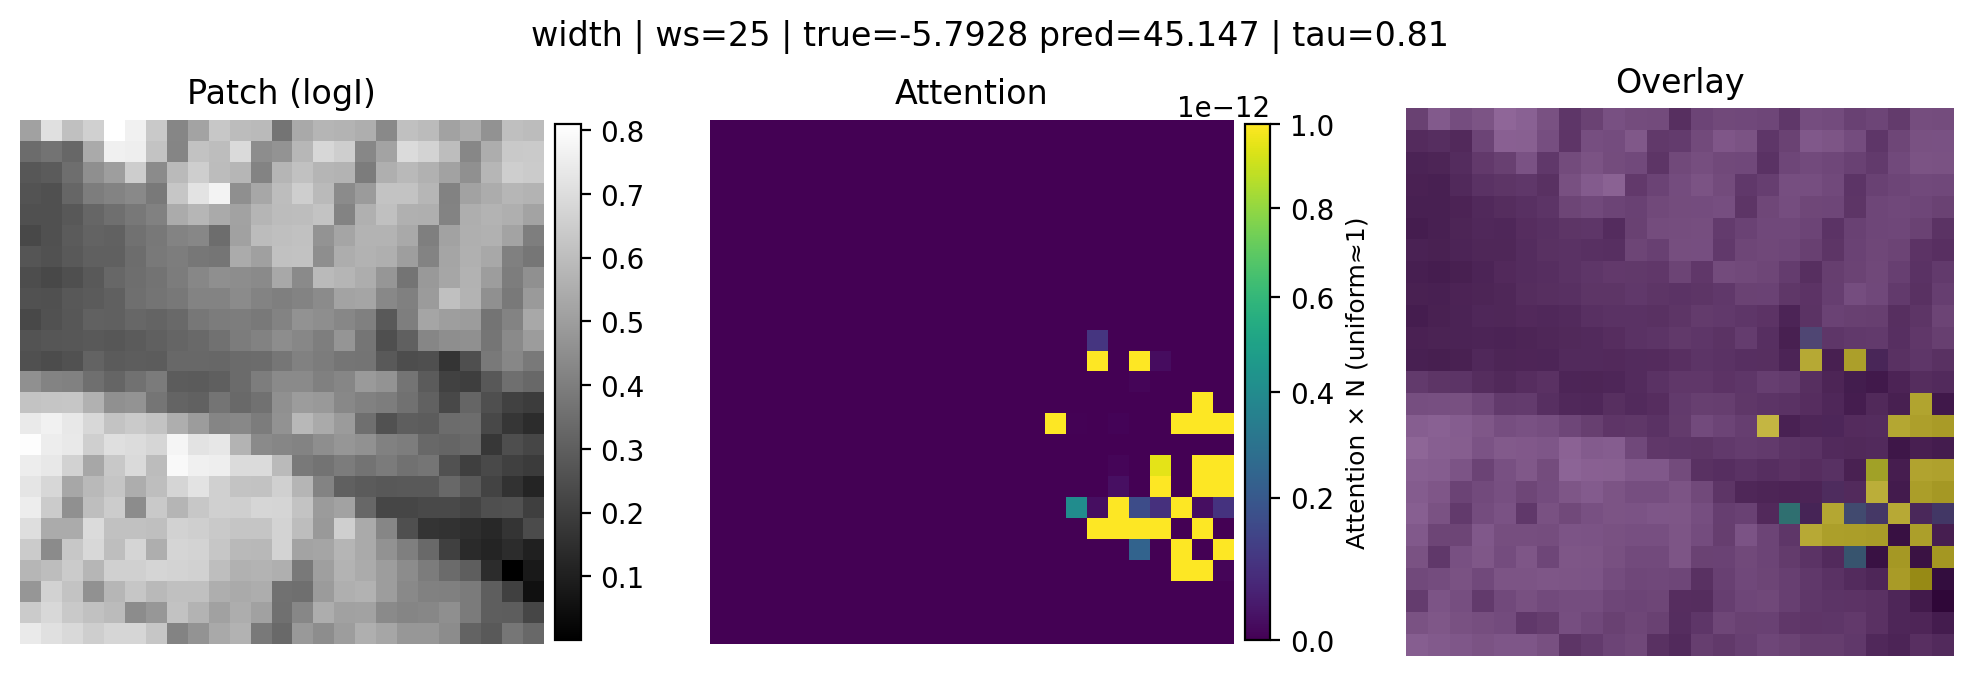

In [22]:
from matplotlib.colors import PowerNorm
import numpy as np
import matplotlib.pyplot as plt


def tokens_to_patch_logI(X_tok_row, ws):
    return X_tok_row[:, 0].reshape(ws, ws)


def overlay_attention_on_patch(
    patch,
    att_map,
    title="",
    ws=None,
    gamma_att=0.6,        # less aggressive than 0.35; try 0.6–0.8
    clip_pct_att=99.5,
    show_relative=True,   # IMPORTANT: makes range meaningful
    cmap_patch="gray",
    cmap_att="viridis",
    overlay_alpha=0.6
):
    patch = np.asarray(patch, float)
    att_map = np.asarray(att_map, float)

    eps = 1e-12

    # ---- Patch: NO clipping / NO normalization ----
    # (imshow will autoscale from patch min/max, which is fine)

    # ---- Attention: convert to relative units so it's readable ----
    if show_relative:
        if ws is None:
            # infer ws from attention map shape if possible
            ws = att_map.shape[0]
        Ntok = ws * ws
        att_show = att_map * Ntok   # uniform attention -> ~1 everywhere
        att_label = r"Attention × N (uniform≈1)"
    else:
        att_show = att_map
        att_label = "Attention probability"

    # Robust vmax from percentile (prevents a few hot pixels from crushing contrast)
    vmax = np.percentile(att_show, clip_pct_att)
    vmax = max(vmax, eps)

    # Gamma scaling to lift mid/low values (applied only to attention)
    att_norm = PowerNorm(gamma=gamma_att, vmin=0.0, vmax=vmax)

    # ---- Plot ----
    plt.figure(figsize=(10, 3.4), dpi=200)

    ax = plt.subplot(1, 3, 1)
    im = ax.imshow(patch, cmap=cmap_patch)
    ax.set_title("Patch (logI)")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    ax = plt.subplot(1, 3, 2)
    im = ax.imshow(att_show, cmap=cmap_att, norm=att_norm)
    ax.set_title("Attention")
    ax.axis("off")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label(att_label, fontsize=9)

    ax = plt.subplot(1, 3, 3)
    ax.imshow(patch, cmap=cmap_patch)
    ax.imshow(att_show, cmap=cmap_att, norm=att_norm, alpha=overlay_alpha)
    ax.set_title("Overlay")
    ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# -------------------------
# Run overlays (updated call)
# -------------------------
for ws in ws_list:
    for tname in target_names:
        R = full_res[ws][tname]
        Xv = R["X_val"]
        ytrue = R["yval_phys"]
        ypred = R["pred_val_phys"]

        model = TransformerExplainableRegressor(
            ws*ws, in_feats=3, hidden_dim=64, heads=4, depth=2
        ).to(DEVICE)

        model.load_state_dict(R["model_state"])
        model.eval()

        idxs = np.random.choice(len(Xv), size=min(3, len(Xv)), replace=False)

        for idx in idxs:
            xrow = Xv[idx]
            patch = tokens_to_patch_logI(xrow, ws)

            with torch.no_grad():
                xb = torch.tensor(xrow, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                _ = model(xb)
                alpha = model.pool_attention[0].detach().cpu().numpy().reshape(ws, ws)

            title = (
                f"{tname} | ws={ws} | "
                f"true={ytrue[idx]:.5g} pred={ypred[idx]:.5g} | "
                f"tau={float(model.tau.item()):.3g}"
            )

            overlay_attention_on_patch(
                patch,
                alpha,
                ws=ws,
                title=title,
                show_relative=True,   # <<< key fix
                clip_pct_att=95,
                gamma_att=0.8         # try 0.6; if still too peaky use 0.8
            )


The high attention values fall on particular features fro different targets. This is still not perfect. can be further explored to improve it. 

Other ideas to explore:

## Physics-Guided Experiments

**A. Patch-Based Prediction (Spatially Resolved Learning)**

Instead of predicting a single scalar per full image:

- Extract overlapping or non-overlapping patches from each image.

- Predict the property for each patch.

- Reconstruct a spatial property map from patch predictions.

- Visualize patch-wise attention maps ; Evaluate whether attention localizes to physically relevant microstructural features.

**B. Edge vs Texture Attribution (Physics-Inspired Comparisons)**

Generate physics-informed feature maps:

- Sobel edge map (grain/domain boundaries)

- Fourier Power Spectral Density (PSD)

- Texture descriptors (e.g., local variance, GLCM, correlation length)

Then compare these to learned attention maps.



## Robustness Studies
**A. Noise Injection**

- Add Gaussian noise, Blur or Downsampling

- Evaluate performance drop, attention drift

- Is attention robust to measurement noise?

**B. Resolution Scaling**

- Train on 64×64 or 128×128

- Does attention behavior change with resolution?